# 1. Scipy를 이용한 확률분포 분석

In [1]:
import scipy as sp
import scipy.stats

### 확률밀도함수

In [6]:
rv = sp.stats.norm()

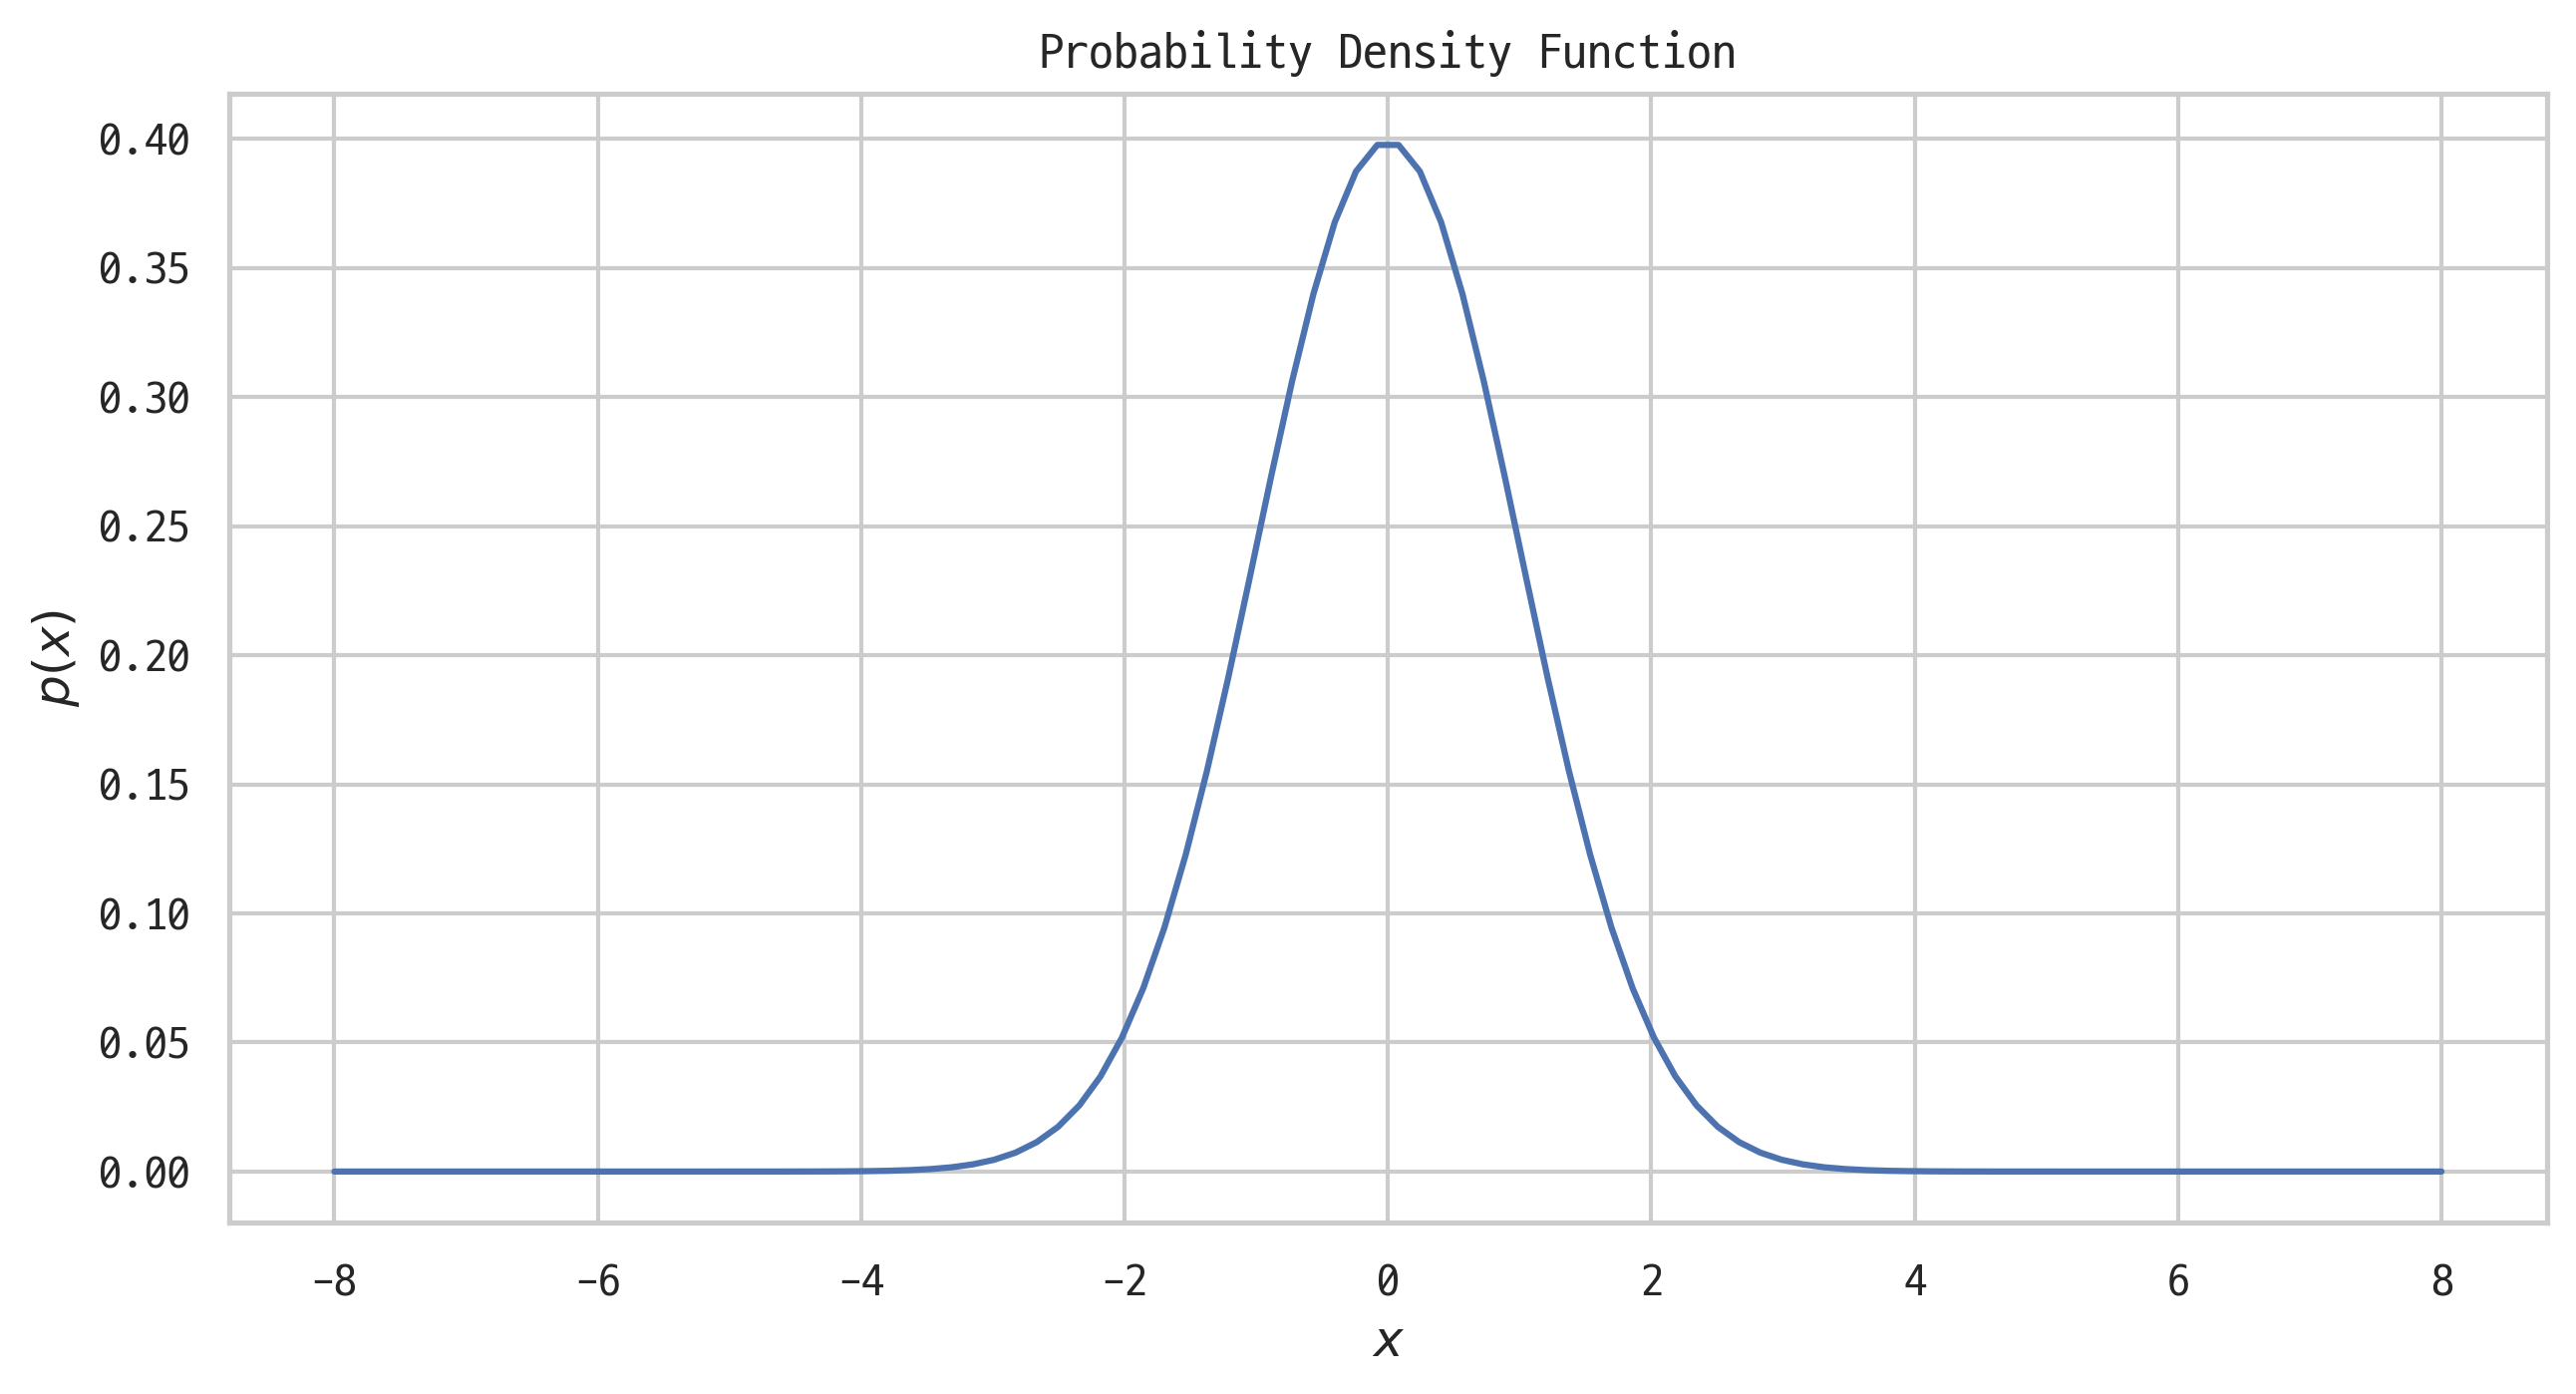

In [15]:
xx = np.linspace(-8, 8, 100)
pdf = rv.pdf(xx)

plt.figure(figsize=(10, 5)) #figsize는 plot 명령 전에 실행해야 먹힌다.
plt.plot(xx, pdf)


plt.title('Probability Density Function')
plt.xlabel('$x$')
plt.ylabel('$p(x)$')

plt.show()

#### 연습 문제 8.1.1
(1) 기댓값이 0이고 표준 편차가 0.1인 정규분포의 객체를 만들고 확률밀도함수를 그려라.

(2) 이 확률밀도함수의 최대값은 얼마인가?

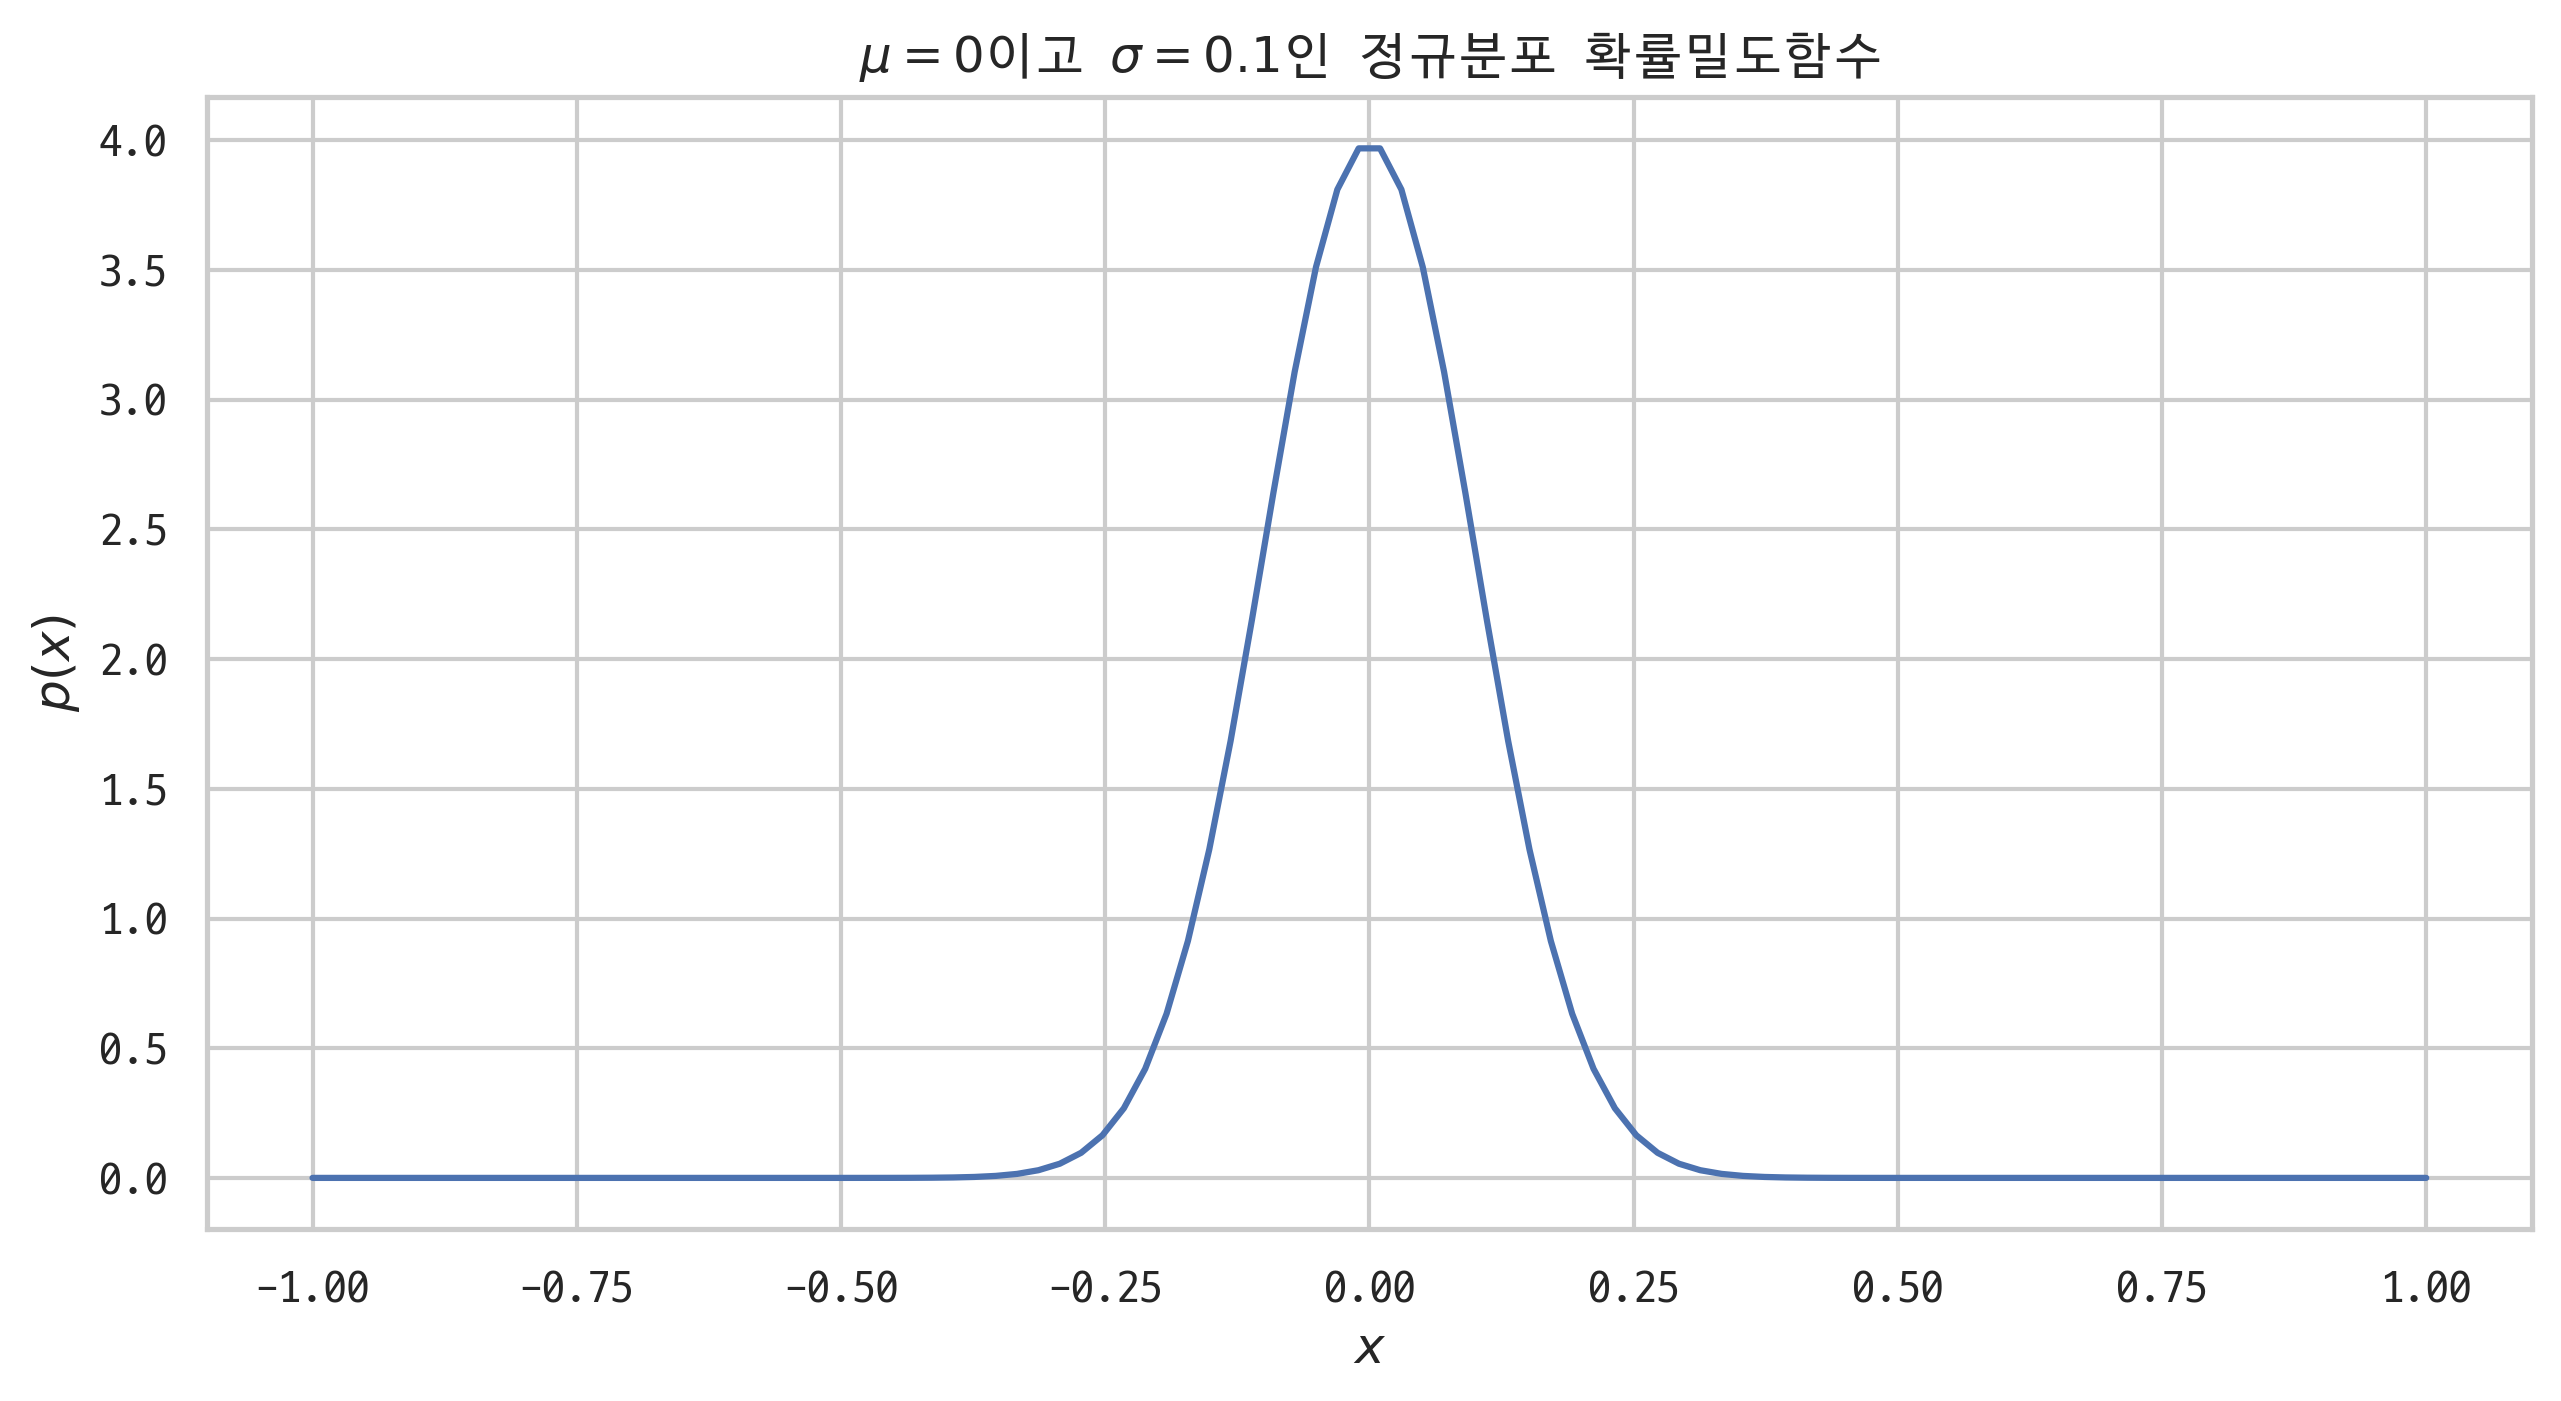

이 확률밀도의 최대값: 3.9691225079944794


In [2]:
# (1) 기댓값이 0이고 표준 편차가 0.1인 정규분포의 객체를 만들고 확률밀도함수를 그려라.
rv = sp.stats.norm(loc=0, scale=0.1)
xx = np.linspace(-1, 1, 100)
pdf = rv.pdf(xx)
plt.figure(figsize=(10, 5))
plt.plot(xx, pdf)

plt.title('$\mu=0$이고 $\sigma=0.1$인 정규분포 확률밀도함수')
plt.xlabel('$x$')
plt.ylabel('$p(x)$')
plt.show()

# (2) 이 확률밀도함수의 최대값은 얼마인가?
print('이 확률밀도의 최대값: {}'.format(pdf.max()))

### 누적분포함수

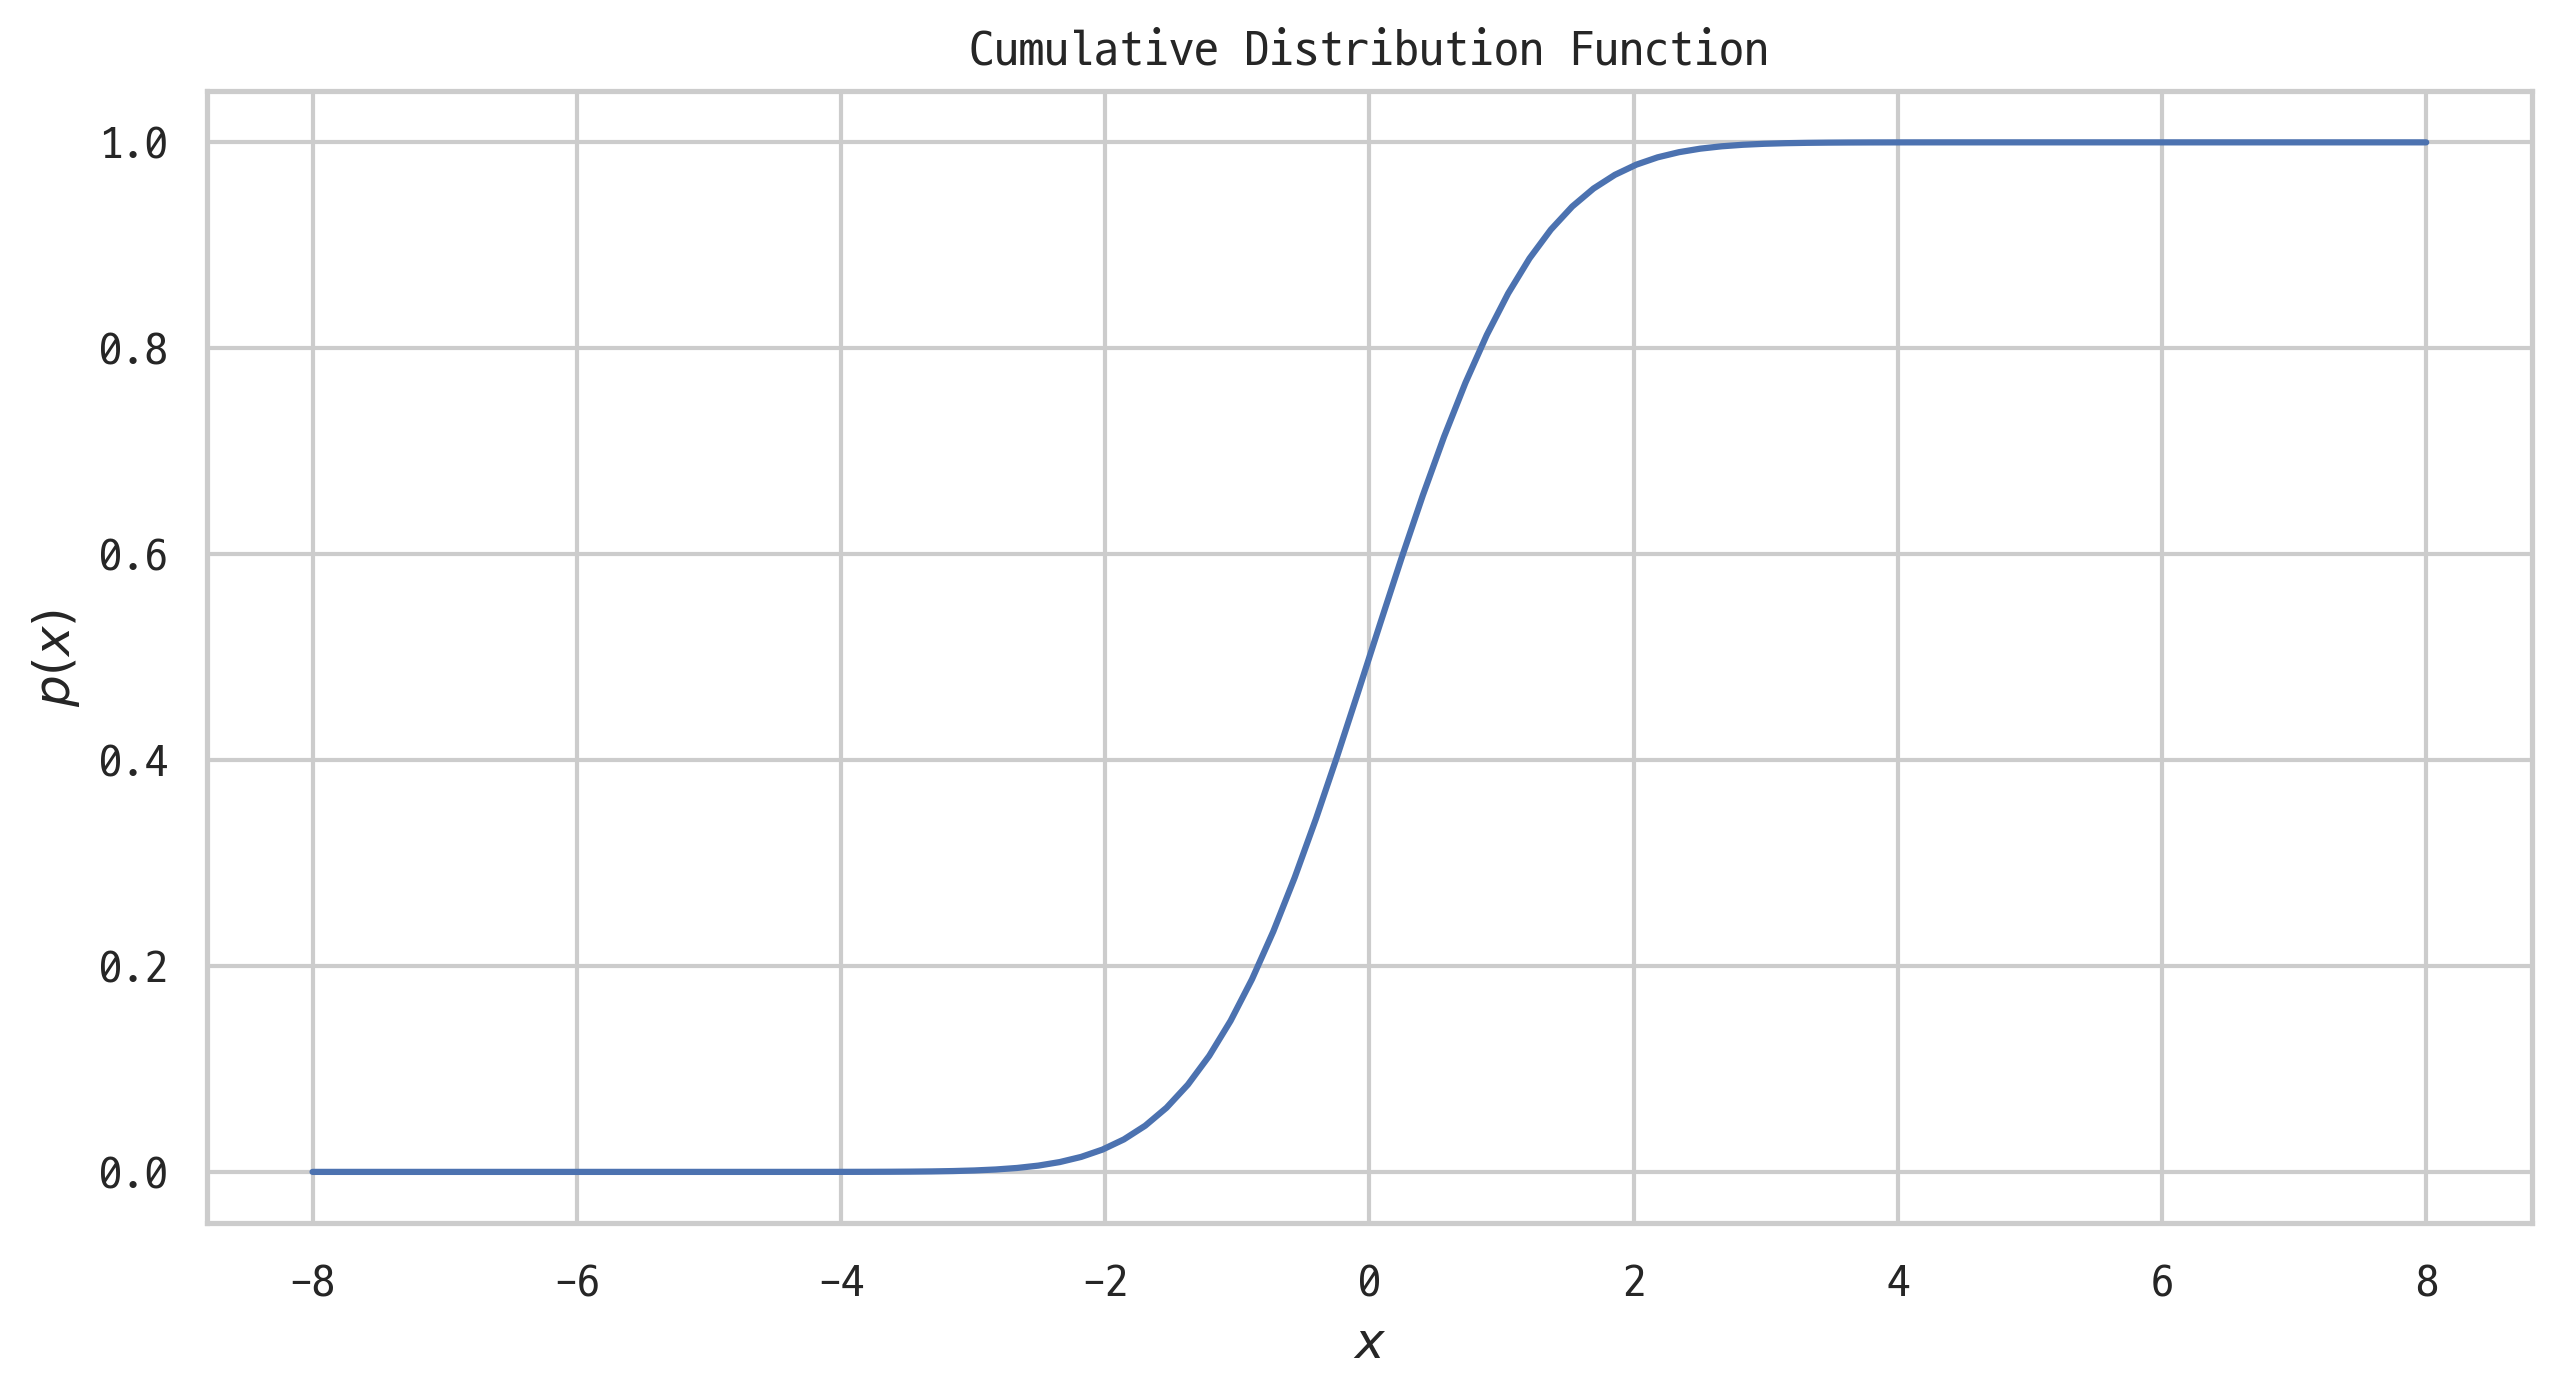

In [23]:
rv = sp.stats.norm()
cdf = rv.cdf(xx)

plt.figure(figsize=(10, 5))
plt.plot(xx, cdf)

plt.title('Cumulative Distribution Function')
plt.xlabel('$x$')
plt.ylabel('$p(x)$')
plt.show()

### 무작위 표본 생성

In [36]:
rv = sp.stats.norm(loc=1, scale=2)
rv.rvs(size=(3, 5), random_state=0)

array([[ 4.52810469,  1.80031442,  2.95747597,  5.4817864 ,  4.73511598],
       [-0.95455576,  2.90017684,  0.69728558,  0.7935623 ,  1.821197  ],
       [ 1.28808714,  3.90854701,  2.52207545,  1.24335003,  1.88772647]])

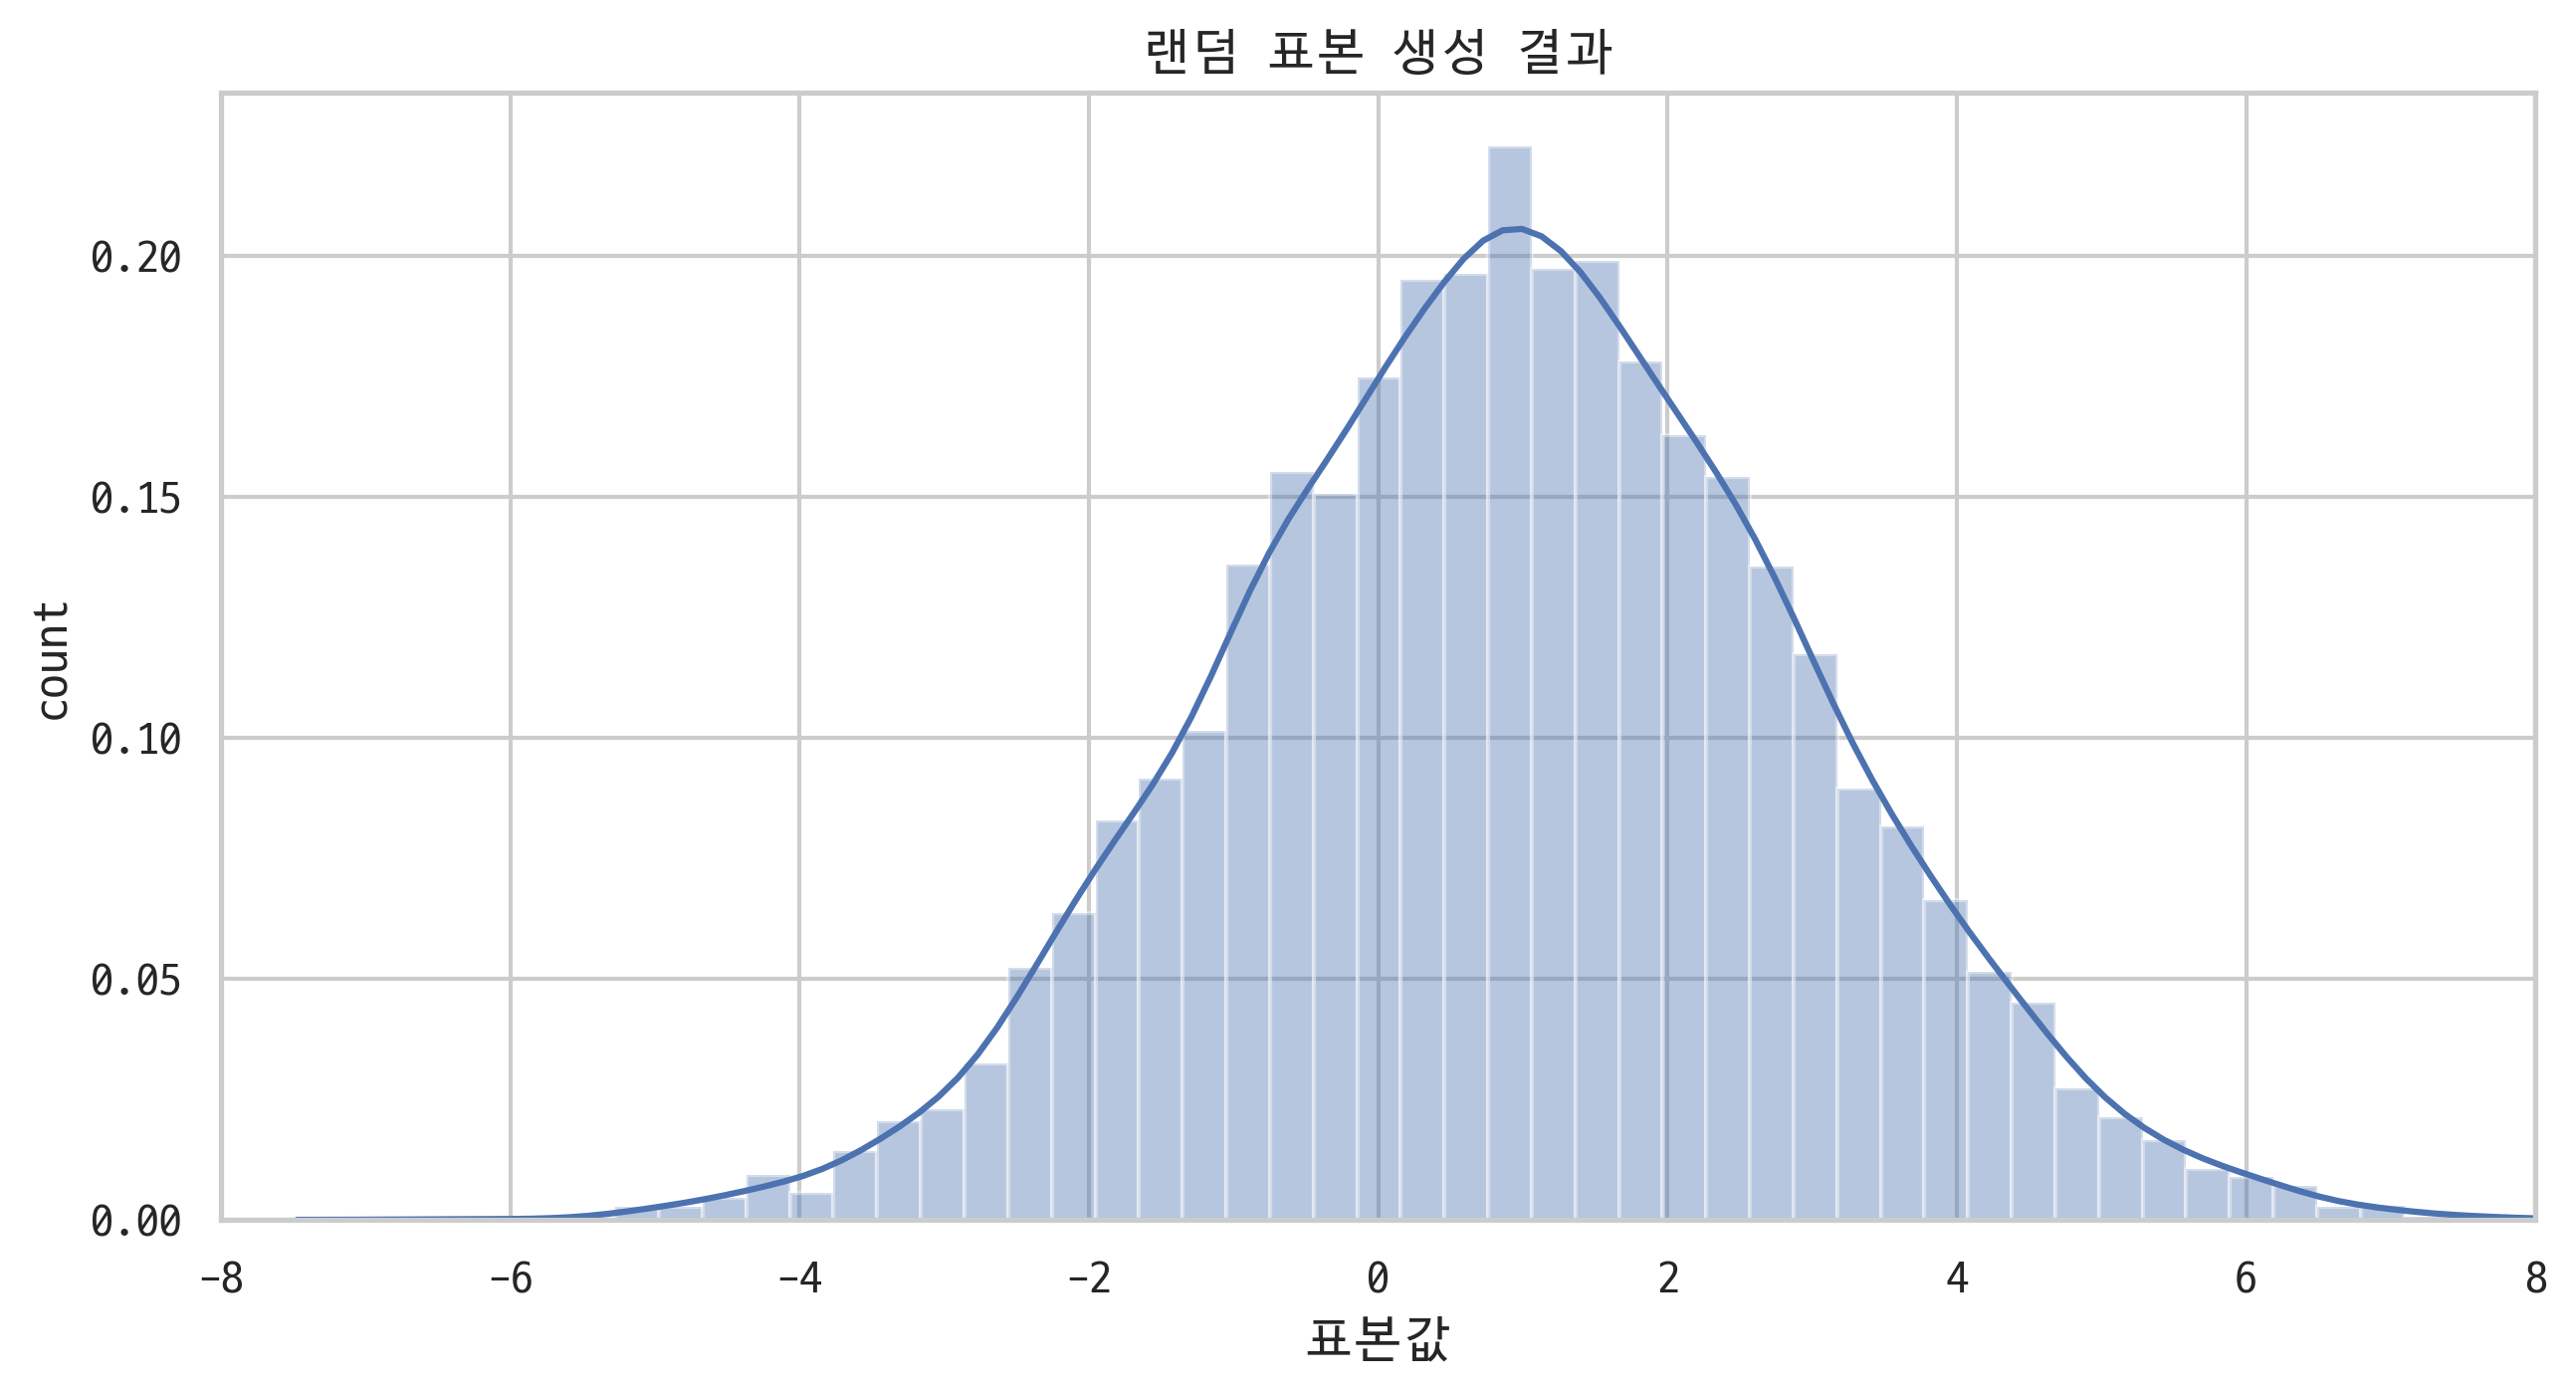

In [37]:
# rvs 사용 예시
plt.figure(figsize=(10, 5))
sns.distplot(rv.rvs(size=10000, random_state=0))
plt.title('랜덤 표본 생성 결과')
plt.xlabel('표본값')
plt.ylabel('count')
plt.xlim(-8, 8)
plt.show()

#### 연습문제 8.1.2
`rvs` 명령으로 1000개의 정규분포의 표본 데이터를 생성하고 이 표본 데이터로부터 표본평균과 비편향 표본분산을 계산하라. \
이 값이 인수로 넣은 기댓값과 분산과 비슷한지 비교하라.

In [5]:
# 기댓값이 10이고 분산이 4
rv = sp.stats.norm(loc=10, scale=2)
sample = rv.rvs(size=1000, random_state=0)
print(sample.mean(), sample.var(ddof=1))

9.909486585019609 3.9008386639125296


### 변환 확률변수의 시뮬레이션

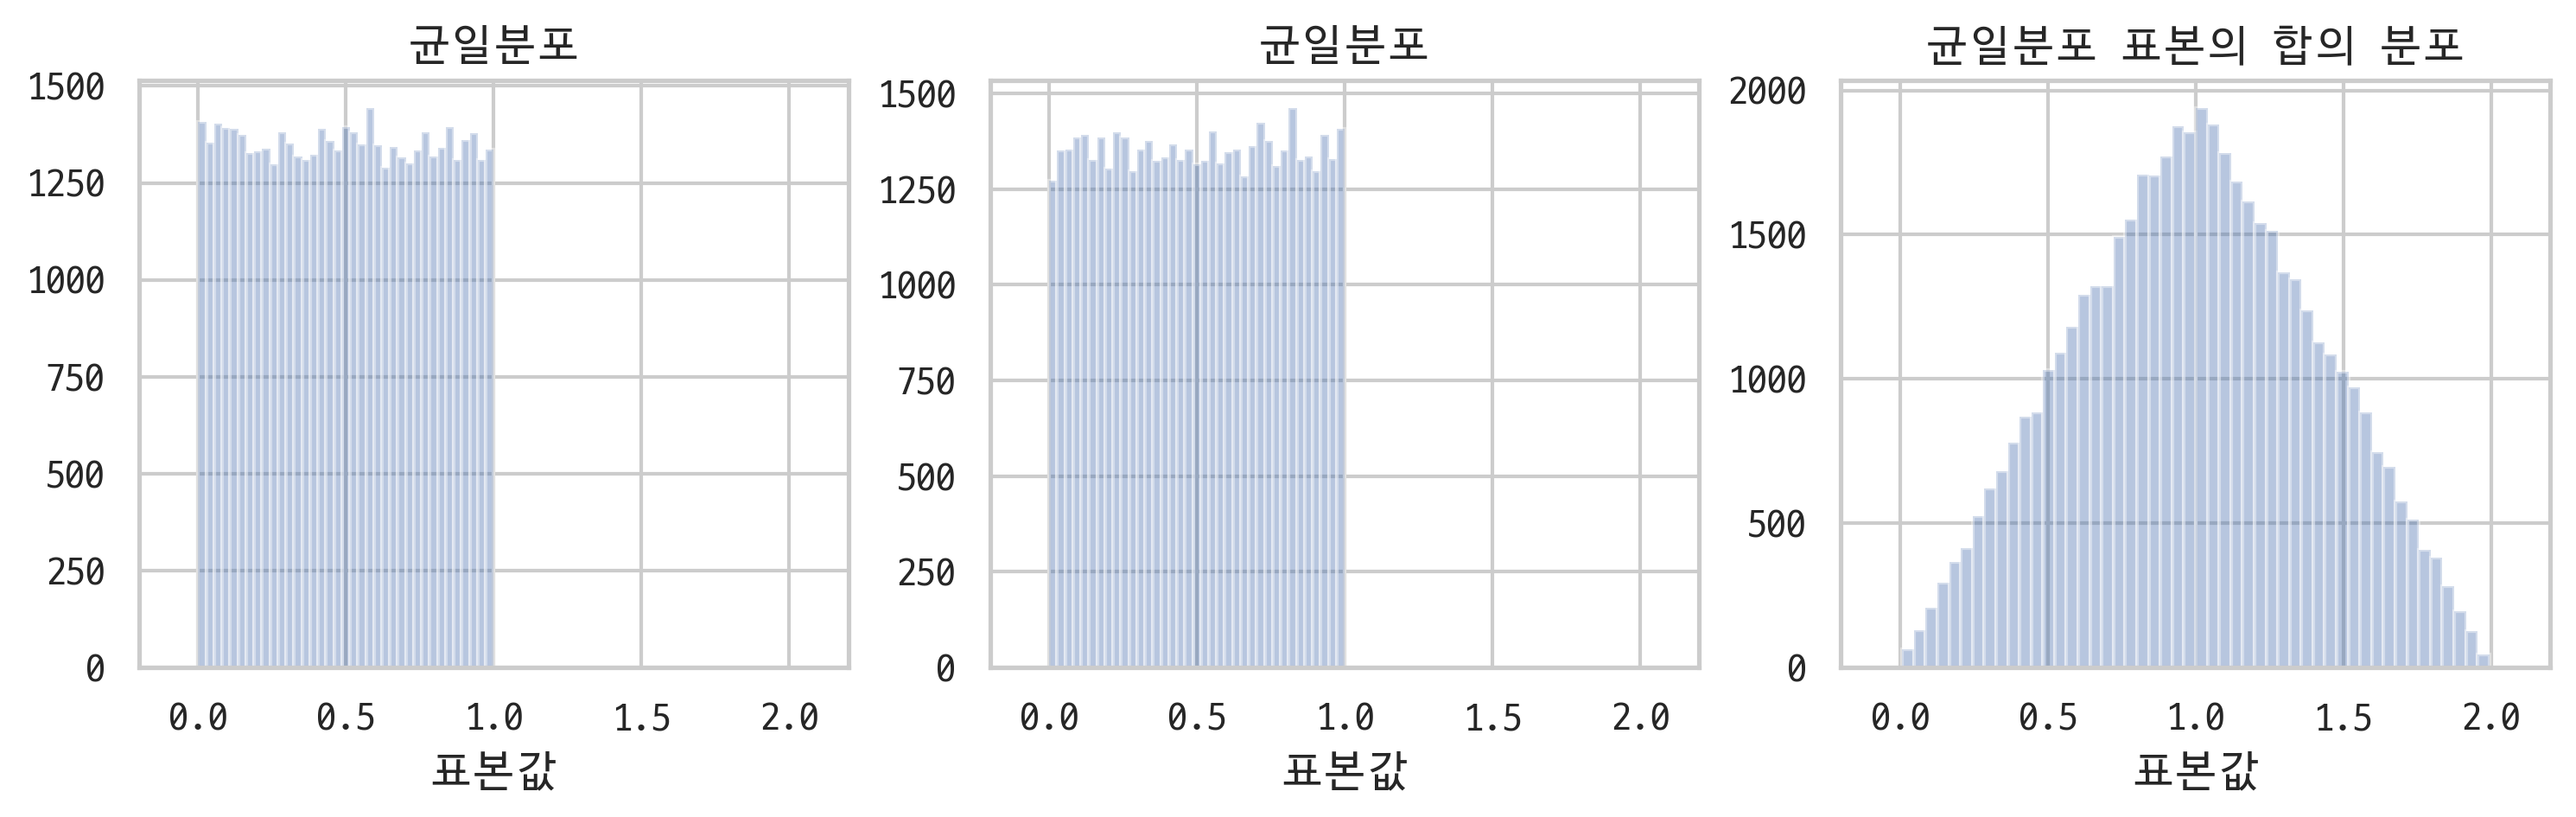

In [76]:
rv1 = sp.stats.uniform()
rv2 = sp.stats.uniform()

np.random.seed(0) #랜덤시드 존재의 이유?
N = 50000
x_1 = rv1.rvs(N)
x_2 = rv2.rvs(N)

x_3 = x_1 + x_2

plt.figure(figsize=(12, 3)) # 비율로 적용되는 듯. subplot 세 개를 합친 가로 길이 12?

plt.subplot(131)
sns.distplot(x_1, kde=False)
plt.title("균일분포")
plt.xlabel('표본값')
plt.xlim(-0.2, 2.2)

plt.subplot(132)
sns.distplot(x_2, kde=False)
plt.title('균일분포')
plt.xlabel('표본값')
plt.xlim(-0.2, 2.2)

plt.subplot(133)
sns.distplot(x_3, kde=False)
plt.title('균일분포 표본의 합의 분포')
plt.xlabel('표본값')
plt.xlim(-0.2, 2.2)

plt.show()

In [77]:
x_1.mean(), x_2.mean(), x_3.mean()

(0.49809640290460055, 0.5009036631183866, 0.9990000660229873)

In [83]:
x_1

array([0.5488135 , 0.71518937, 0.60276338, ..., 0.23367488, 0.83092388,
       0.55131786])

In [84]:
k = []
k.append(x_1)

In [85]:
sum(x_1, x_2)

array([24905.12779058, 24904.88215044, 24905.80893031, ...,
       24905.63027807, 24905.37117751, 24905.04590109])

#### 연습문제 8.1.3
균일분포 확률분포에서 두 개가 아닌 10개 표본값을 생성하여 그 값의 합을 구하면 어떤 모양의 분포를 이루는지 시뮬레이션 기능을 사용하여 구하라.\
이 때 시뮬레이션은 1000번 반복한다.

In [101]:
# 10개의 표본값 생성하여, 모두 더한 ndarray 만들기
ls = []

for i in range(0, 10):
    #np.random.seed(0) 여기서는 왜 랜덤시드를 주면 답이 다르게 나오나?
    sample = sp.stats.uniform().rvs(10000) #문제는 1000번, 답지는 10000번
    ls.append(sample)

x_sum = np.sum(np.vstack(ls), axis = 0)

# 위 코드는 더 간단하게 다음과 같이 표현
# sample = sp.stats.uniform().rvs((10, 10000))
# x_sum = sample.sum(axis = 0)

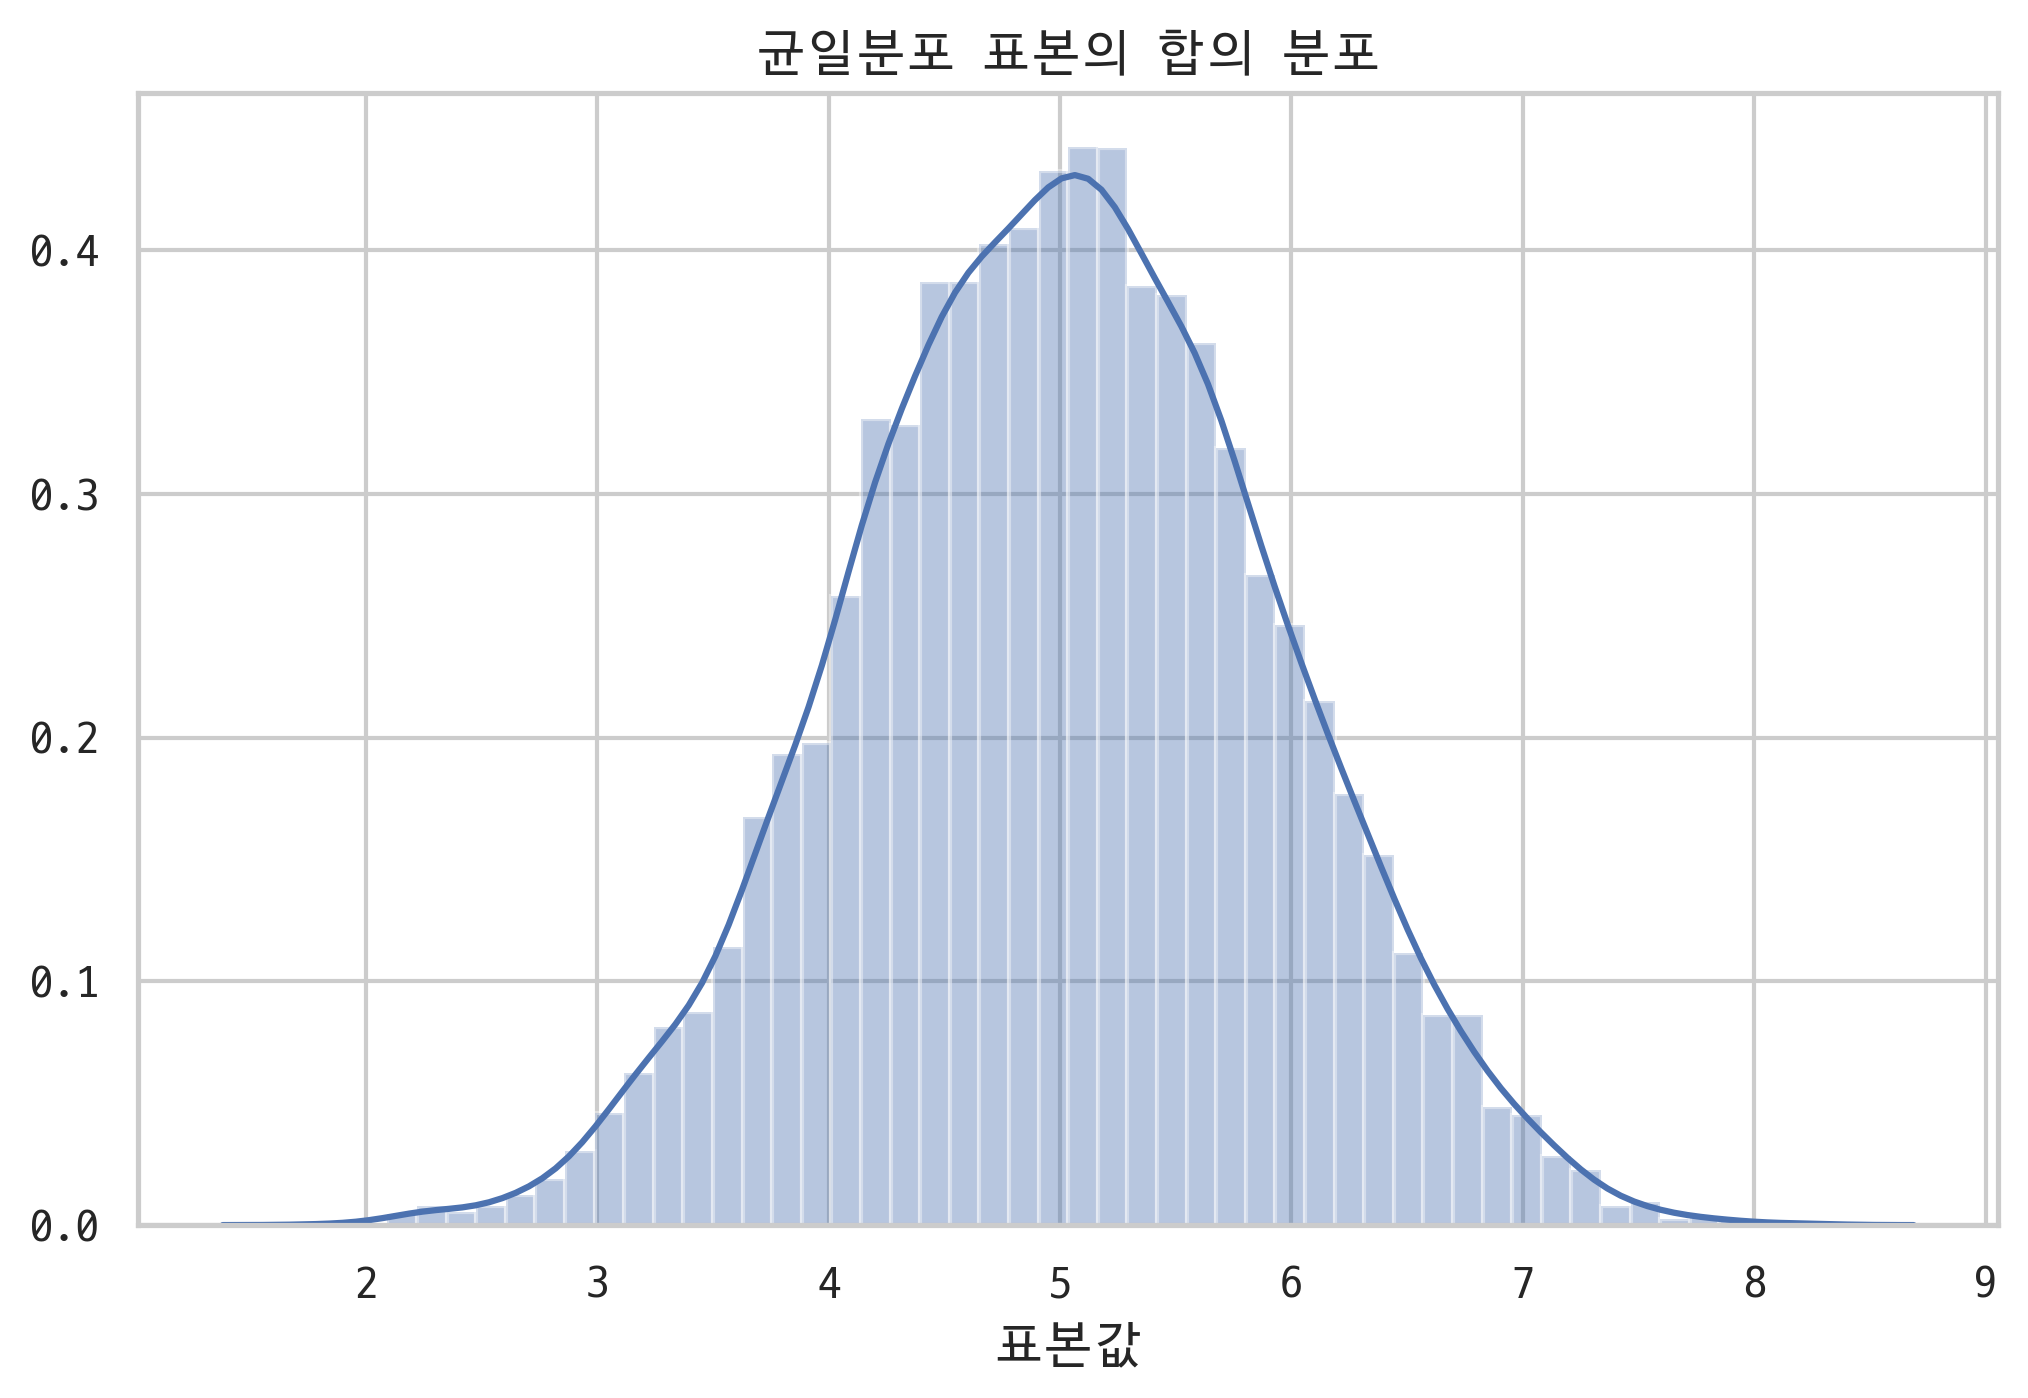

In [102]:
# 그래프로 표현하기
sns.distplot(x_sum, kde=True)
plt.title('균일분포 표본의 합의 분포')
plt.xlabel('표본값')

plt.show()

# 2. 베르누이분포와 이항분포

### Scipy를 사용한 베르누이 확률변수의 시뮬레이션

In [111]:
# 베르누이 확률분포 객체 생성
mu = 0.6
rv = sp.stats.bernoulli(mu)
type(rv)

scipy.stats._distn_infrastructure.rv_frozen

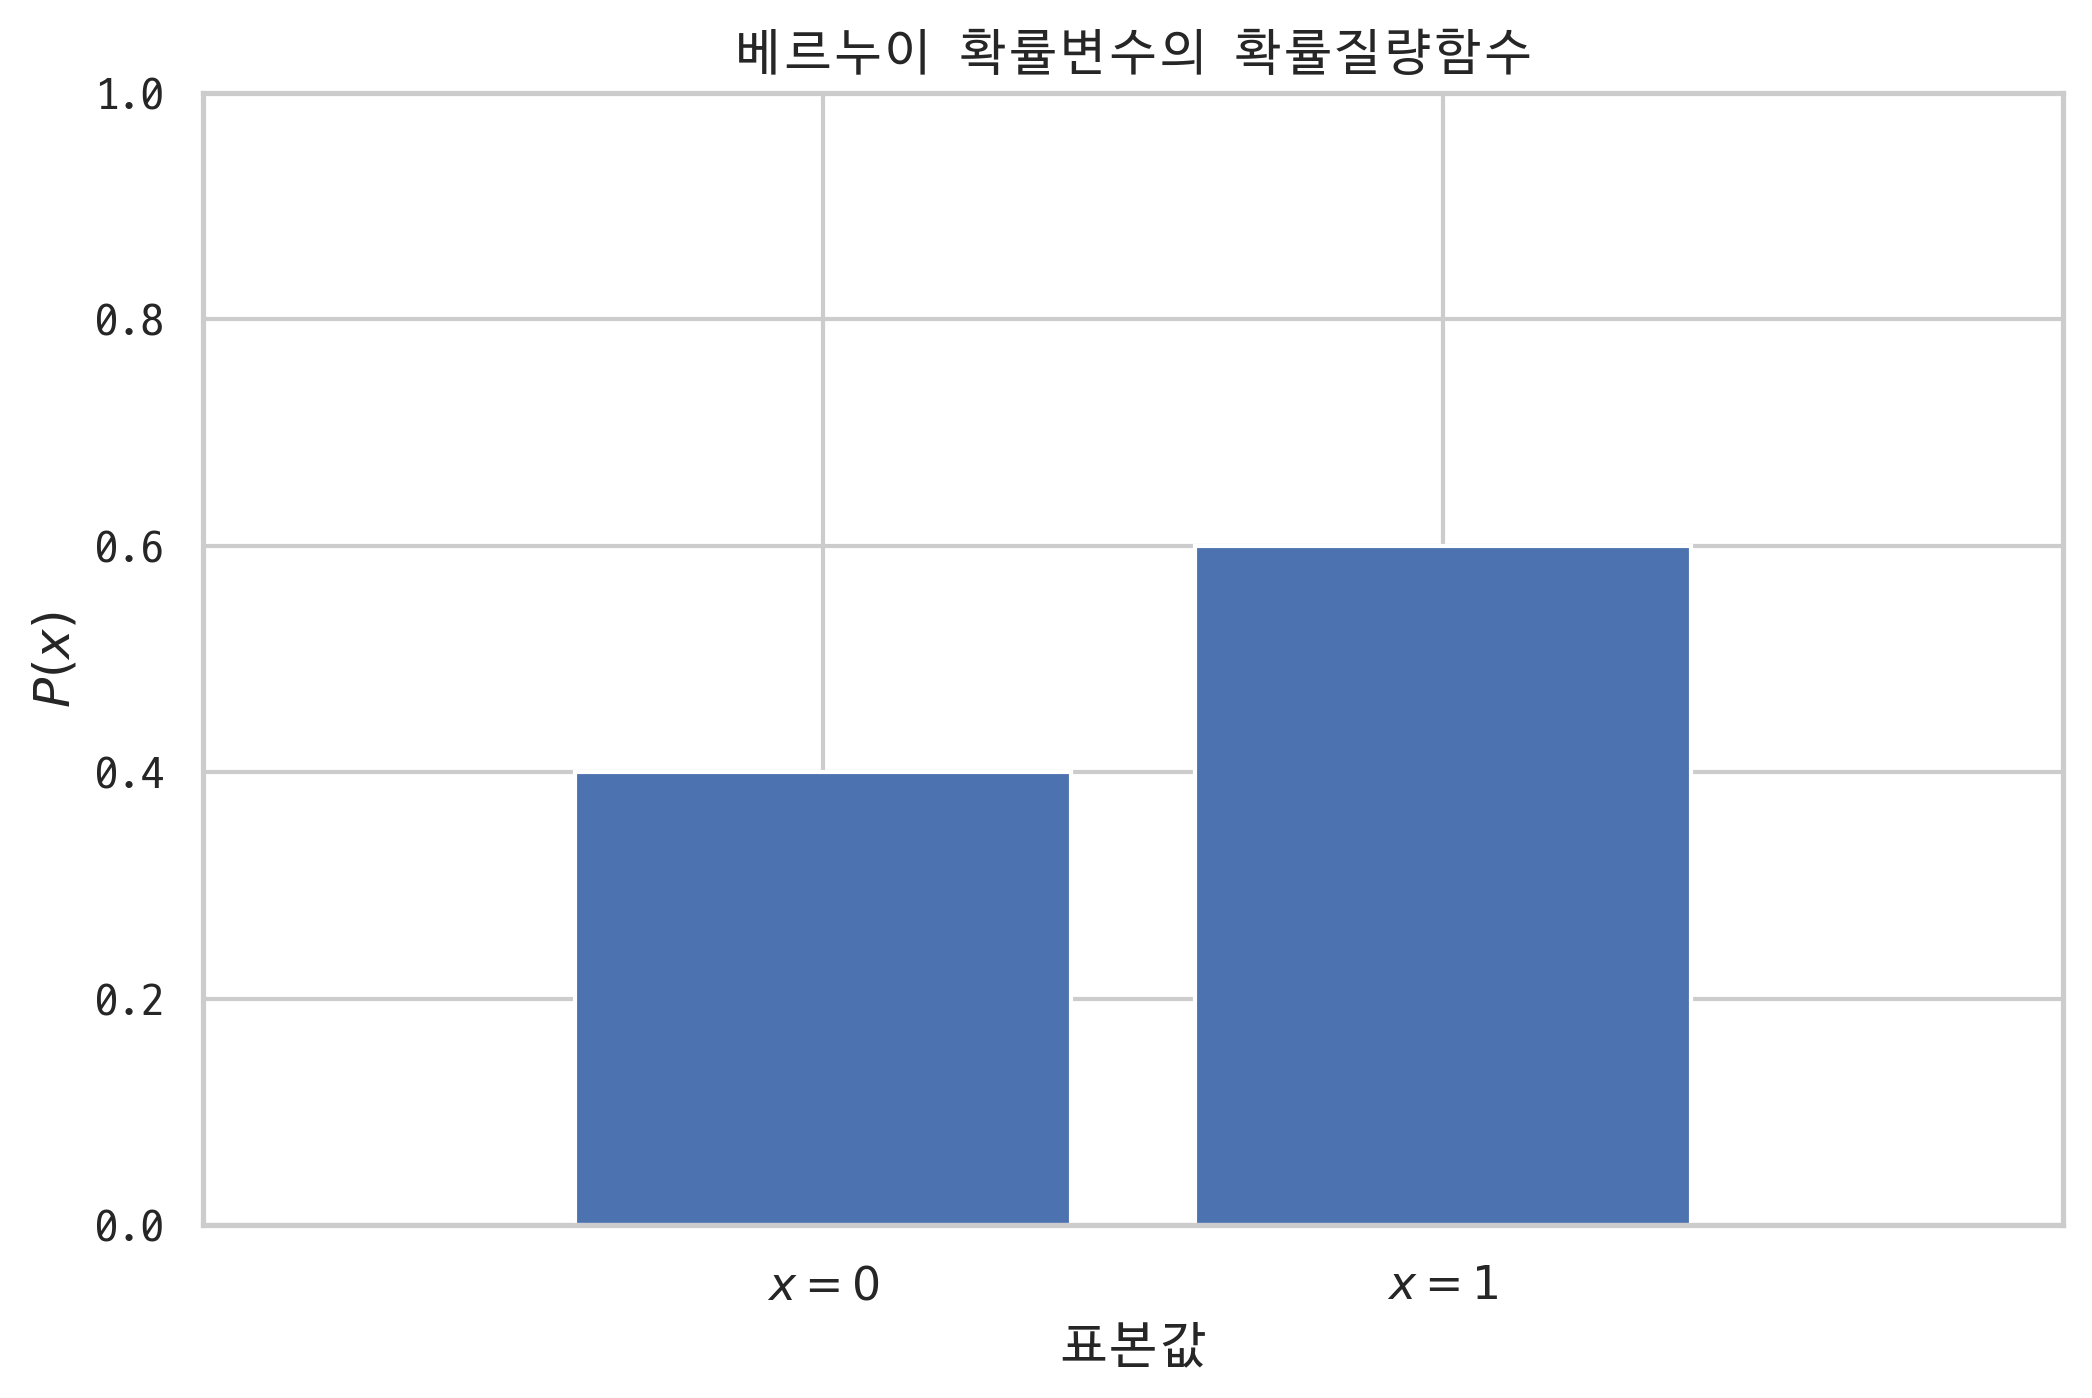

In [112]:
# 베르누이 확률질량함수 생성 - 이산확률변수이므로
xx = [0, 1]

plt.bar(xx, rv.pmf(xx))
plt.xlim(-1, 2)
plt.ylim(0, 1)
plt.xticks([0, 1], ['$x=0$', '$x=1$'])
plt.xlabel('표본값')
plt.ylabel('$P(x)$')
plt.title('베르누이 확률변수의 확률질량함수')
plt.show()

In [121]:
# 시뮬레이션
x = rv.rvs(size=100, random_state=1)
x

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0])

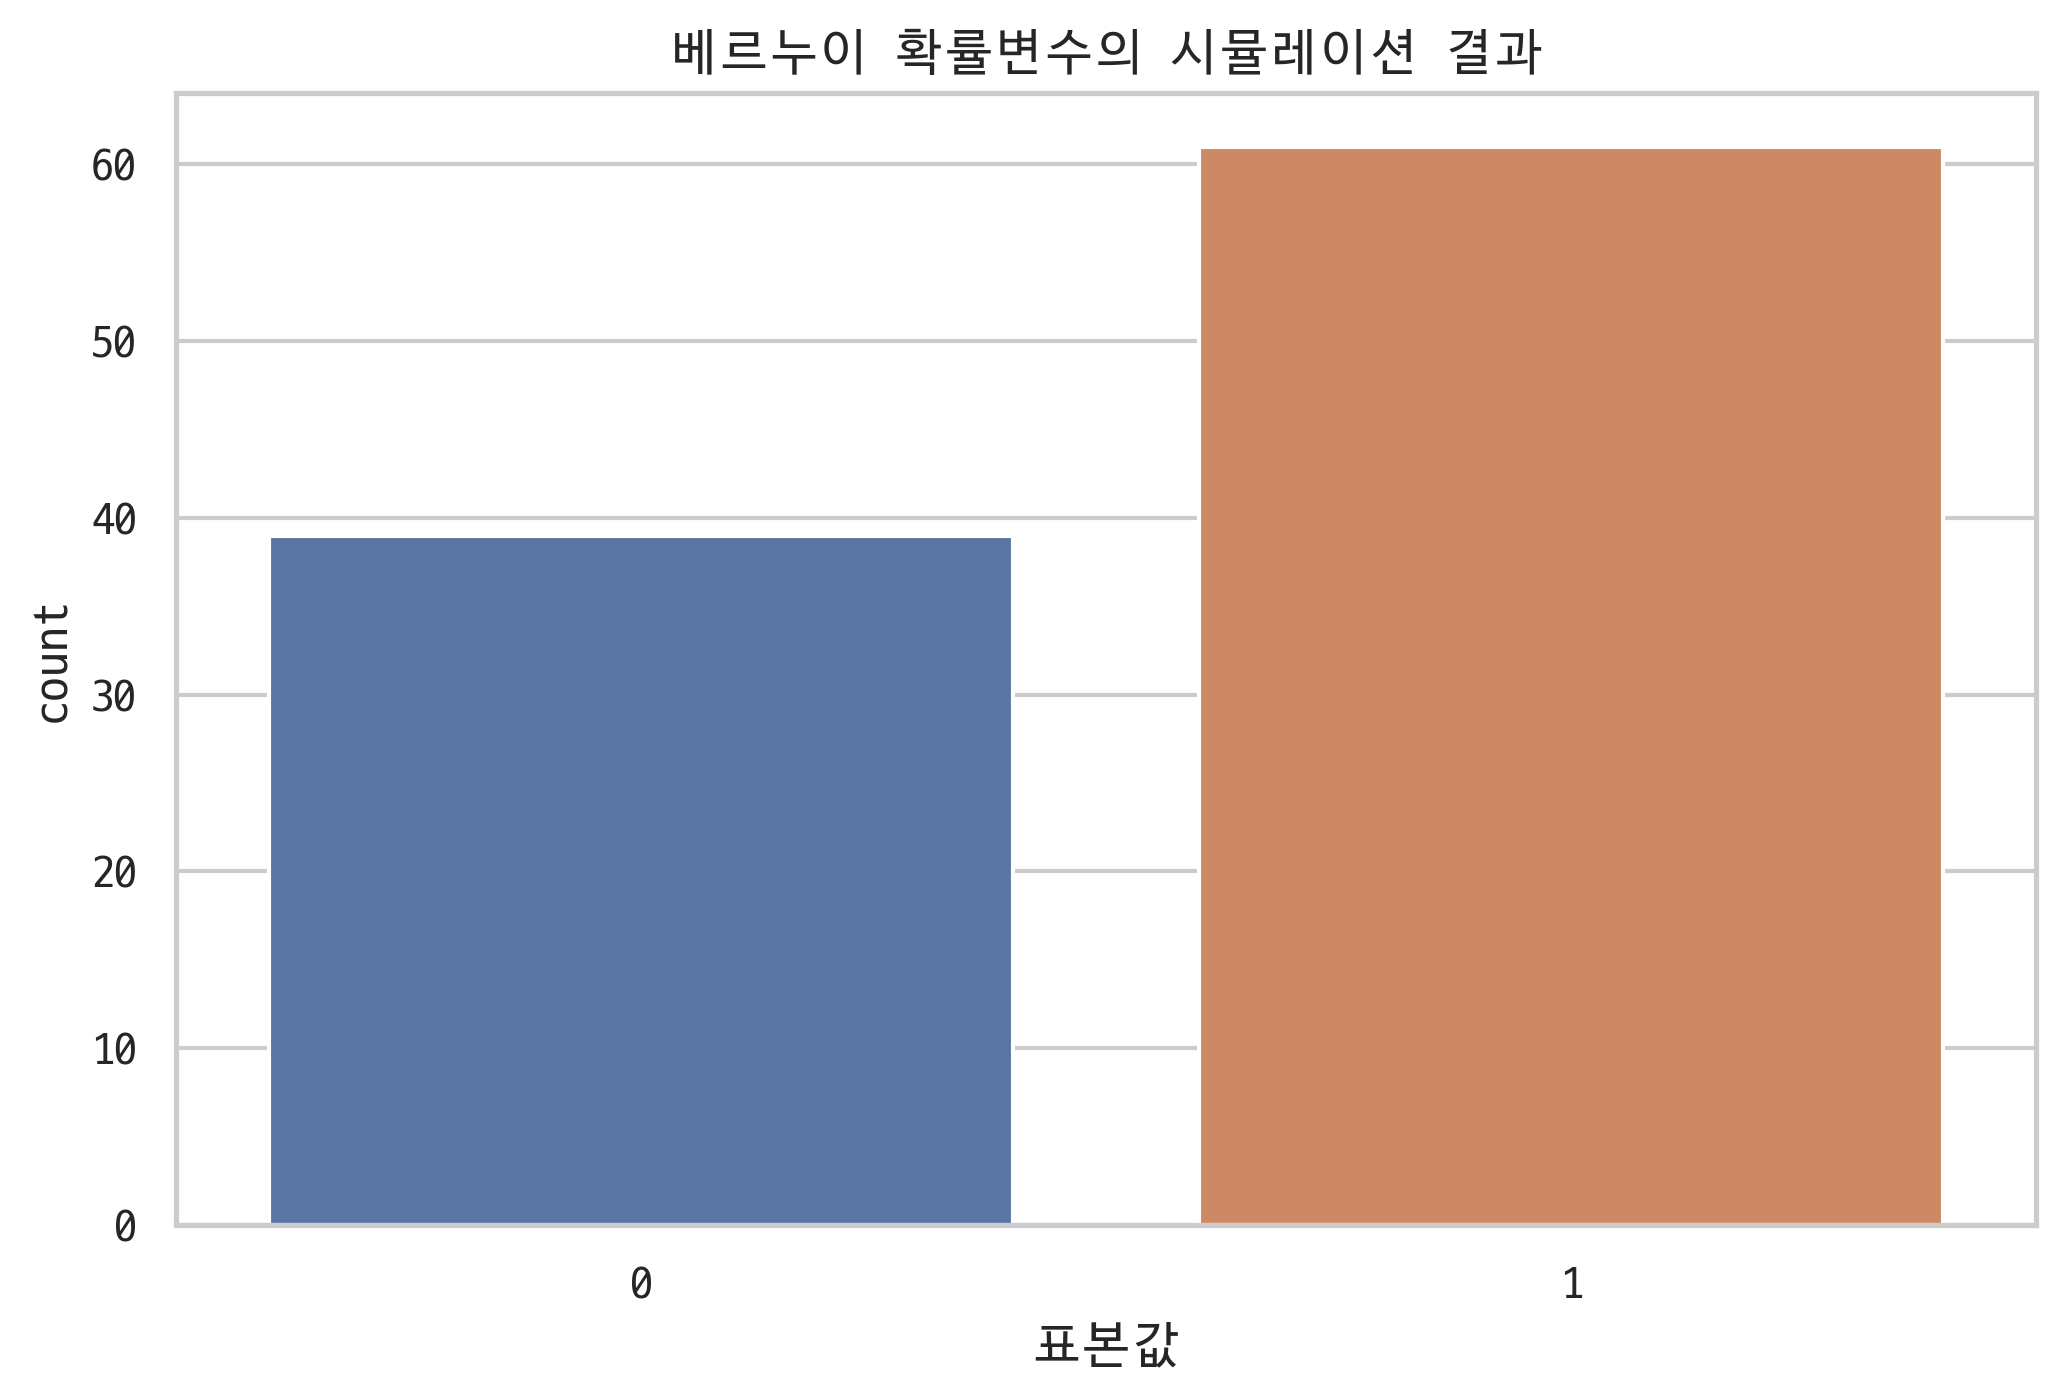

In [122]:
# 생성 결과를 시각화
sns.countplot(x)
plt.title('베르누이 확률변수의 시뮬레이션 결과')
plt.xlabel('표본값')
plt.show()

In [134]:
#이론적인 확률분포와 표본의 확률분포를 동시에 보이려면
y = np.bincount(x, minlength=2) / float(len(x))
print(np.bincount(x, minlength=2), float(len(x)), y)

[39 61] 100.0 [0.39 0.61]


In [126]:
df = pd.DataFrame({'이론': rv.pmf(xx), '시뮬레이션': y}, index=[0, 1])
df

,이론,시뮬레이션
0,0.4,0.39
1,0.6,0.61


In [129]:
# 위의 df를 시각화
df2 = df.stack().reset_index() #stack 메서드는 컬럼명을 행의 형태로 재배치
df2.columns = ['표본값', '유형', '비율'] #컬럼 이름 지정하기
df2

,표본값,유형,비율
0,0,이론,0.40
1,0,시뮬레이션,0.39
2,1,이론,0.60
3,1,시뮬레이션,0.61


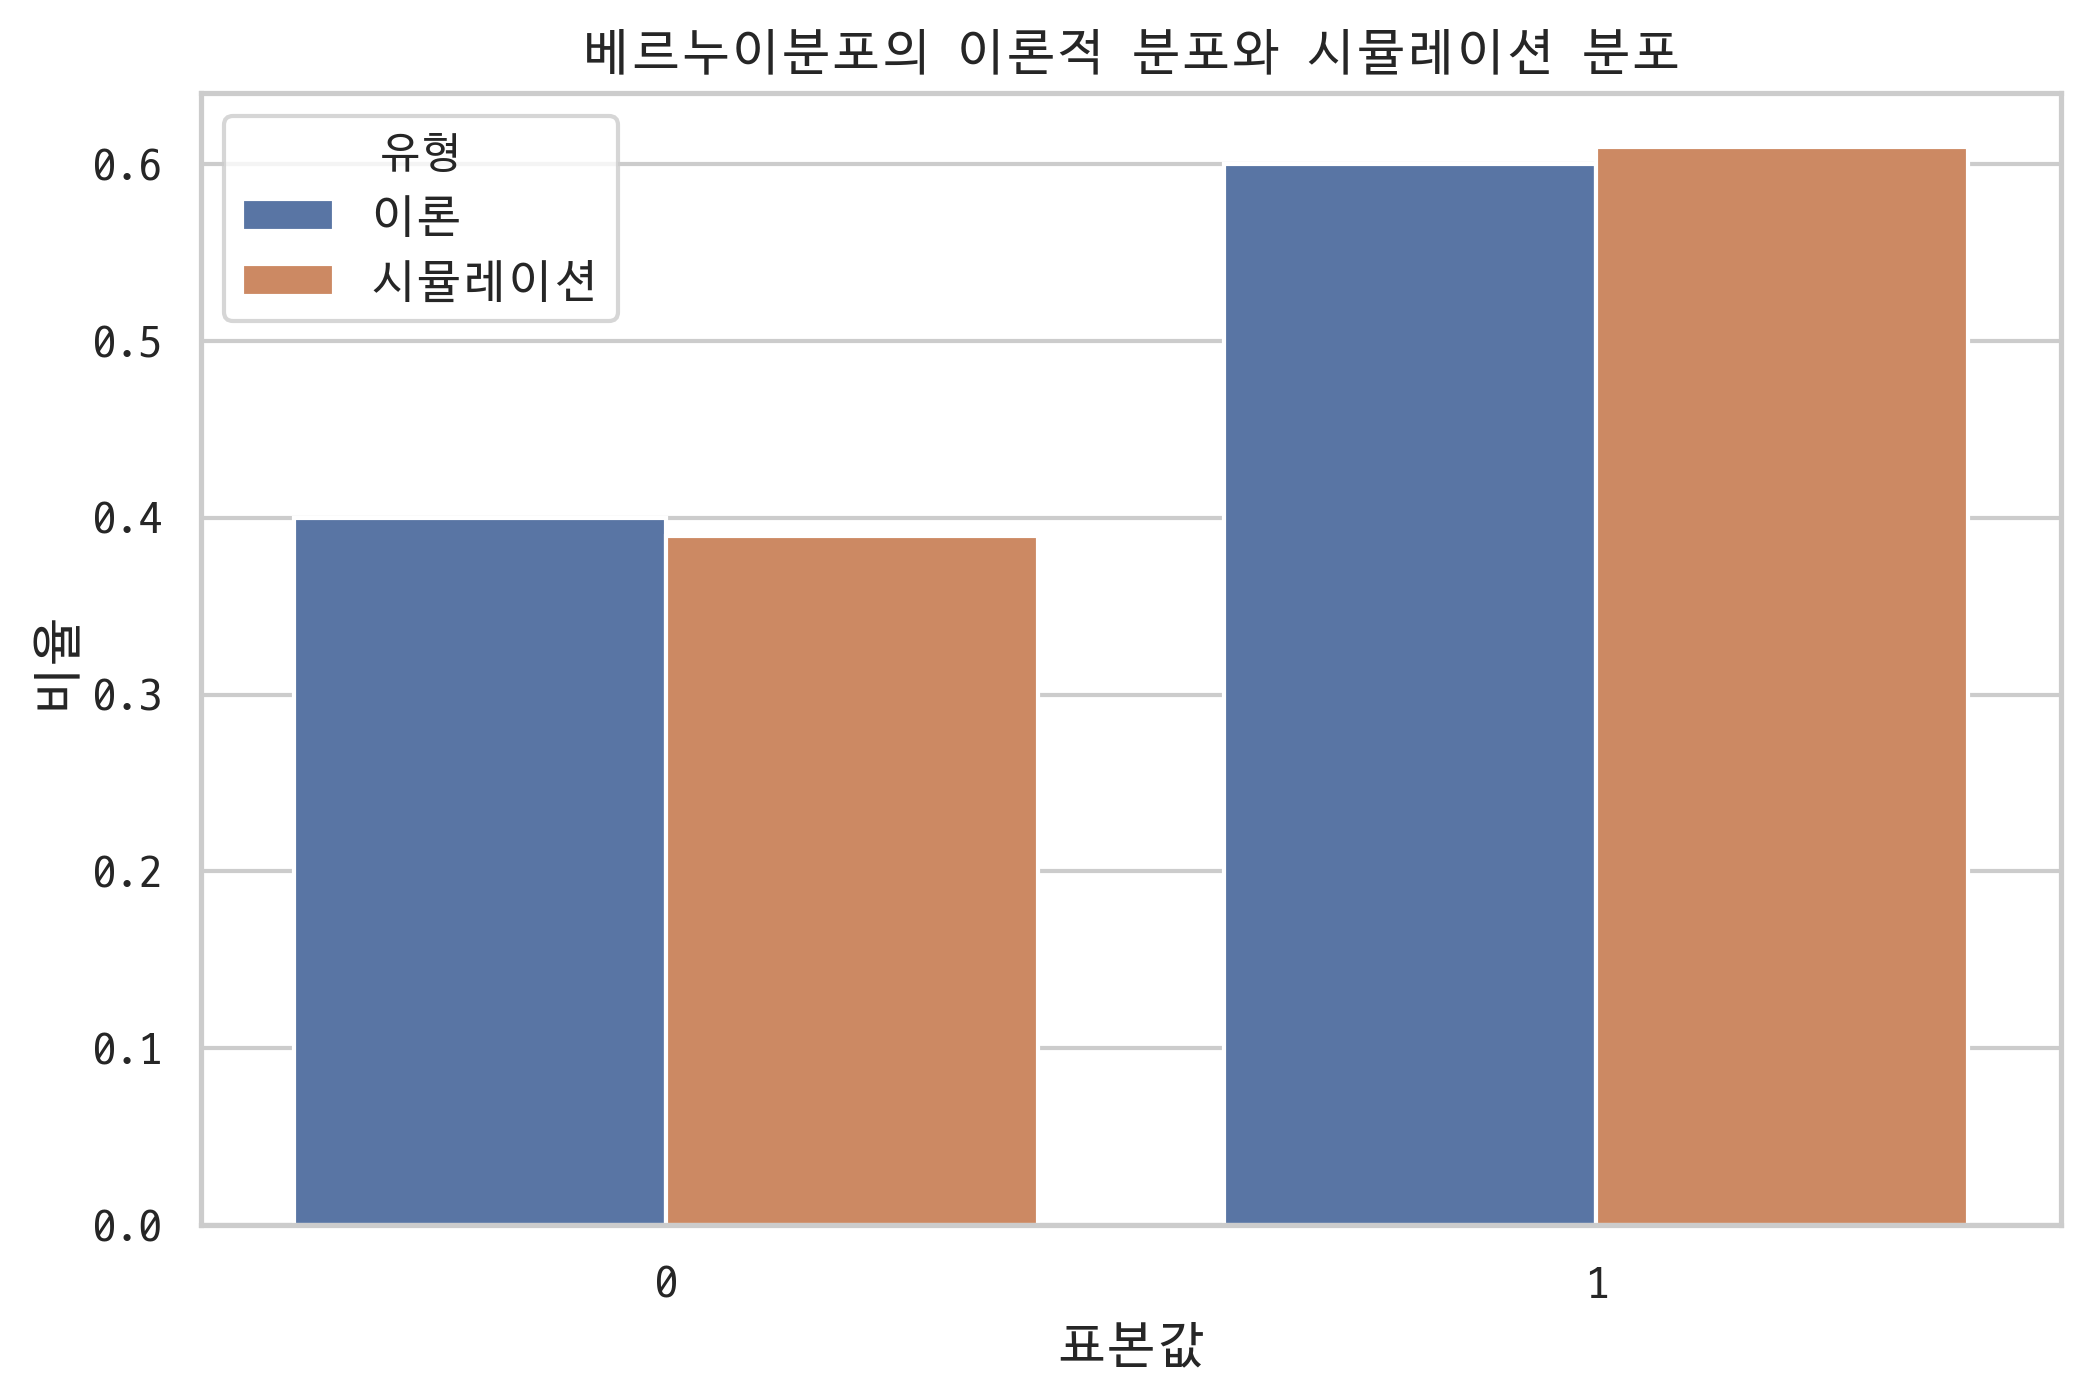

In [130]:
sns.barplot(x='표본값', y='비율', hue='유형', data=df2)
plt.title('베르누이분포의 이론적 분포와 시뮬레이션 분포')
plt.show()

#### 연습 문제 8.2.2
베르누이 확률분포의 모수가 다음과 같을 경우에 각각 표본을 생성한 후 기댓값과 분산을 구하고 앞의 예제와 같이 확률 밀도 함수와 비교한 바 플롯을 그린다.  
표본 개수가 10개인 경우와 1000개인 경우에 대해 각각 위의 계산을 한다.

(1)  𝜇=0.5  
(2)  𝜇=0.9

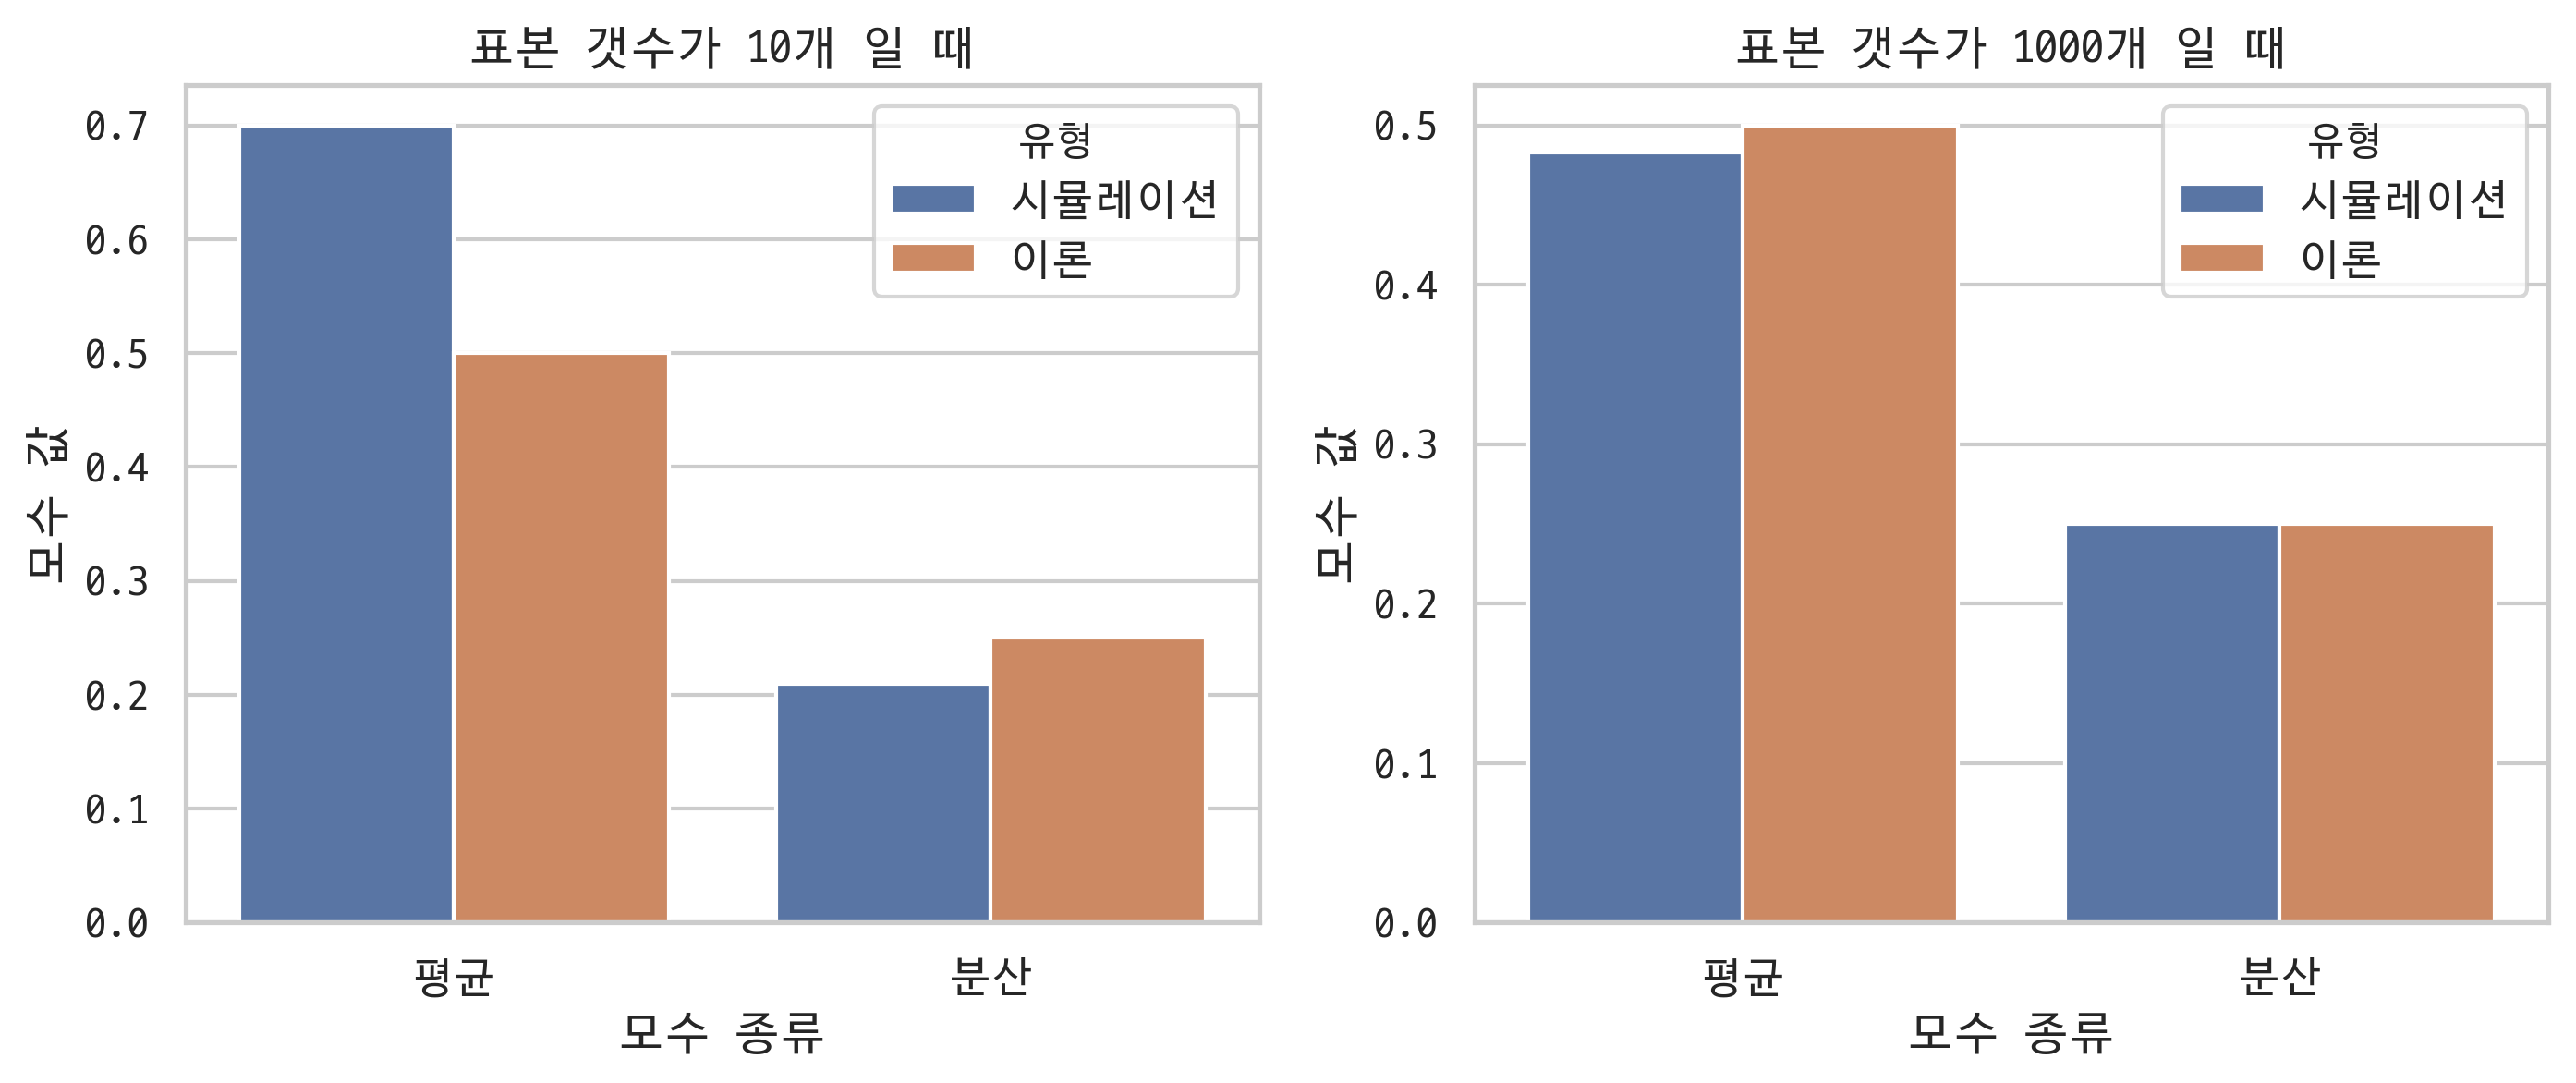

In [249]:
# (1) 모수가 0.5 일 때
# 1) 표본 개수가 10개 일 때

mu = 0.5
rv = sp.stats.bernoulli(mu)

x1 = rv.rvs(10, random_state=0) #표본값 생성

#표본평균, 표본분산: [x1.mean(), x1.var()]
#베르누이분포 기댓값, 분산: [mu, mu * (1 - mu)]

df1_1 = pd.DataFrame({'시뮬레이션': [x1.mean(), x1.var()], '이론':[mu, mu*(1-mu)]})
df1_1.index = ['평균', '분산']
df1_1 = df1_1.stack().reset_index()
df1_1.columns = ['모수 종류', '유형', '모수 값']

# 2) 표본 개수가 1000개 일 때
x2 = rv.rvs(1000, random_state=0) #표본값 생성

#표본평균, 표본분산: [x2.mean(), x2.var()]
#베르누이분포 기댓값, 분산: [mu, mu * (1 - mu)]

df1_2 = pd.DataFrame({'시뮬레이션': [x2.mean(), x2.var()], '이론':[mu, mu*(1-mu)]})
df1_2.index = ['평균', '분산']
df1_2 = df1_2.stack().reset_index()
df1_2.columns = ['모수 종류', '유형', '모수 값']

#그림그리기 - 10개 일 때와 1000개 일 때, 비교 plot
plt.figure(figsize=(11,4))

plt.subplot(121)
sns.barplot(x='모수 종류', y='모수 값', hue='유형', data=df1_1)
plt.title('표본 갯수가 10개 일 때')

plt.subplot(122)
sns.barplot(x='모수 종류', y='모수 값', hue='유형', data=df1_2)
plt.title('표본 갯수가 1000개 일 때')

plt.show()


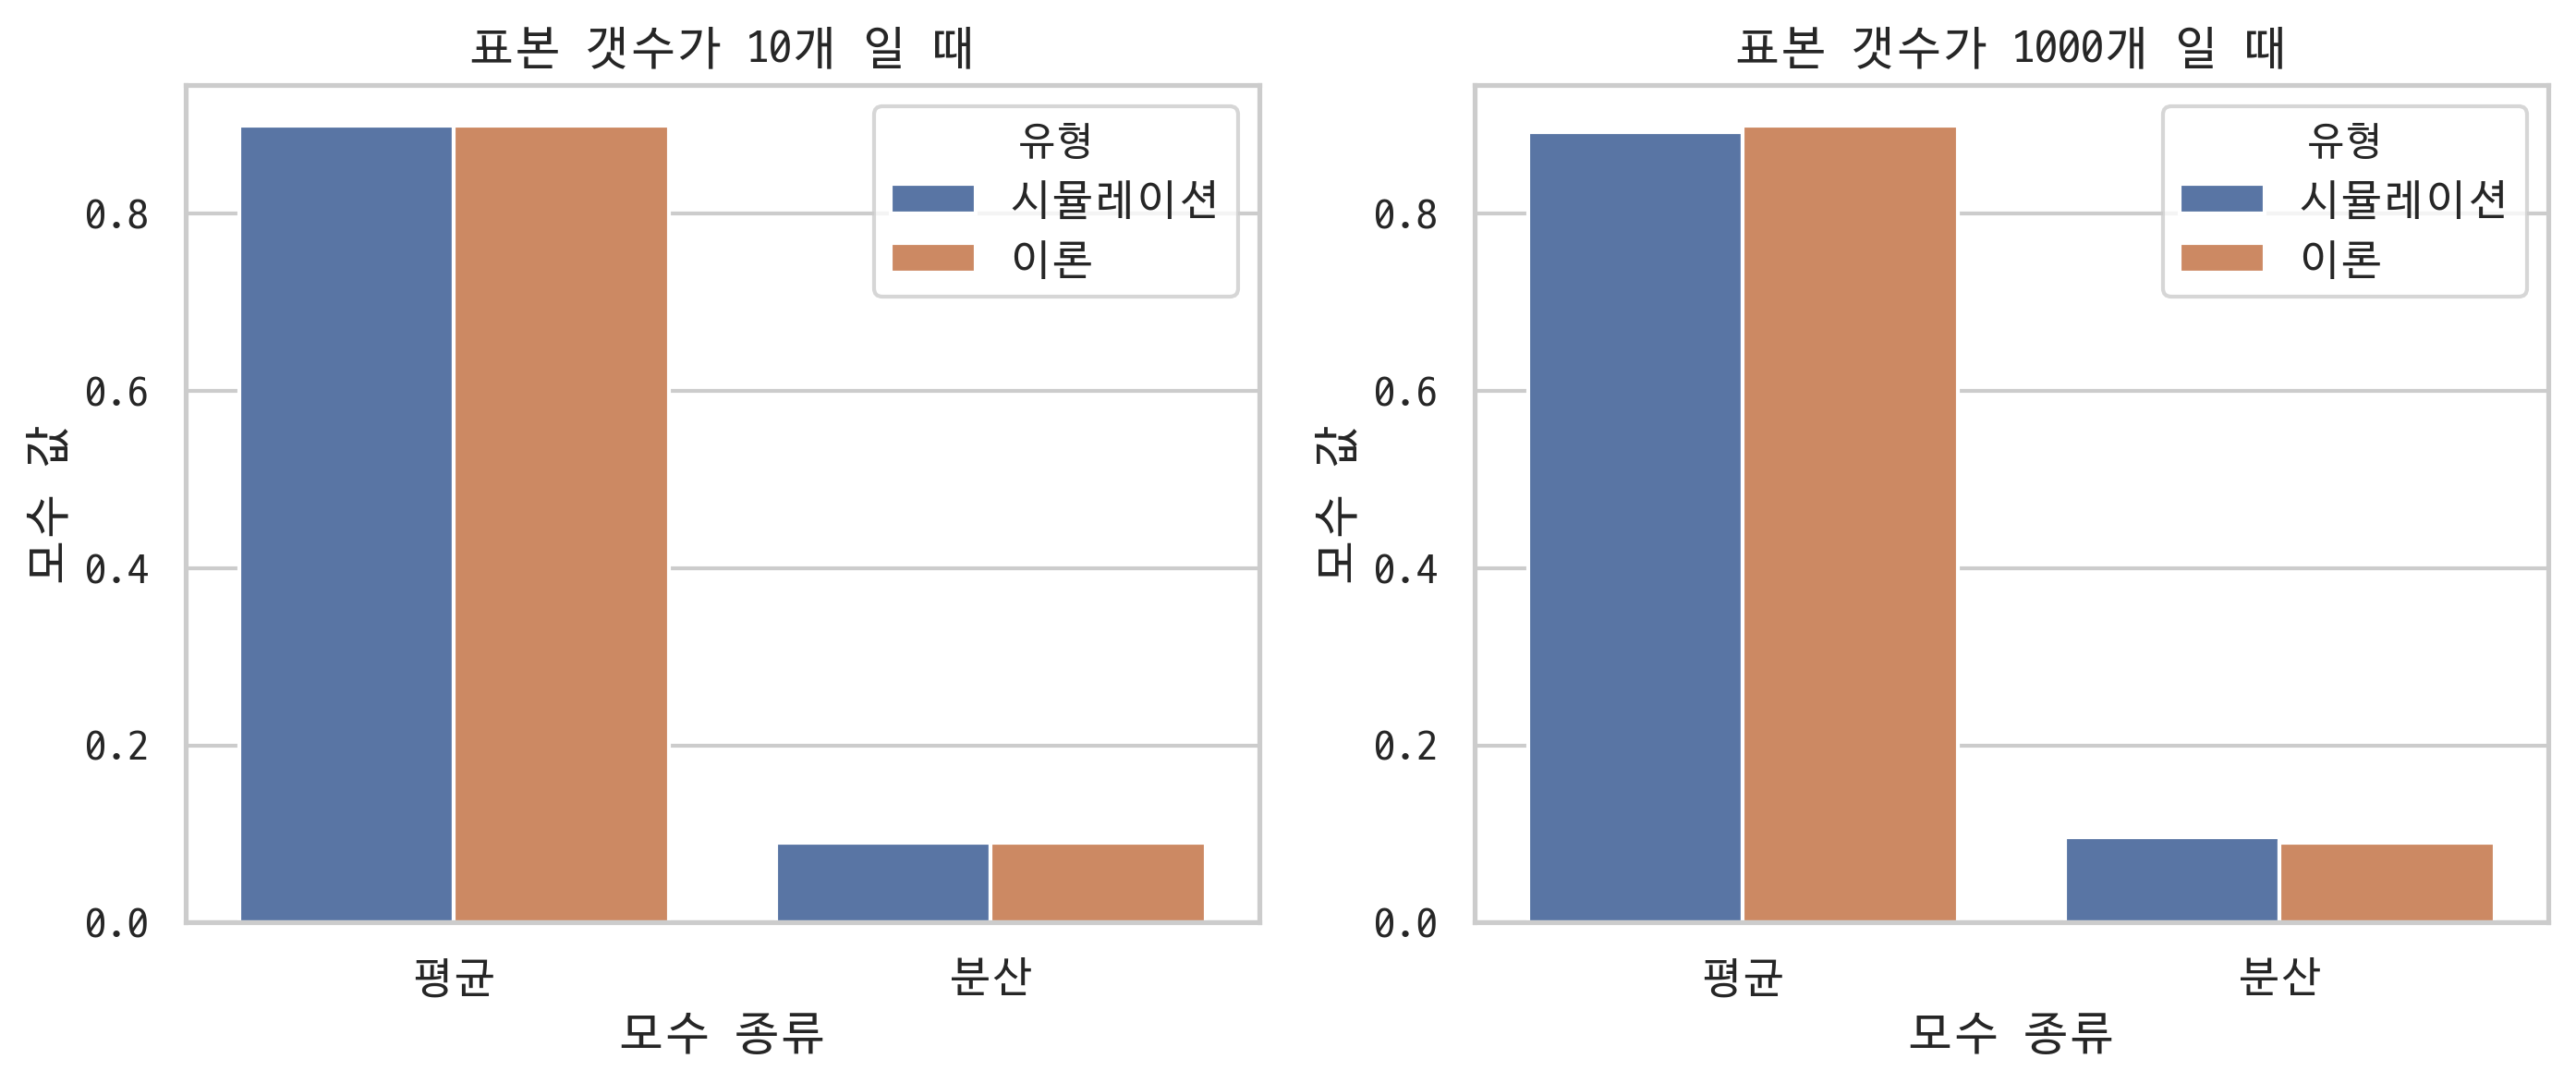

In [248]:
# (1) 모수가 0.9 일 때
# 1) 표본 개수가 10개 일 때

mu = 0.9
rv = sp.stats.bernoulli(mu)

x1 = rv.rvs(10, random_state=0) #표본값 생성

#표본평균, 표본분산: [x1.mean(), x1.var()]
#베르누이분포 기댓값, 분산: [mu, mu * (1 - mu)]

df1_1 = pd.DataFrame({'시뮬레이션': [x1.mean(), x1.var()], '이론':[mu, mu*(1-mu)]})
df1_1.index = ['평균', '분산']
df1_1 = df1_1.stack().reset_index()
df1_1.columns = ['모수 종류', '유형', '모수 값']

# 2) 표본 개수가 1000개 일 때
x2 = rv.rvs(1000, random_state=0) #표본값 생성

#표본평균, 표본분산: [x2.mean(), x2.var()]
#베르누이분포 기댓값, 분산: [mu, mu * (1 - mu)]

df1_2 = pd.DataFrame({'시뮬레이션': [x2.mean(), x2.var()], '이론':[mu, mu*(1-mu)]})
df1_2.index = ['평균', '분산']
df1_2 = df1_2.stack().reset_index()
df1_2.columns = ['모수 종류', '유형', '모수 값']

#그림그리기 - 10개 일 때와 1000개 일 때, 비교 plot
plt.figure(figsize=(11,4))

plt.subplot(121)
sns.barplot(x='모수 종류', y='모수 값', hue='유형', data=df1_1)
plt.title('표본 갯수가 10개 일 때')

plt.subplot(122)
sns.barplot(x='모수 종류', y='모수 값', hue='유형', data=df1_2)
plt.title('표본 갯수가 1000개 일 때')

plt.show()

베르누이 분포에서 나온 표본값이 10개일 때와 1000개일 때를 비교하면, 기댓값 $\mu$이 0.5일 때와 0.9일 때 나타나는 양상이 왜 다른가?

### 베르누이 분포의 모멘트

In [187]:
# 표본 평균 및 표본 분산 계산 - 기댓값이 0.9인 베르누이 분포에서 나온 표본들
print(np.mean(x1), np.var(x1, ddof=1),  np.mean(x2), np.var(x2, ddof=1))

0.9 0.1 0.892 0.09643243243243244


In [196]:
# 기술통계값들은 Scipy가 제공하는 describe 명령으로 계산할 수 있다.
s1 = sp.stats.describe(x1)
s1[2], s1[3]

(0.9, 0.1)

In [197]:
s2 = sp.stats.describe(x2)
s2[2], s2[3]

(0.892, 0.09643243243243244)

### Scipy를 사용한 이항분포의 시뮬레이션

In [198]:
# 이항분포를 따르는 확률변수 생성
N = 10
mu = 0.6
rv = sp.stats.binom(N, mu)

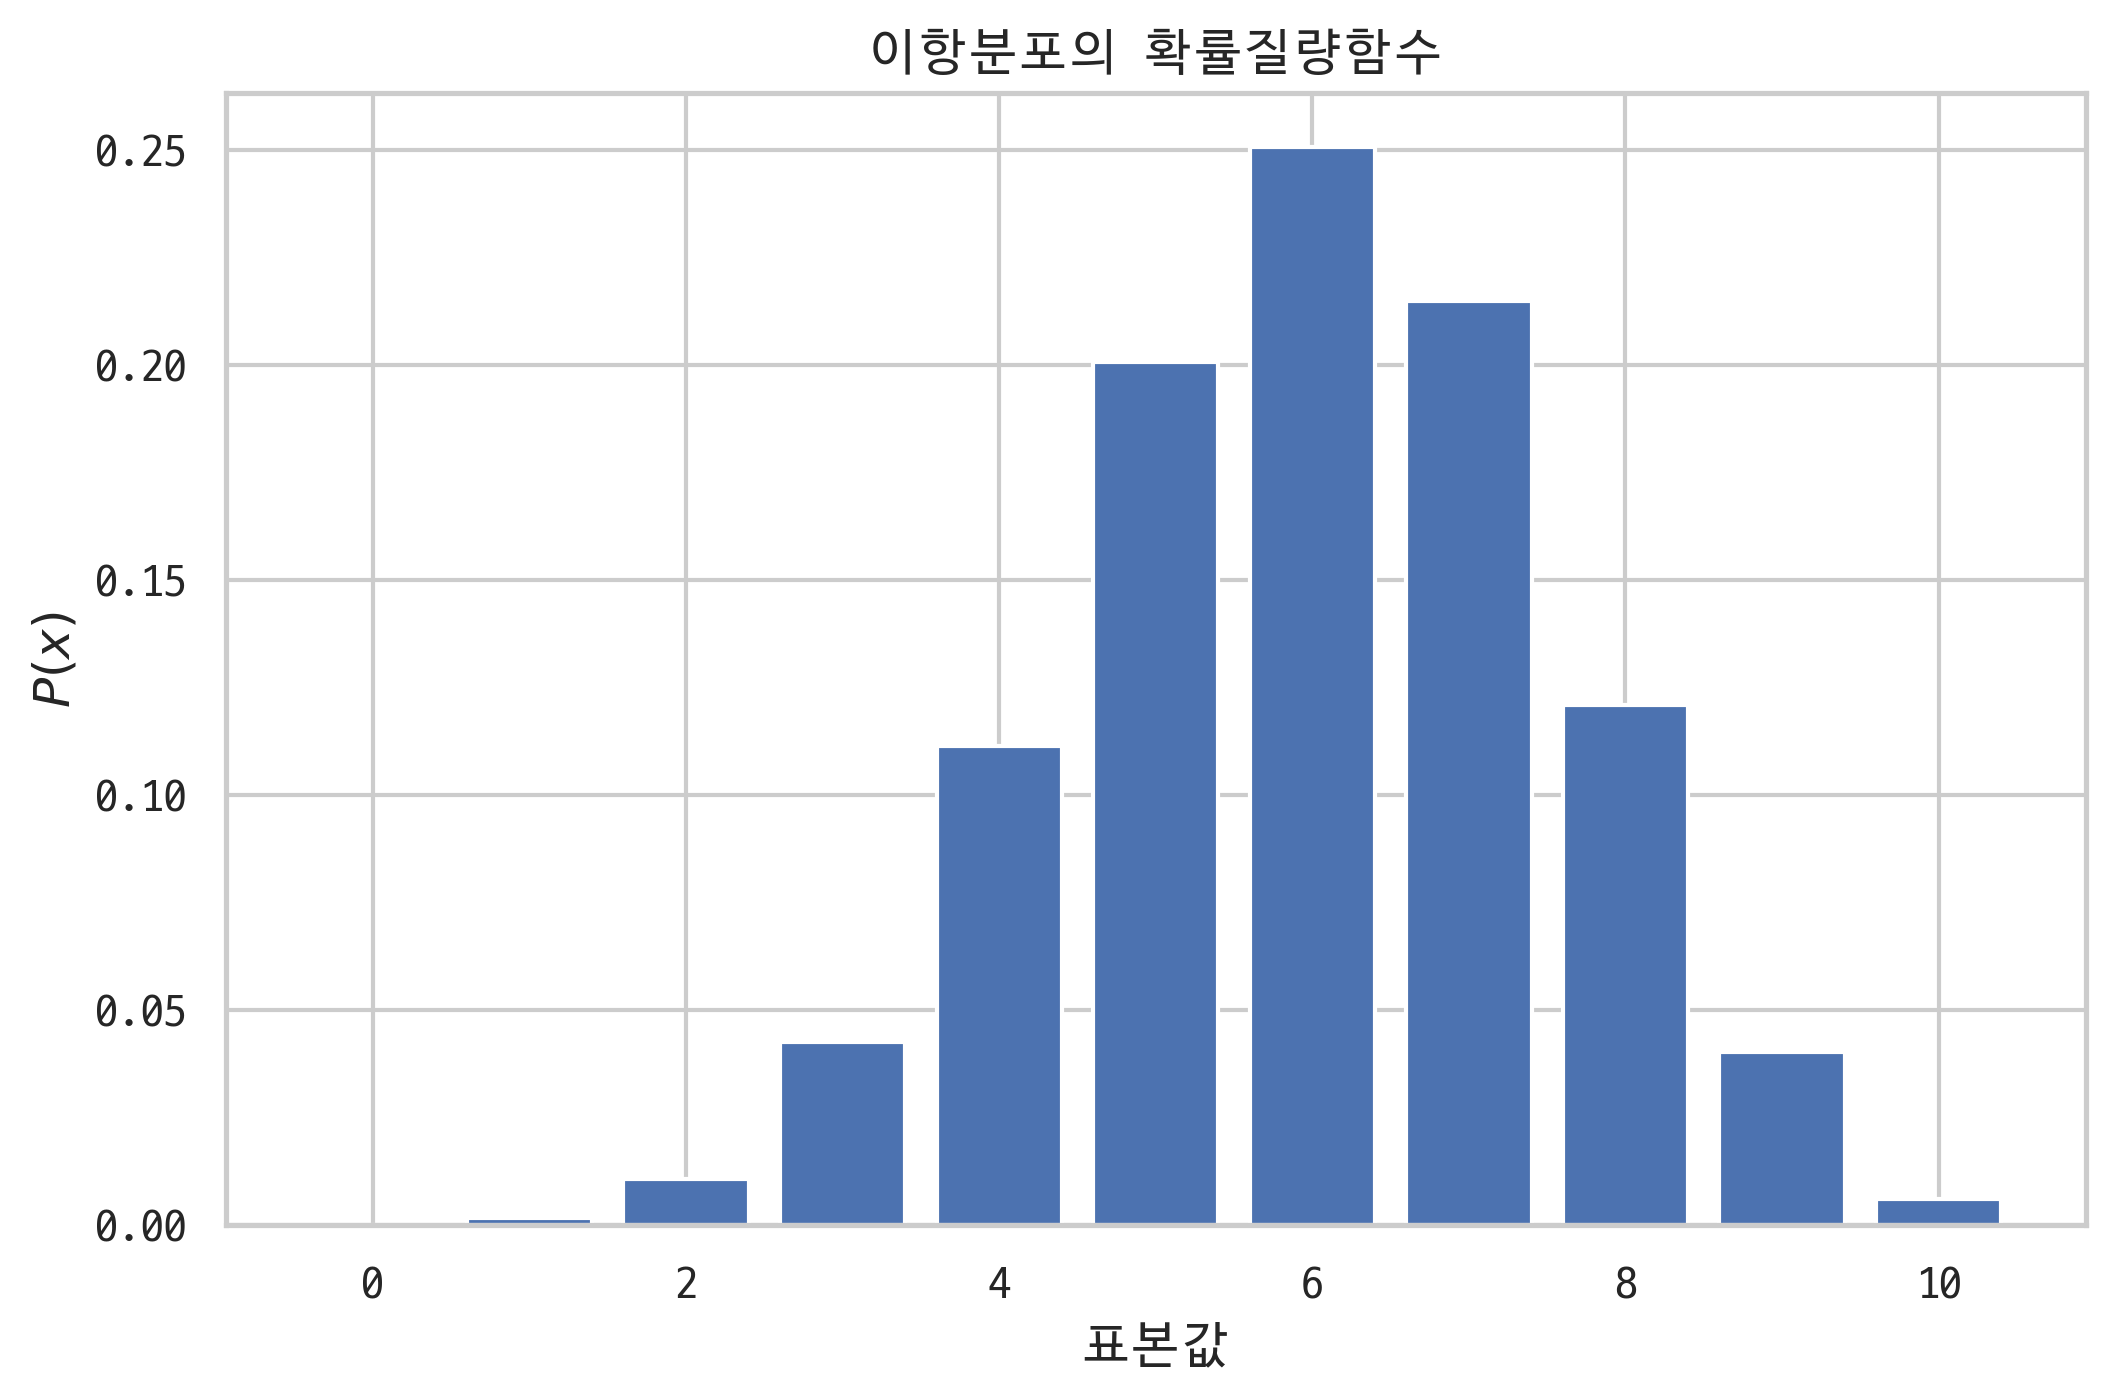

In [200]:
# 이항분포의 확률질량함수 그리기 - 베르누이 확률변수와 마찬가지로 이산확률변수이므로
xx = np.arange(N+1)
plt.bar(xx, rv.pmf(xx), align='center')
plt.xlabel('표본값')
plt.ylabel('$P(x)$')
plt.title('이항분포의 확률질량함수')
plt.show()

In [201]:
# 이항분포 시뮬레이션 - 무작위 표본 생성
np.random.seed(0)
x = rv.rvs(100)
x

array([ 6,  5,  6,  6,  6,  5,  6,  4,  3,  6,  5,  6,  6,  4,  8,  8,  9,
        5,  5,  4,  3,  5,  6,  5,  8,  5,  8,  4,  6,  6,  7,  5,  6,  6,
        9,  6,  6,  6,  4,  5,  7,  6,  5,  8,  5,  5,  7,  8,  7,  7,  6,
        6,  2,  8,  7,  8,  5,  7,  6,  7,  8,  8,  5,  8,  7,  7,  5,  8,
        4,  8,  3,  6,  3,  6,  5,  9,  7,  8,  7,  8,  7,  6,  8,  5,  6,
        7,  6,  8,  6,  4,  7,  5,  8,  5,  7,  7,  6,  9,  5, 10])

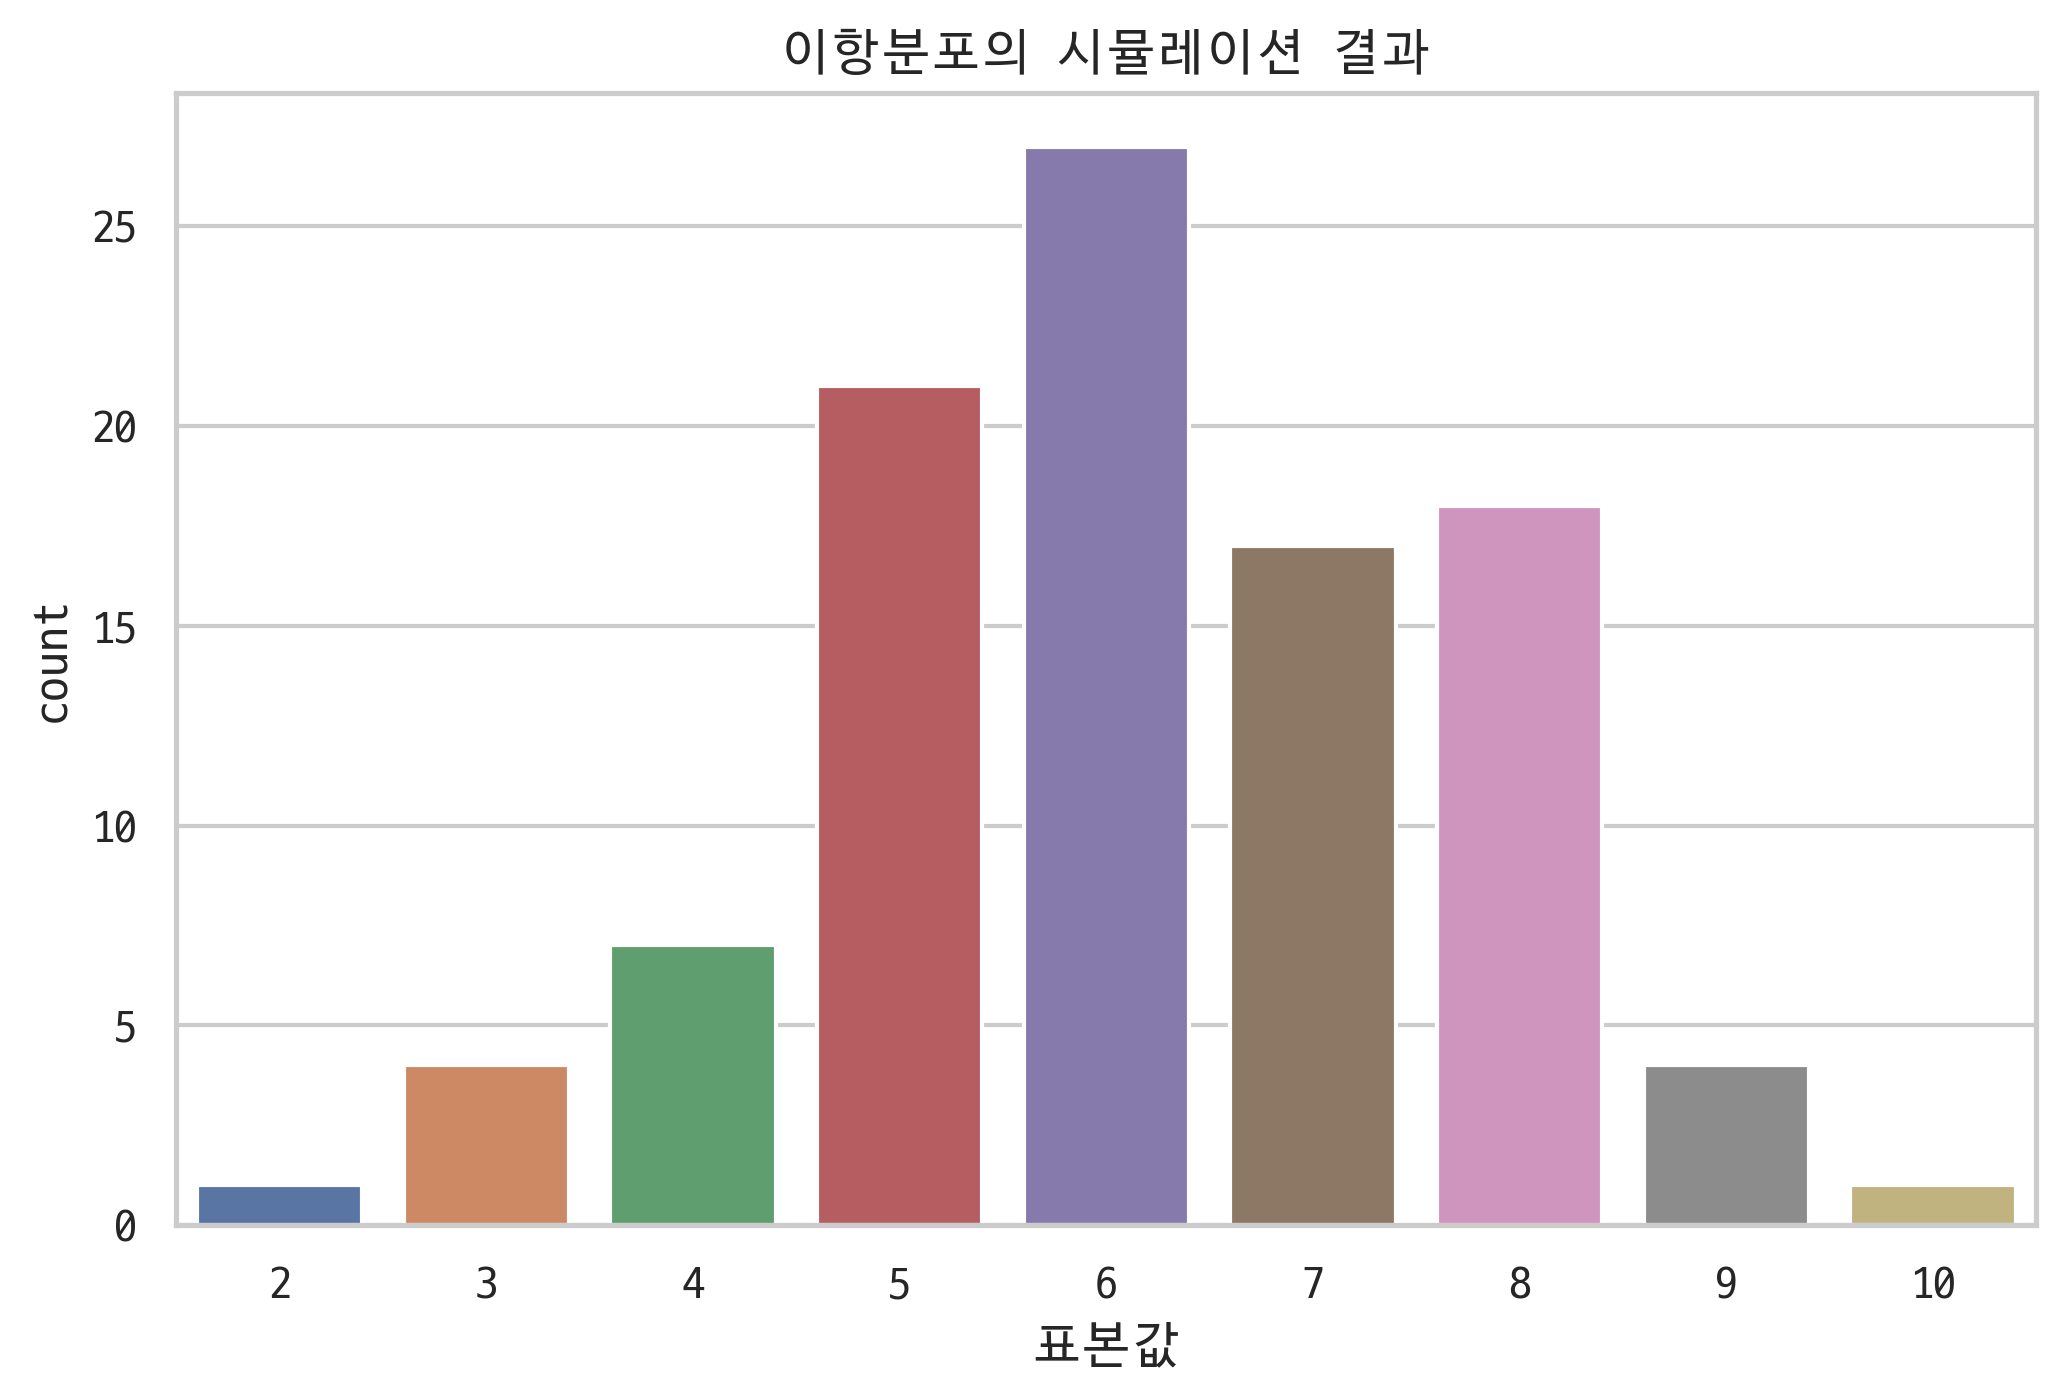

In [203]:
# 생성 결과 시각화
sns.countplot(x)
plt.title('이항분포의 시뮬레이션 결과')
plt.xlabel('표본값')
plt.show()

In [205]:
# 이론적인 확률분포와 표본의 확률 분포를 같이 나타내려면
y = np.bincount(x, minlength=N+1) / float(len(x))
y

array([0.  , 0.  , 0.01, 0.04, 0.07, 0.21, 0.27, 0.17, 0.18, 0.04, 0.01])

In [217]:
# 비교할 수 있는 데이터프레임 만들기
df = pd.DataFrame({'이론': rv.pmf(xx), '시뮬레이션': y})
df = df.stack().reset_index()
df.columns = ['표본값', '유형', '비율']
df.pivot('표본값', '유형', '비율')

유형,시뮬레이션,이론
표본값,,
0,0.00,0.000105
1,0.00,0.001573
2,0.01,0.010617
3,0.04,0.042467
4,0.07,0.111477
5,0.21,0.200658
6,0.27,0.250823
7,0.17,0.214991
8,0.18,0.120932


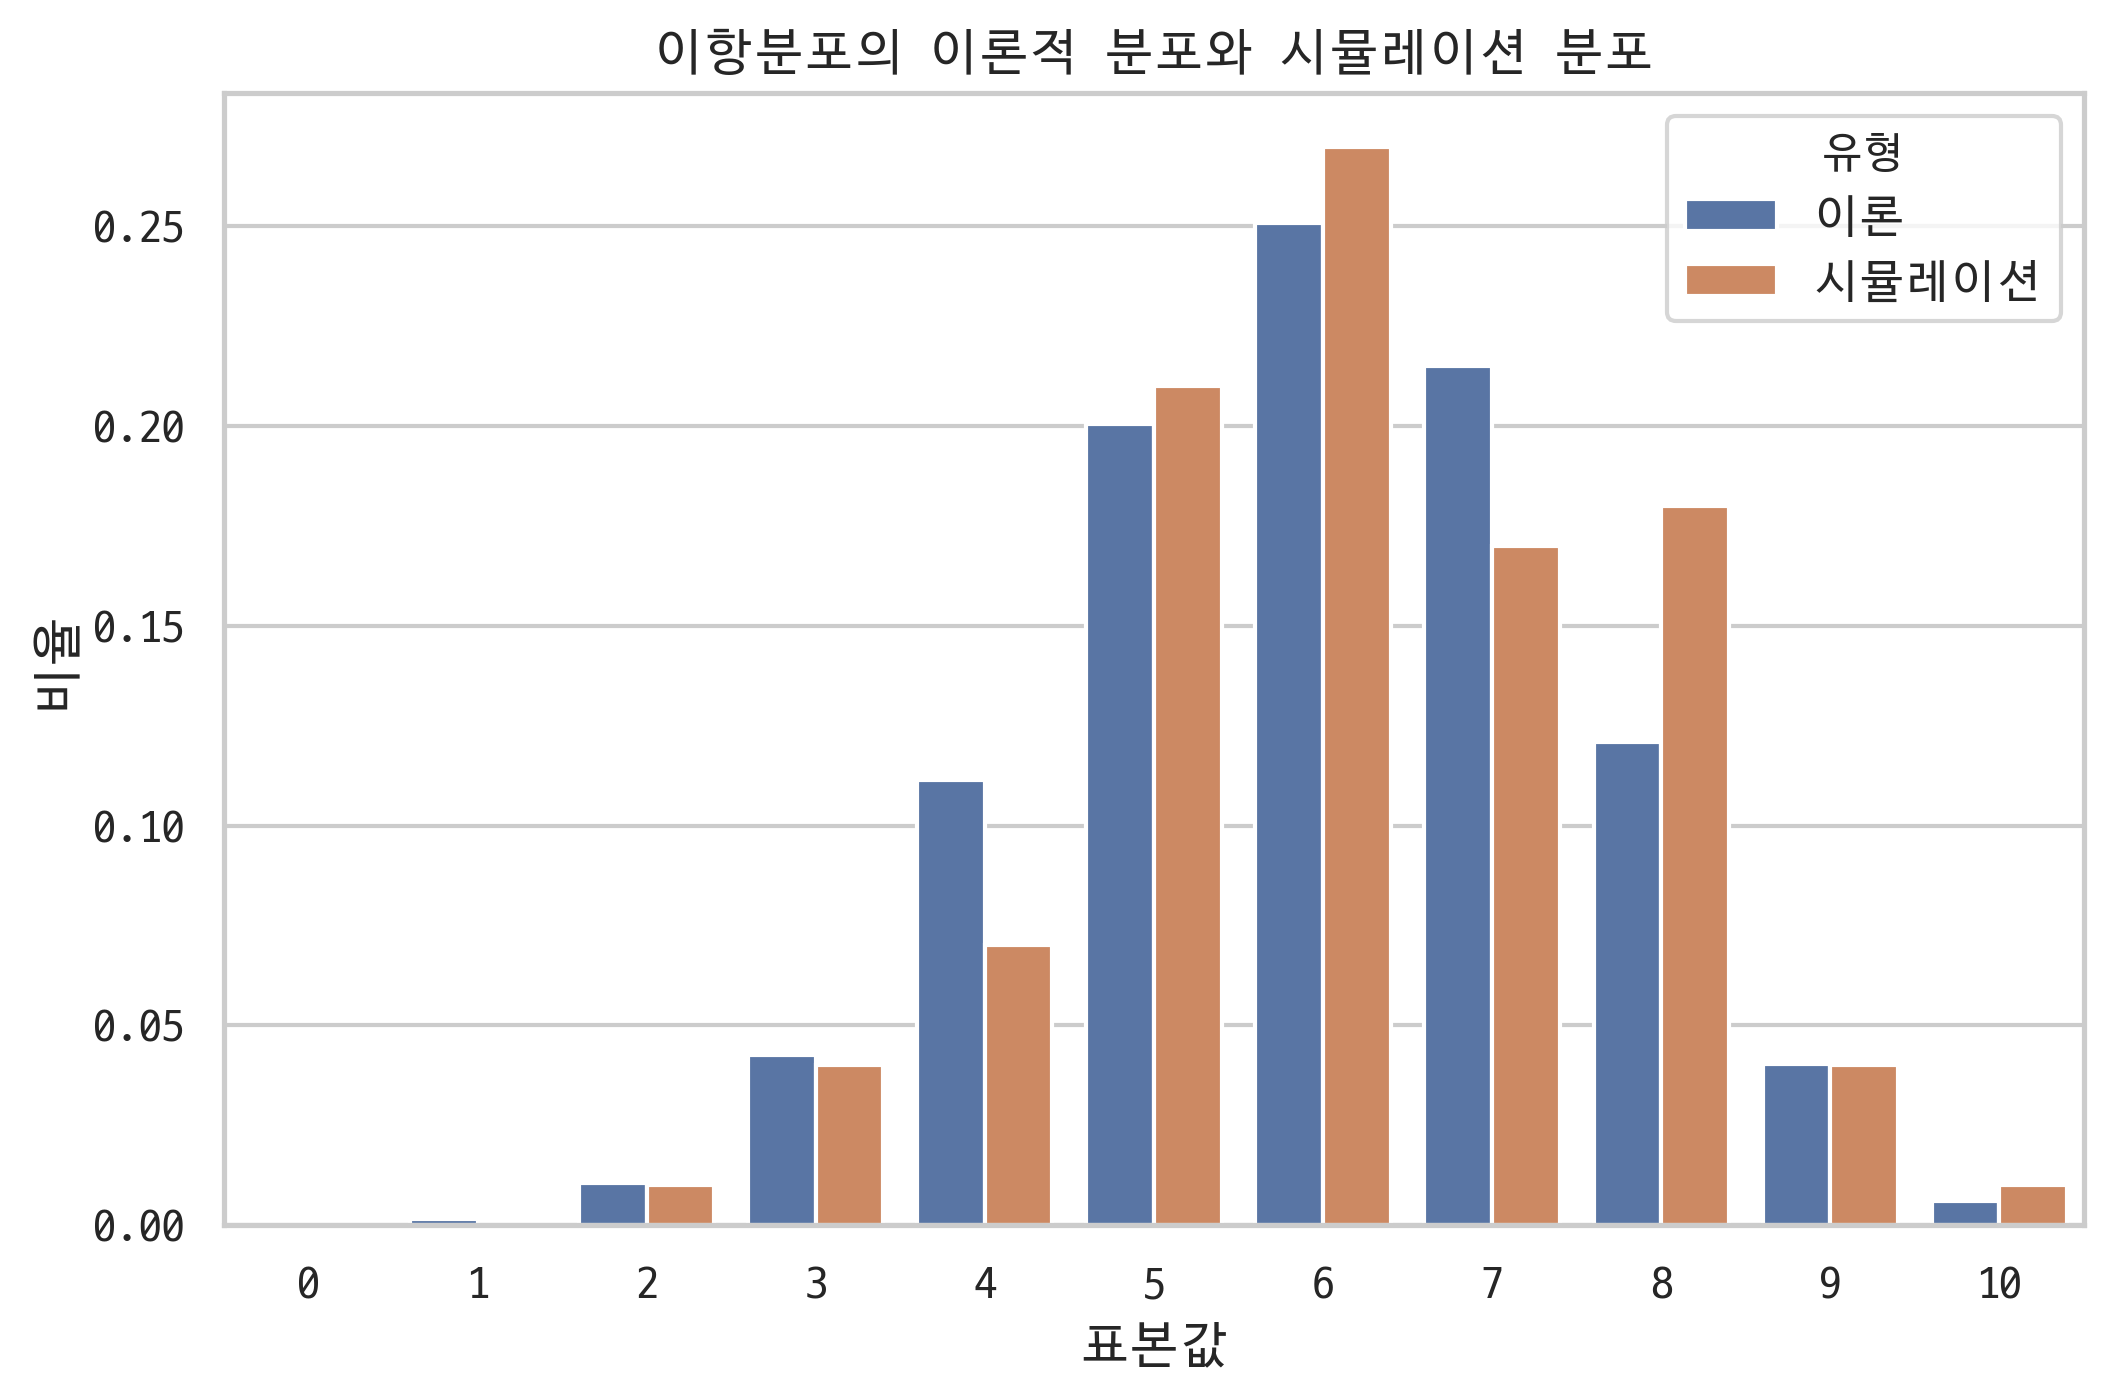

In [220]:
# 위의 df를 시각화
sns.barplot(x='표본값', y='비율', hue='유형', data=df)
plt.title('이항분포의 이론적 분포와 시뮬레이션 분포')
plt.show()

#### 연습문제 8.2.3
이항 확률분포의 모수가 다음과 같을 경우에 각각 표본을 생성한 후 기댓값과 분산을 구하고 앞의 예제와 같이 확률밀도함수와 비교한 바 플롯을 그린다.  
표본 개수가 10개인 경우와 1000개인 경우에 대해 각각 위의 계산을 한다.

(1)  𝜇=0.5 ,  𝑁=5  
(2)  𝜇=0.9 ,  𝑁=20

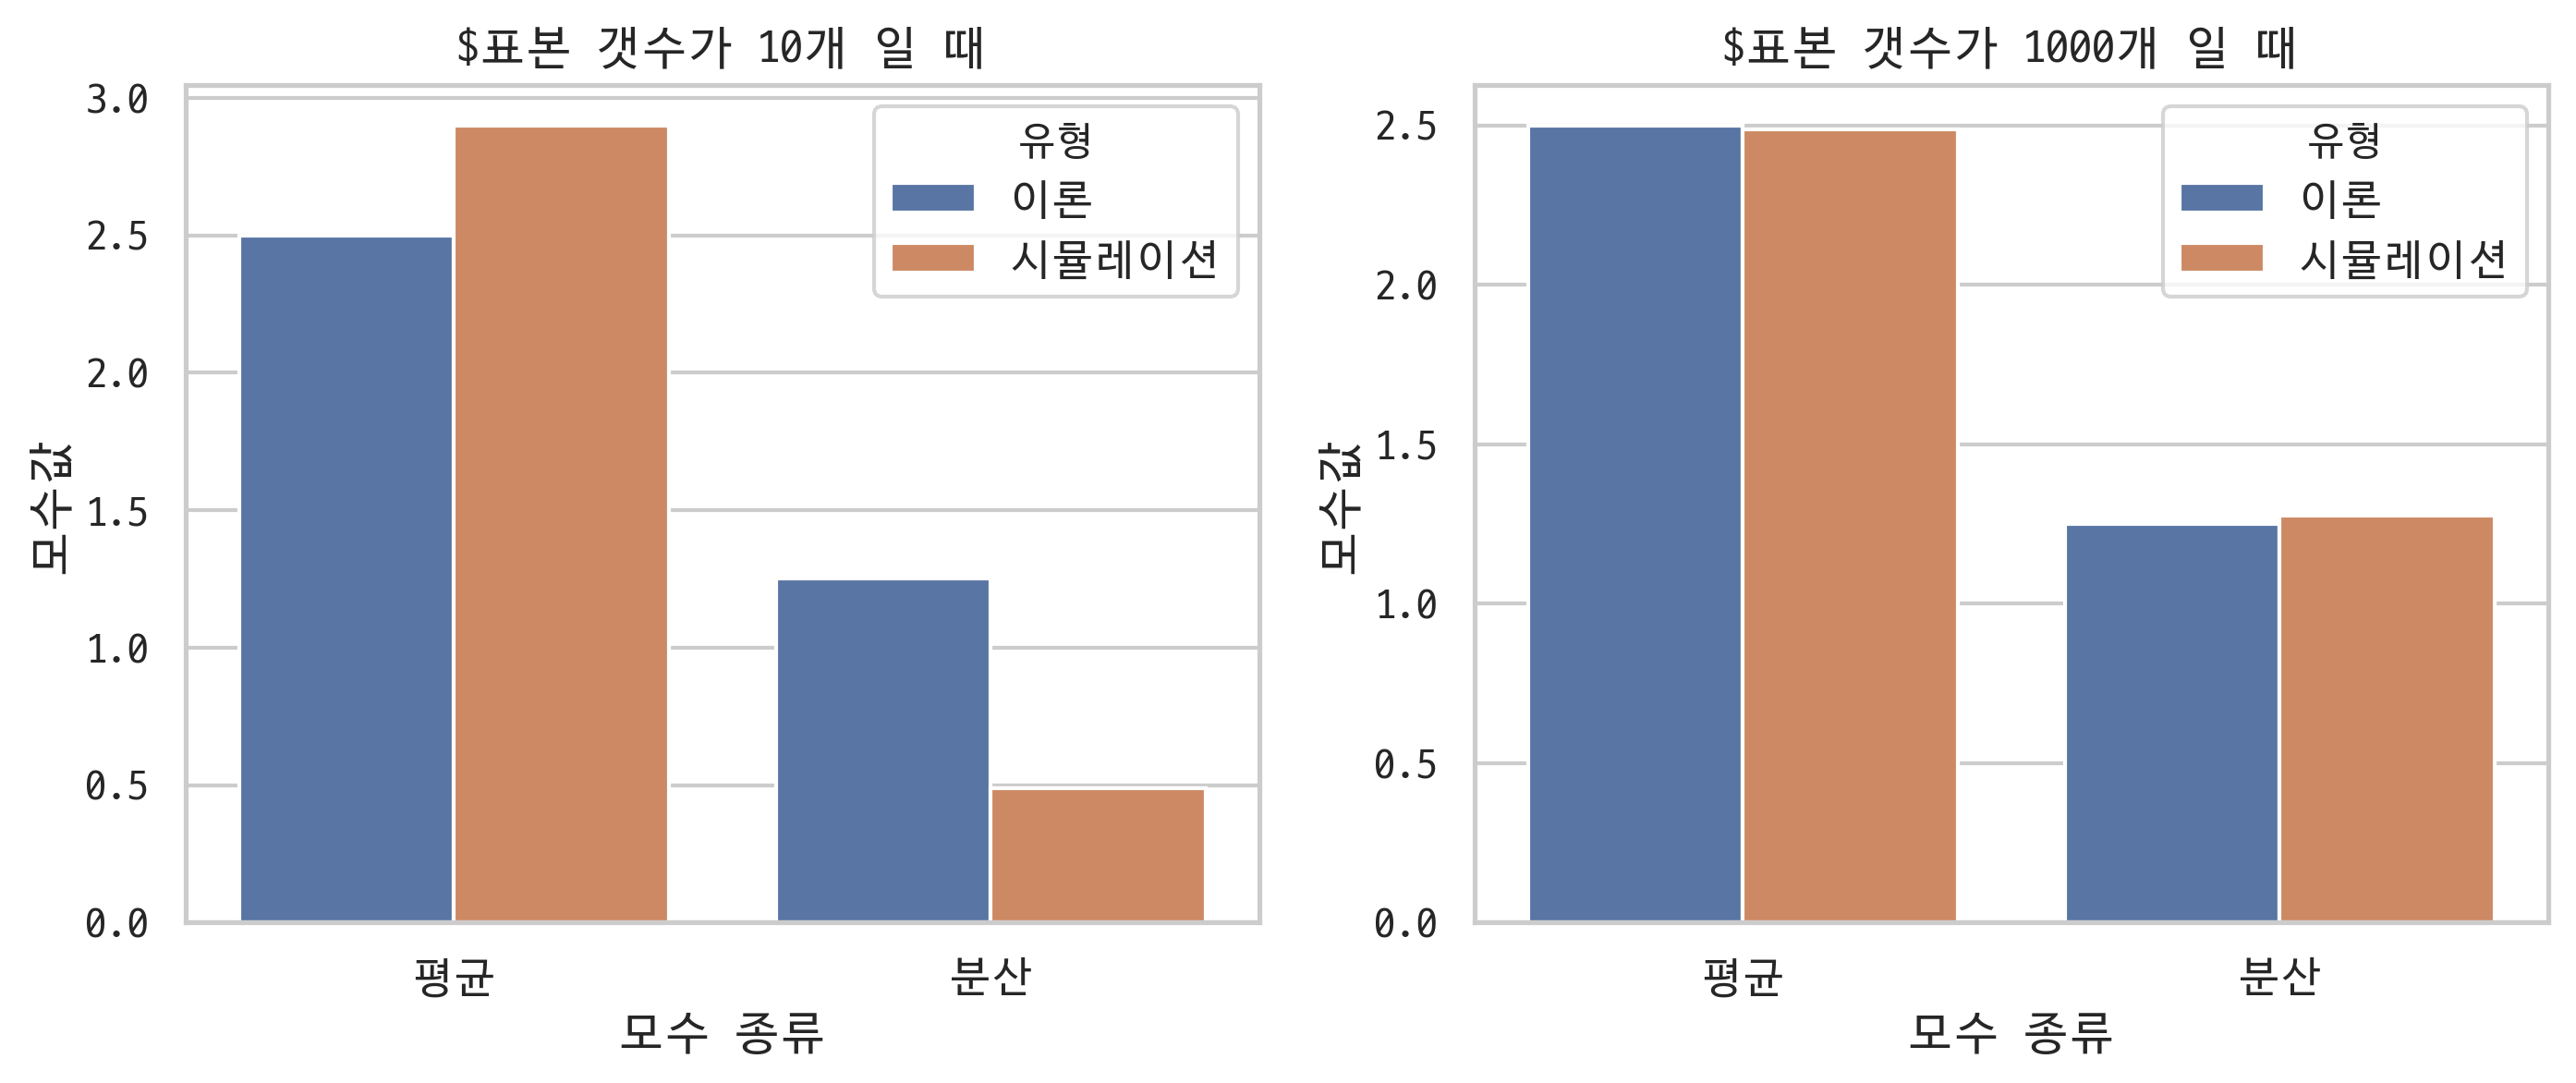

In [252]:
# (1) 기댓값이 0.5, 시행횟수가 5 일 때
# 1) 표본 개수가 10개 일 때
N = 5
mu = 0.5
rv = sp.stats.binom(N, mu)

xx1 = rv.rvs(10, random_state=0) #시뮬레이션 - 표본 개수 10개

df1_1 = pd.DataFrame({'이론': [N*mu, N*mu*(1-mu)], '시뮬레이션': [np.mean(xx1), np.var(xx1)]})
df1_1.index = ['평균', '분산']
df1_1 = df1_1.stack().reset_index()
df1_1.columns = ['모수 종류', '유형', '모수값']

# 1) 표본 개수가 1000개 일 때
xx2 = rv.rvs(1000, random_state=0) #시뮬레이션 - 표본 개수 1000개

df1_2 = pd.DataFrame({'이론': [N*mu, N*mu*(1-mu)], '시뮬레이션': [np.mean(xx2), np.var(xx2)]})
df1_2.index = ['평균', '분산']
df1_2 = df1_2.stack().reset_index()
df1_2.columns = ['모수 종류', '유형', '모수값']

# 시각화하기
plt.figure(figsize=(11, 4))
plt.subplot(121)
sns.barplot(x='모수 종류', y='모수값', hue='유형', data=df1_1)
plt.title('$표본 갯수가 10개 일 때')

plt.subplot(122)
sns.barplot(x='모수 종류', y='모수값', hue='유형', data=df1_2)
plt.title('$표본 갯수가 1000개 일 때')
plt.show()

In [253]:
df1_1.pivot('모수 종류', '유형', '모수값' )

유형,시뮬레이션,이론
모수 종류,,
분산,0.49,1.25
평균,2.90,2.50


In [254]:
df1_2.pivot('모수 종류', '유형', '모수값' )

유형,시뮬레이션,이론
모수 종류,,
분산,1.275856,1.25
평균,2.488000,2.50


In [ ]:
N = 5
mu = 0.5
rv = sp.stats.binom(N, mu)

xx2 = rv.rvs(1000, random_state=0) #시뮬레이션 - 표본 개수 1000개

df1_2 = pd.DataFrame({'이론': [N*mu, N*mu*(1-mu)], '시뮬레이션': [np.mean(xx2), np.var(xx2)]})
df1_2.index = ['평균', '분산']
df1_2 = df1_2.stack().reset_index()
df1_2.columns = ['모수 종류', '유형', '모수값']

# 시각화하기
plt.figure(figsize=(11, 4))
plt.subplot(121)
sns.barplot(x='모수 종류', y='모수값', hue='유형', data=df1_1)
plt.title('$표본 갯수가 10개 일 때')

plt.subplot(122)
sns.barplot(x='모수 종류', y='모수값', hue='유형', data=df1_2)
plt.title('$표본 갯수가 1000개 일 때')
plt.show()

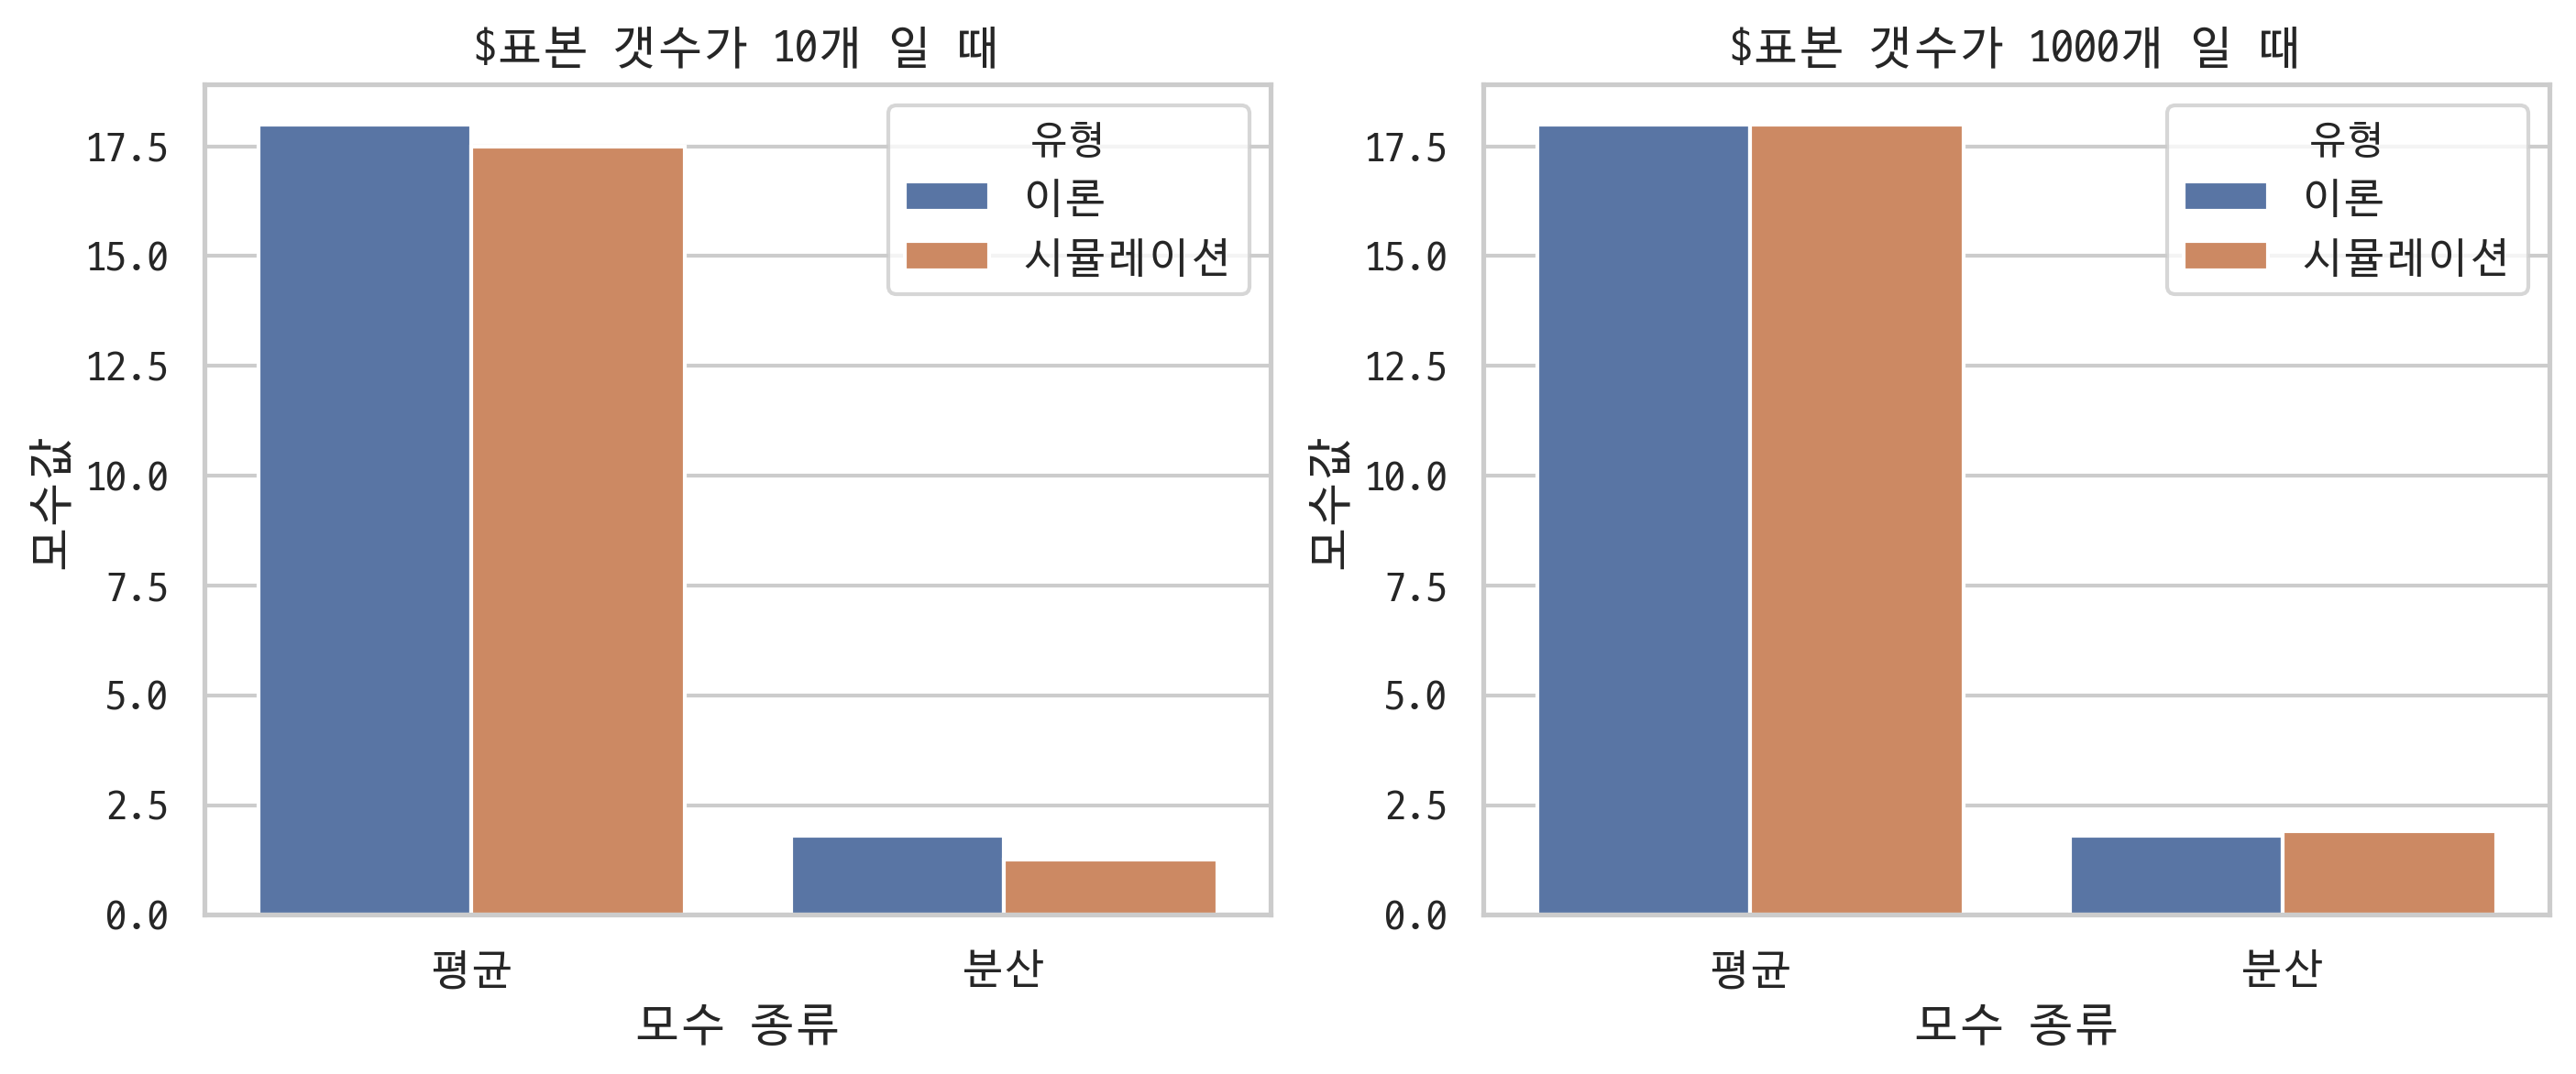

In [255]:
# (2) 기댓값이 0.9, 시행횟수가 20 일 때
# 1) 표본 개수가 10개 일 때
N = 20
mu = 0.9
rv = sp.stats.binom(N, mu)

xx1 = rv.rvs(10, random_state=0) #시뮬레이션 - 표본 개수 10개

df1_1 = pd.DataFrame({'이론': [N*mu, N*mu*(1-mu)], '시뮬레이션': [np.mean(xx1), np.var(xx1)]})
df1_1.index = ['평균', '분산']
df1_1 = df1_1.stack().reset_index()
df1_1.columns = ['모수 종류', '유형', '모수값']

# 1) 표본 개수가 1000개 일 때
xx2 = rv.rvs(1000, random_state=0) #시뮬레이션 - 표본 개수 1000개

df1_2 = pd.DataFrame({'이론': [N*mu, N*mu*(1-mu)], '시뮬레이션': [np.mean(xx2), np.var(xx2)]})
df1_2.index = ['평균', '분산']
df1_2 = df1_2.stack().reset_index()
df1_2.columns = ['모수 종류', '유형', '모수값']

# 시각화하기
plt.figure(figsize=(11, 4))
plt.subplot(121)
sns.barplot(x='모수 종류', y='모수값', hue='유형', data=df1_1)
plt.title('$표본 갯수가 10개 일 때')

plt.subplot(122)
sns.barplot(x='모수 종류', y='모수값', hue='유형', data=df1_2)
plt.title('$표본 갯수가 1000개 일 때')
plt.show()

In [256]:
df1_1.pivot('모수 종류', '유형', '모수값' )

유형,시뮬레이션,이론
모수 종류,,
분산,1.25,1.8
평균,17.50,18.0


In [257]:
df1_2.pivot('모수 종류', '유형', '모수값' )

유형,시뮬레이션,이론
모수 종류,,
분산,1.912991,1.8
평균,17.997000,18.0


### 베르누이분포와 이항분포의 모수추정

# 3. 카테고리 분포와 다항분포

### Scipy를 이용한 카테고리분포의 시뮬레이션

In [258]:
# 카테고리 분포를 따르는 확률변수 생성
mu = [0.1, 0.1, 0.1, 0.1, 0.3, 0.3]
rv = sp.stats.multinomial(1, mu) #다항분포를 위한 multinomial 클래스에서 시행횟수를 1로 주면, 카테고리 분포

In [263]:
xx = np.arange(1, 7)
xx_ohe = pd.get_dummies(xx) # 원핫인코딩
xx_ohe

,1,2,3,4,5,6
0,1,0,0,0,0,0
1,0,1,0,0,0,0
2,0,0,1,0,0,0
3,0,0,0,1,0,0
4,0,0,0,0,1,0
5,0,0,0,0,0,1


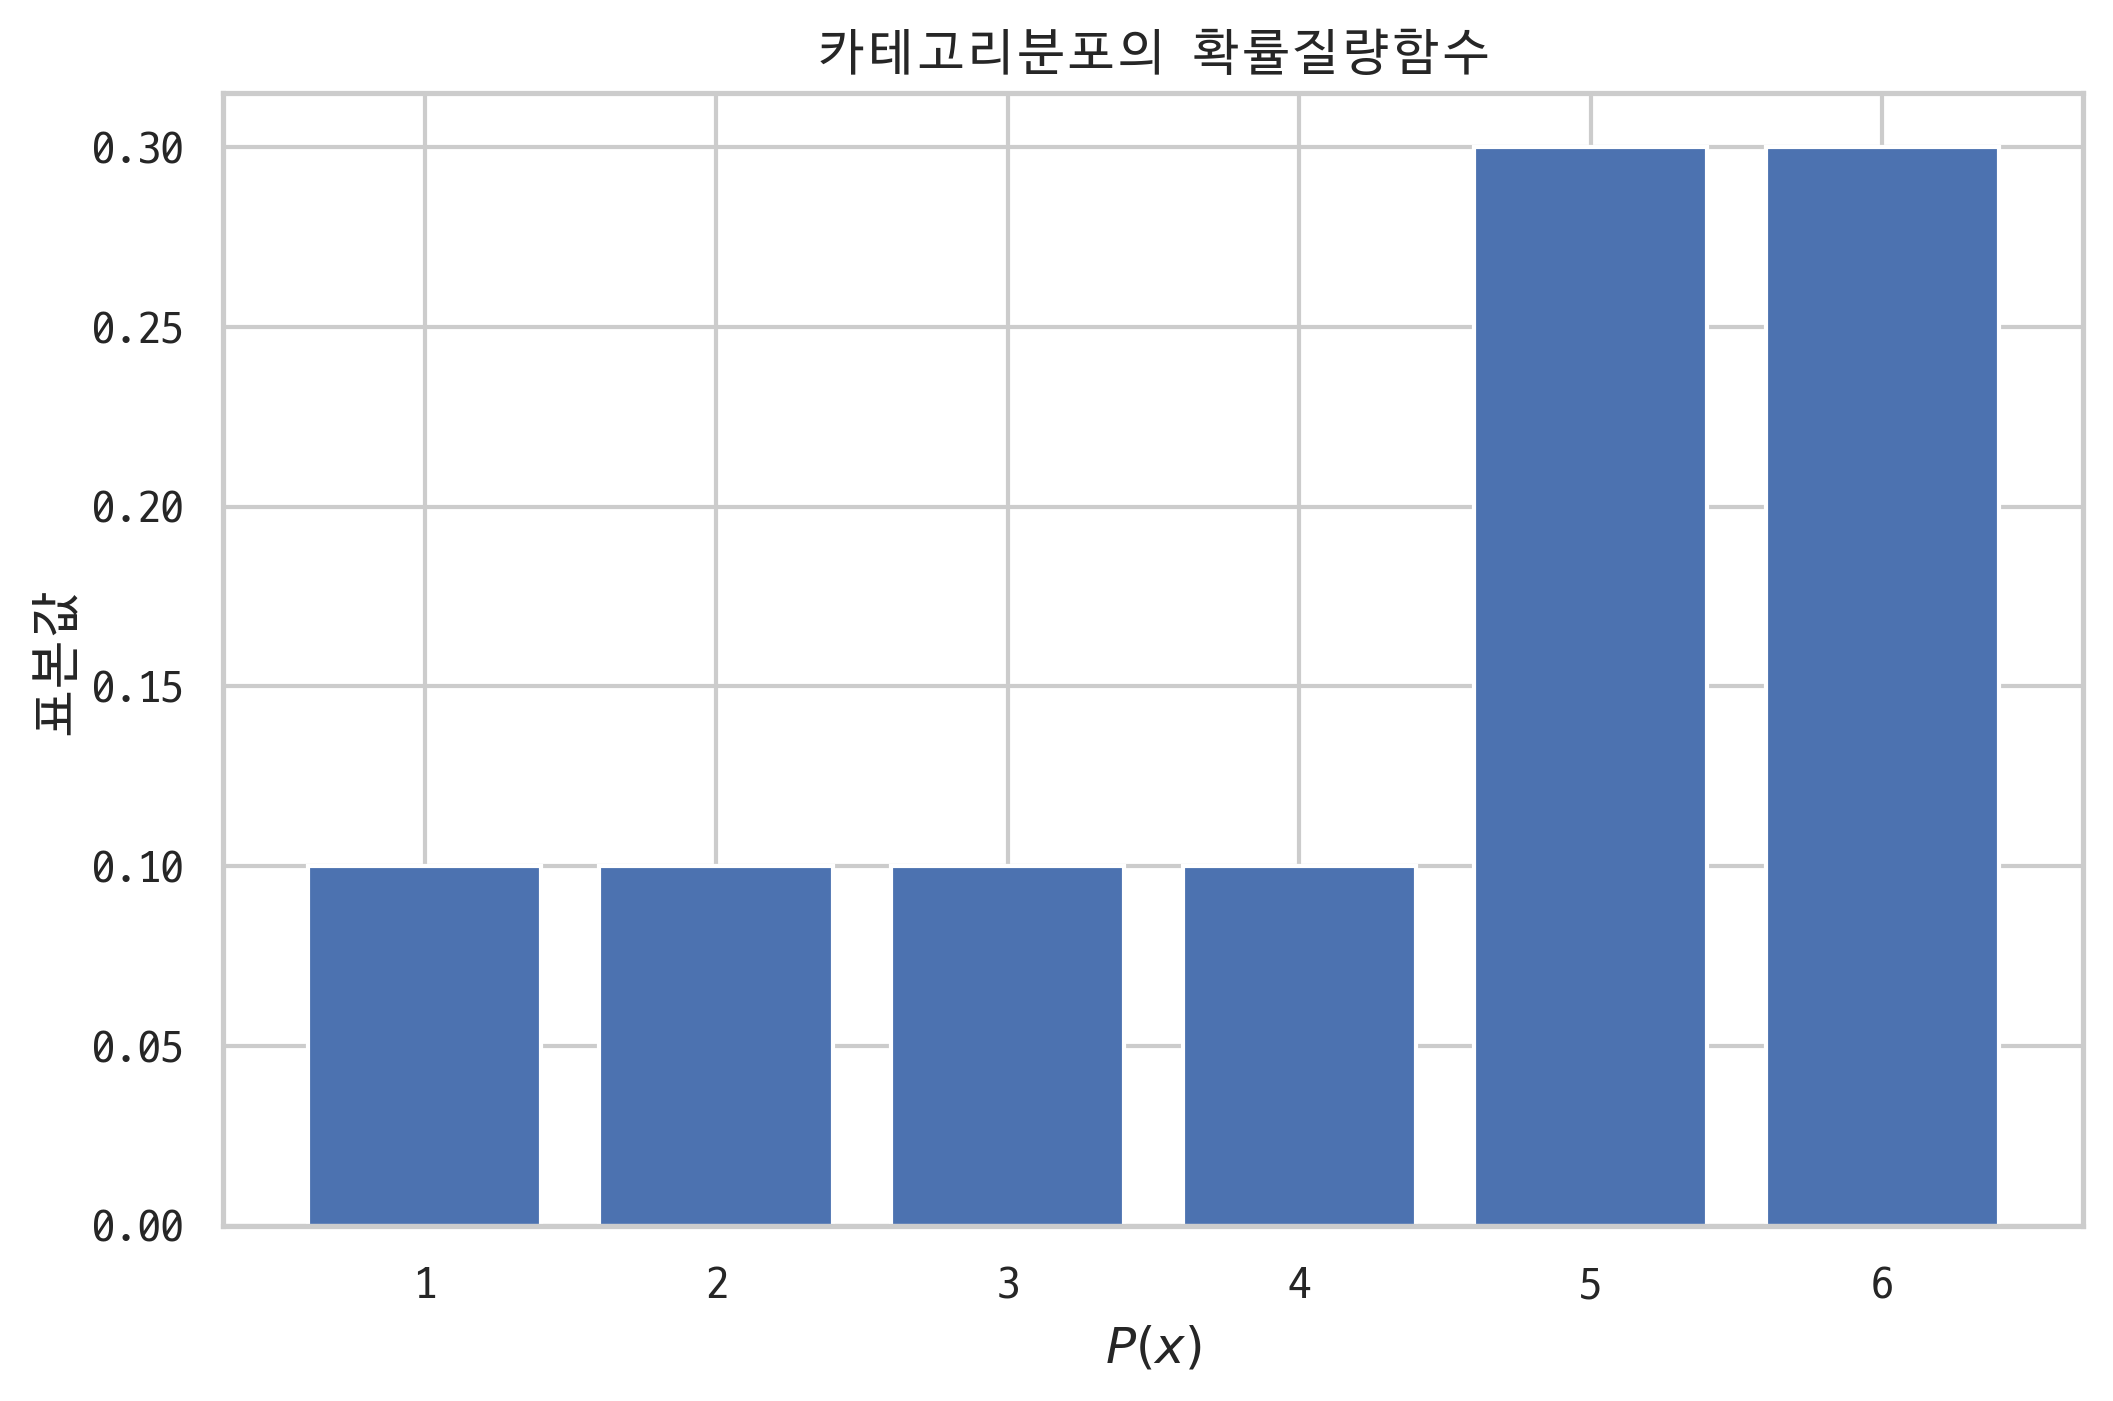

In [265]:
# 카테고리분포의 확률질량함수 - 이산확률변수
plt.bar(xx, rv.pmf(xx_ohe.values))
plt.xlabel('$P(x)$')
plt.ylabel('표본값')
plt.title('카테고리분포의 확률질량함수')
plt.show()

In [267]:
# 시뮬레이션
np.random.seed(0)
x = rv.rvs(100) #rvs 메서드로 생성한 값도 원핫인코딩이다.
x[:5]

array([[0, 0, 0, 0, 0, 1],
       [0, 0, 1, 0, 0, 0],
       [1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1, 0]])

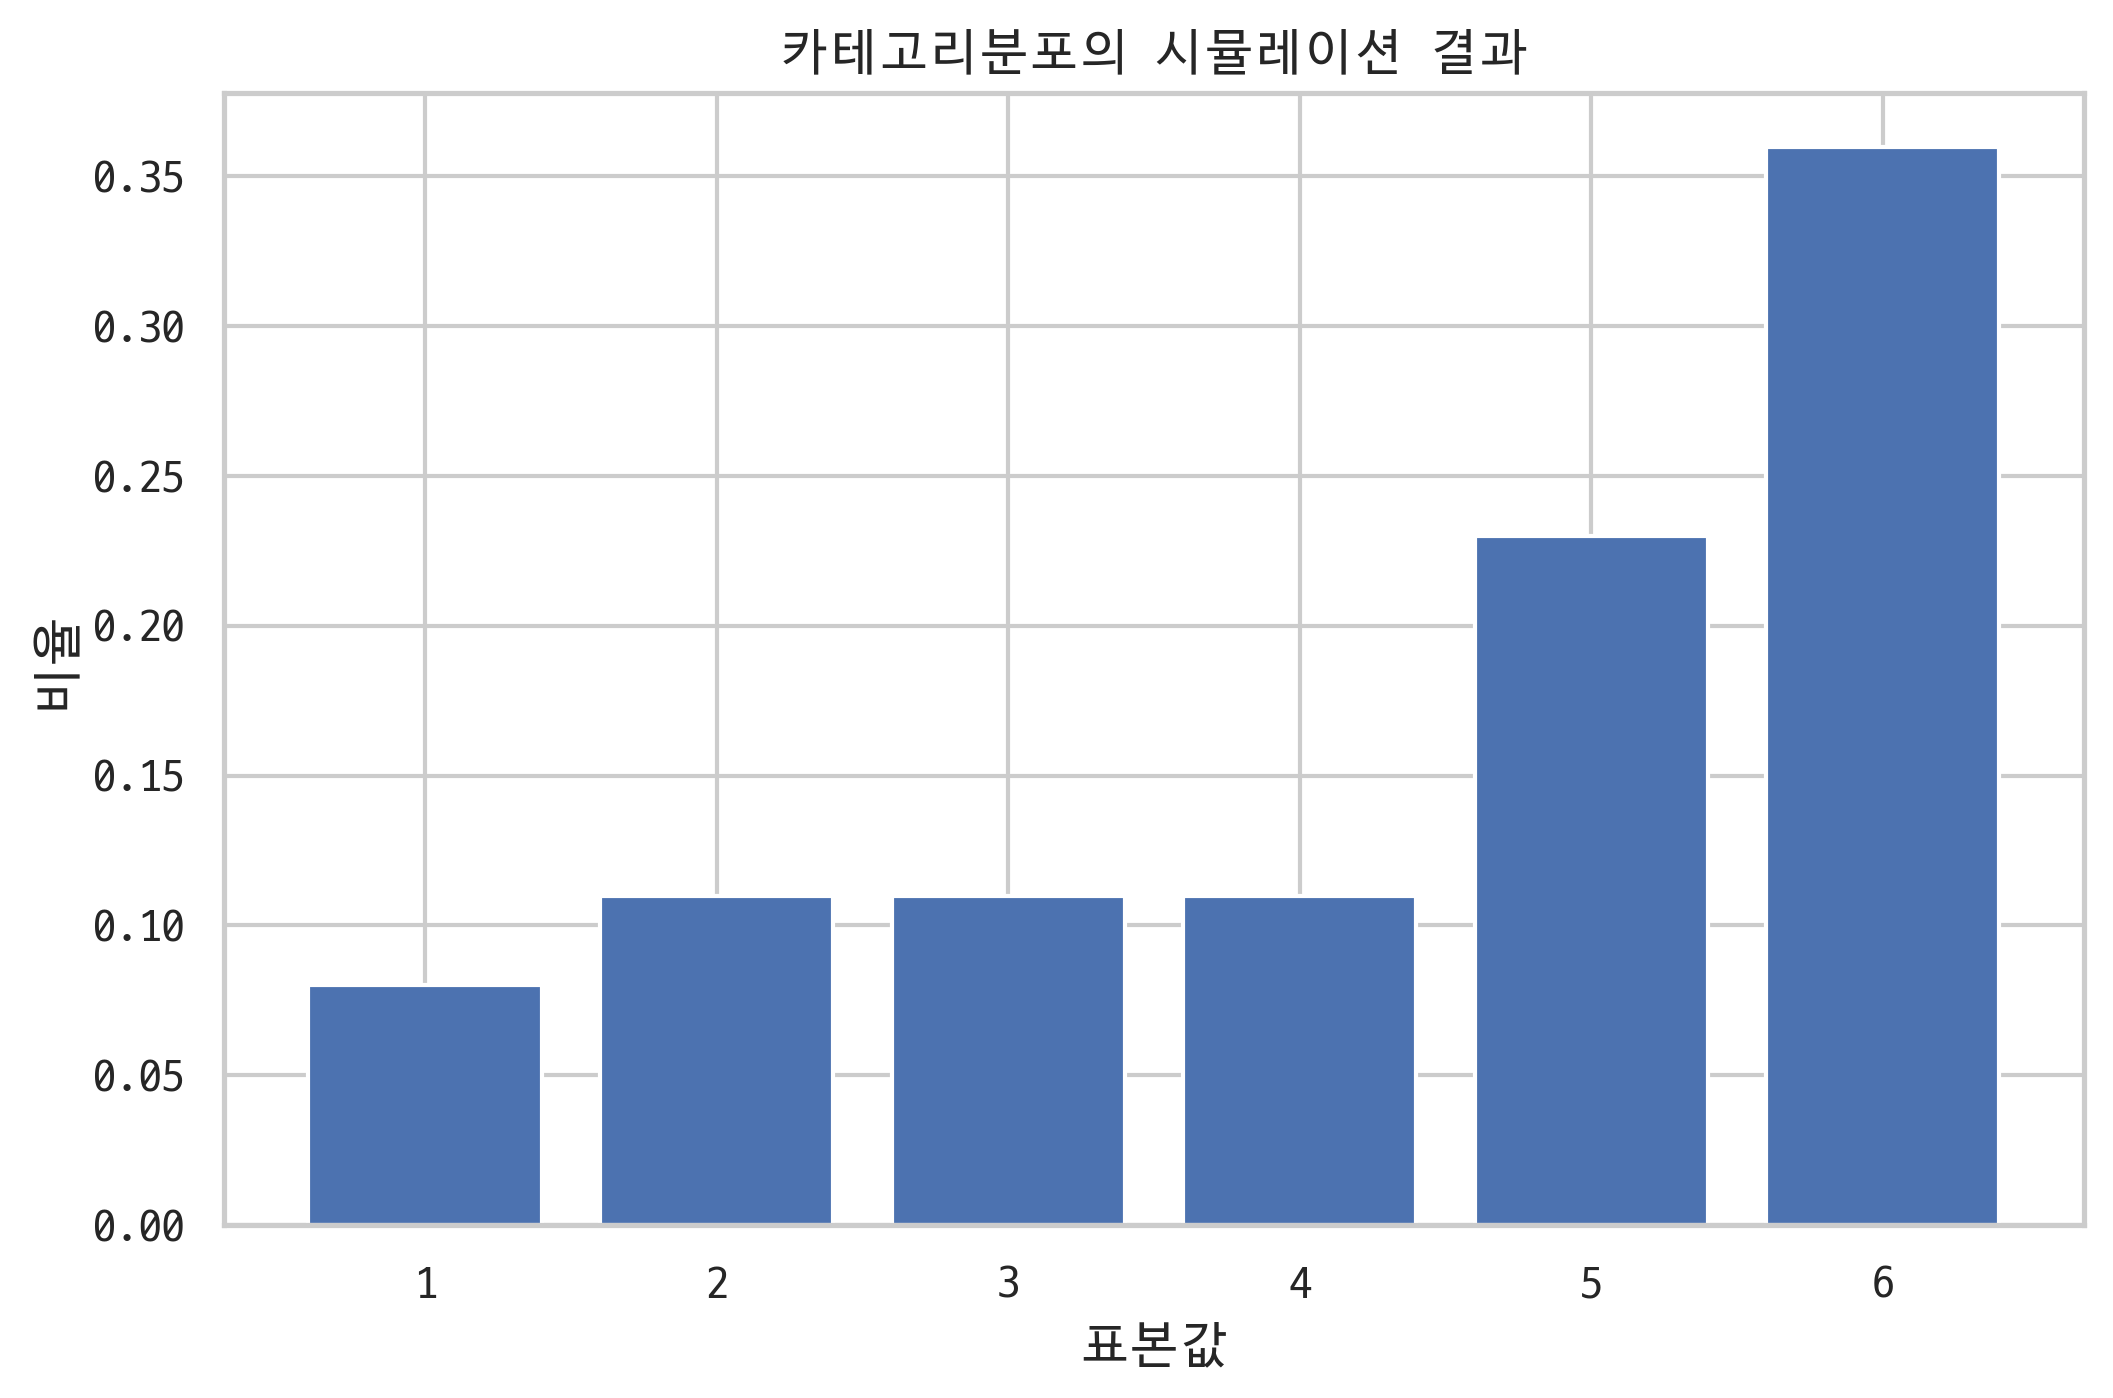

In [268]:
# 시뮬레이션 시각화하기
y = x.sum(axis=0) / float(len(x))
plt.bar(np.arange(1, 7), y)
plt.title('카테고리분포의 시뮬레이션 결과')
plt.xlabel('표본값')
plt.ylabel('비율')
plt.show()

In [272]:
df = pd.DataFrame({'이론': rv.pmf(xx_ohe.values), '시뮬레이션': y}, index=np.arange(1, 7))
df = df.stack().reset_index()
df.columns = ['표본값', '유형', '비율']
df.pivot('표본값', '유형', '비율')

유형,시뮬레이션,이론
표본값,,
1,0.08,0.1
2,0.11,0.1
3,0.11,0.1
4,0.11,0.1
5,0.23,0.3
6,0.36,0.3


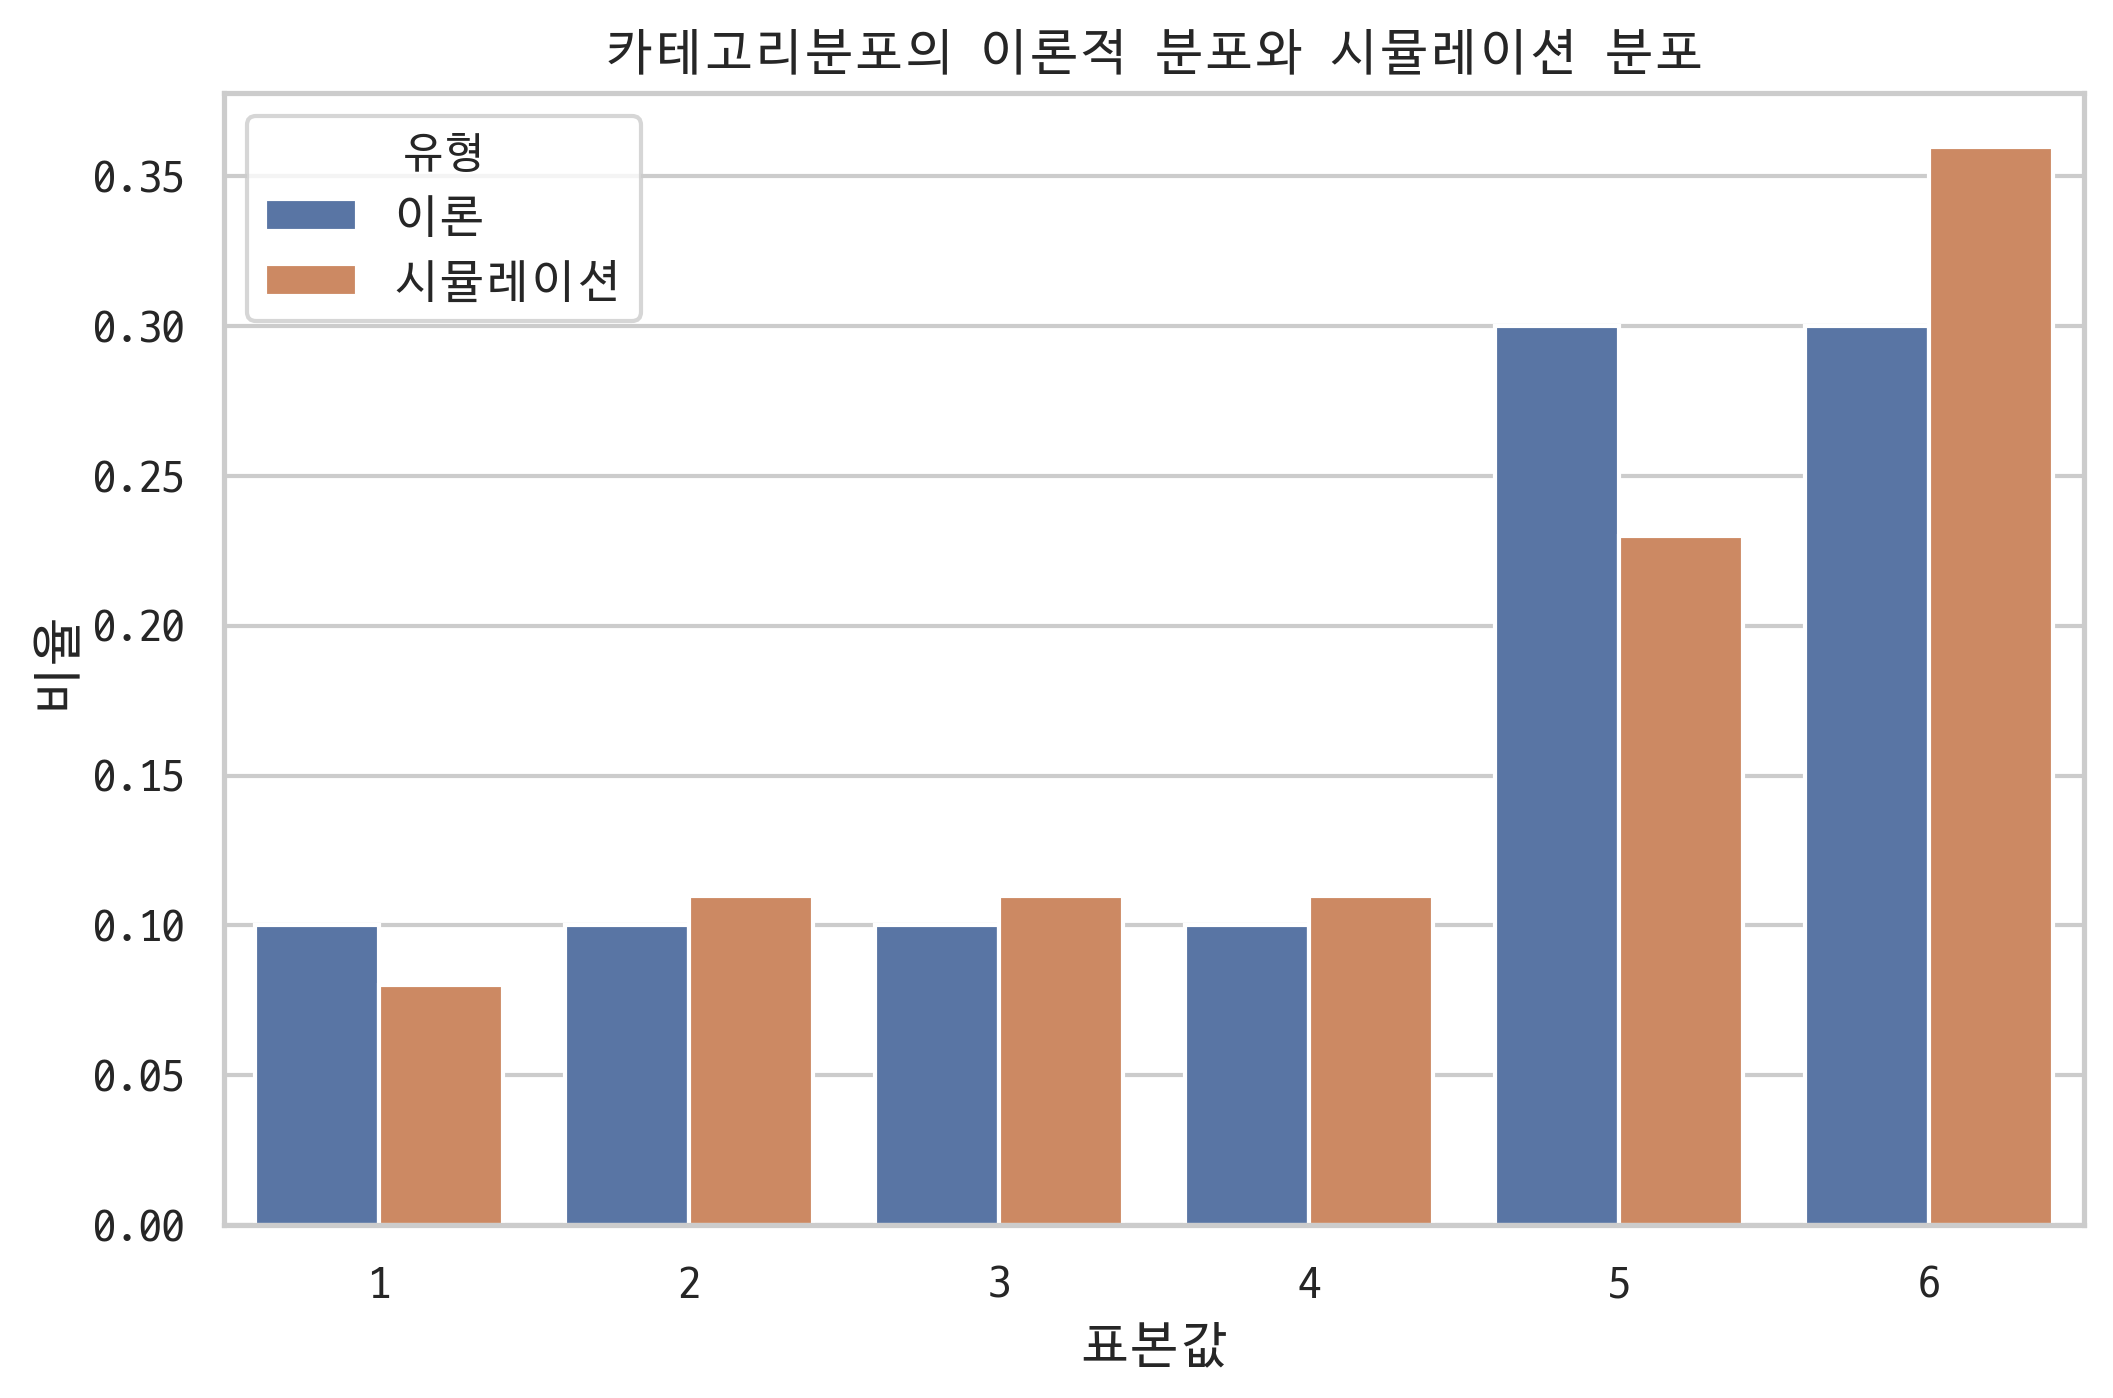

In [274]:
sns.barplot(x='표본값', y='비율', hue='유형', data=df)
plt.title('카테고리분포의 이론적 분포와 시뮬레이션 분포')
plt.show()

### 연습 문제 8.3.2
카테고리 확률분포의 모수가 다음과 같을 경우에 각각 표본을 생성한 후 기댓값과 분산을 구하고 앞의 예제와 같이 확률밀도함수와 비교한 바 플롯을 그린다.  
표본이 10개인 경우와 1000개인 경우에 대해 각각 위의 계산을 한다.

(1)  𝜇=(0.25,0.25,0.25,0.25)  

(2)  𝜇=(0.3,0.3,0.2,0.2)

In [31]:
# (1) 의 경우
mu = [0.25, 0.25, 0.25, 0.25]
rv = sp.stats.multinomial(1, mu)

xx = np.arange(1, 5)
xx_ohe = pd.get_dummies(xx)

In [38]:
xx_ohe

,1,2,3,4
0,1,0,0,0
1,0,1,0,0
2,0,0,1,0
3,0,0,0,1


In [51]:
print(sp.stats.multinomial.pmf.__doc__)


        Multinomial probability mass function.

        Parameters
        ----------
        x : array_like
            Quantiles, with the last axis of `x` denoting the components.
        n : int
            Number of trials
        p : array_like
            Probability of a trial falling into each category; should sum to 1

        Returns
        -------
        pmf : ndarray or scalar
            Probability density function evaluated at `x`

        Notes
        -----
        `n` should be a positive integer. Each element of `p` should be in the
        interval :math:`[0,1]` and the elements should sum to 1. If they do not sum to
        1, the last element of the `p` array is not used and is replaced with the
        remaining probability left over from the earlier elements.
        


In [56]:
parameter = [np.mean(rv.pmf(xx_ohe.values)), np.var(rv.pmf(xx_ohe.values), ddof=1)]

In [57]:
x1 = rv.rvs(10)
sample = [np.mean(x1), np.var(x1)]

df1 = pd.DataFrame({'이론': parameter, '시뮬레이션': sample})
df1.index = ['평균', '분산']
df1 = df1.stack().reset_index()
df1.columns = ['모수 종류', '유형', '모수값']


x2 = rv.rvs(1000)
sample = [np.mean(x2), np.var(x2)]

df2 = pd.DataFrame({'이론': parameter, '시뮬레이션': sample})
df2.index = ['평균', '분산']
df2 = df2.stack().reset_index()
df2.columns = ['모수 종류', '유형', '모수값']

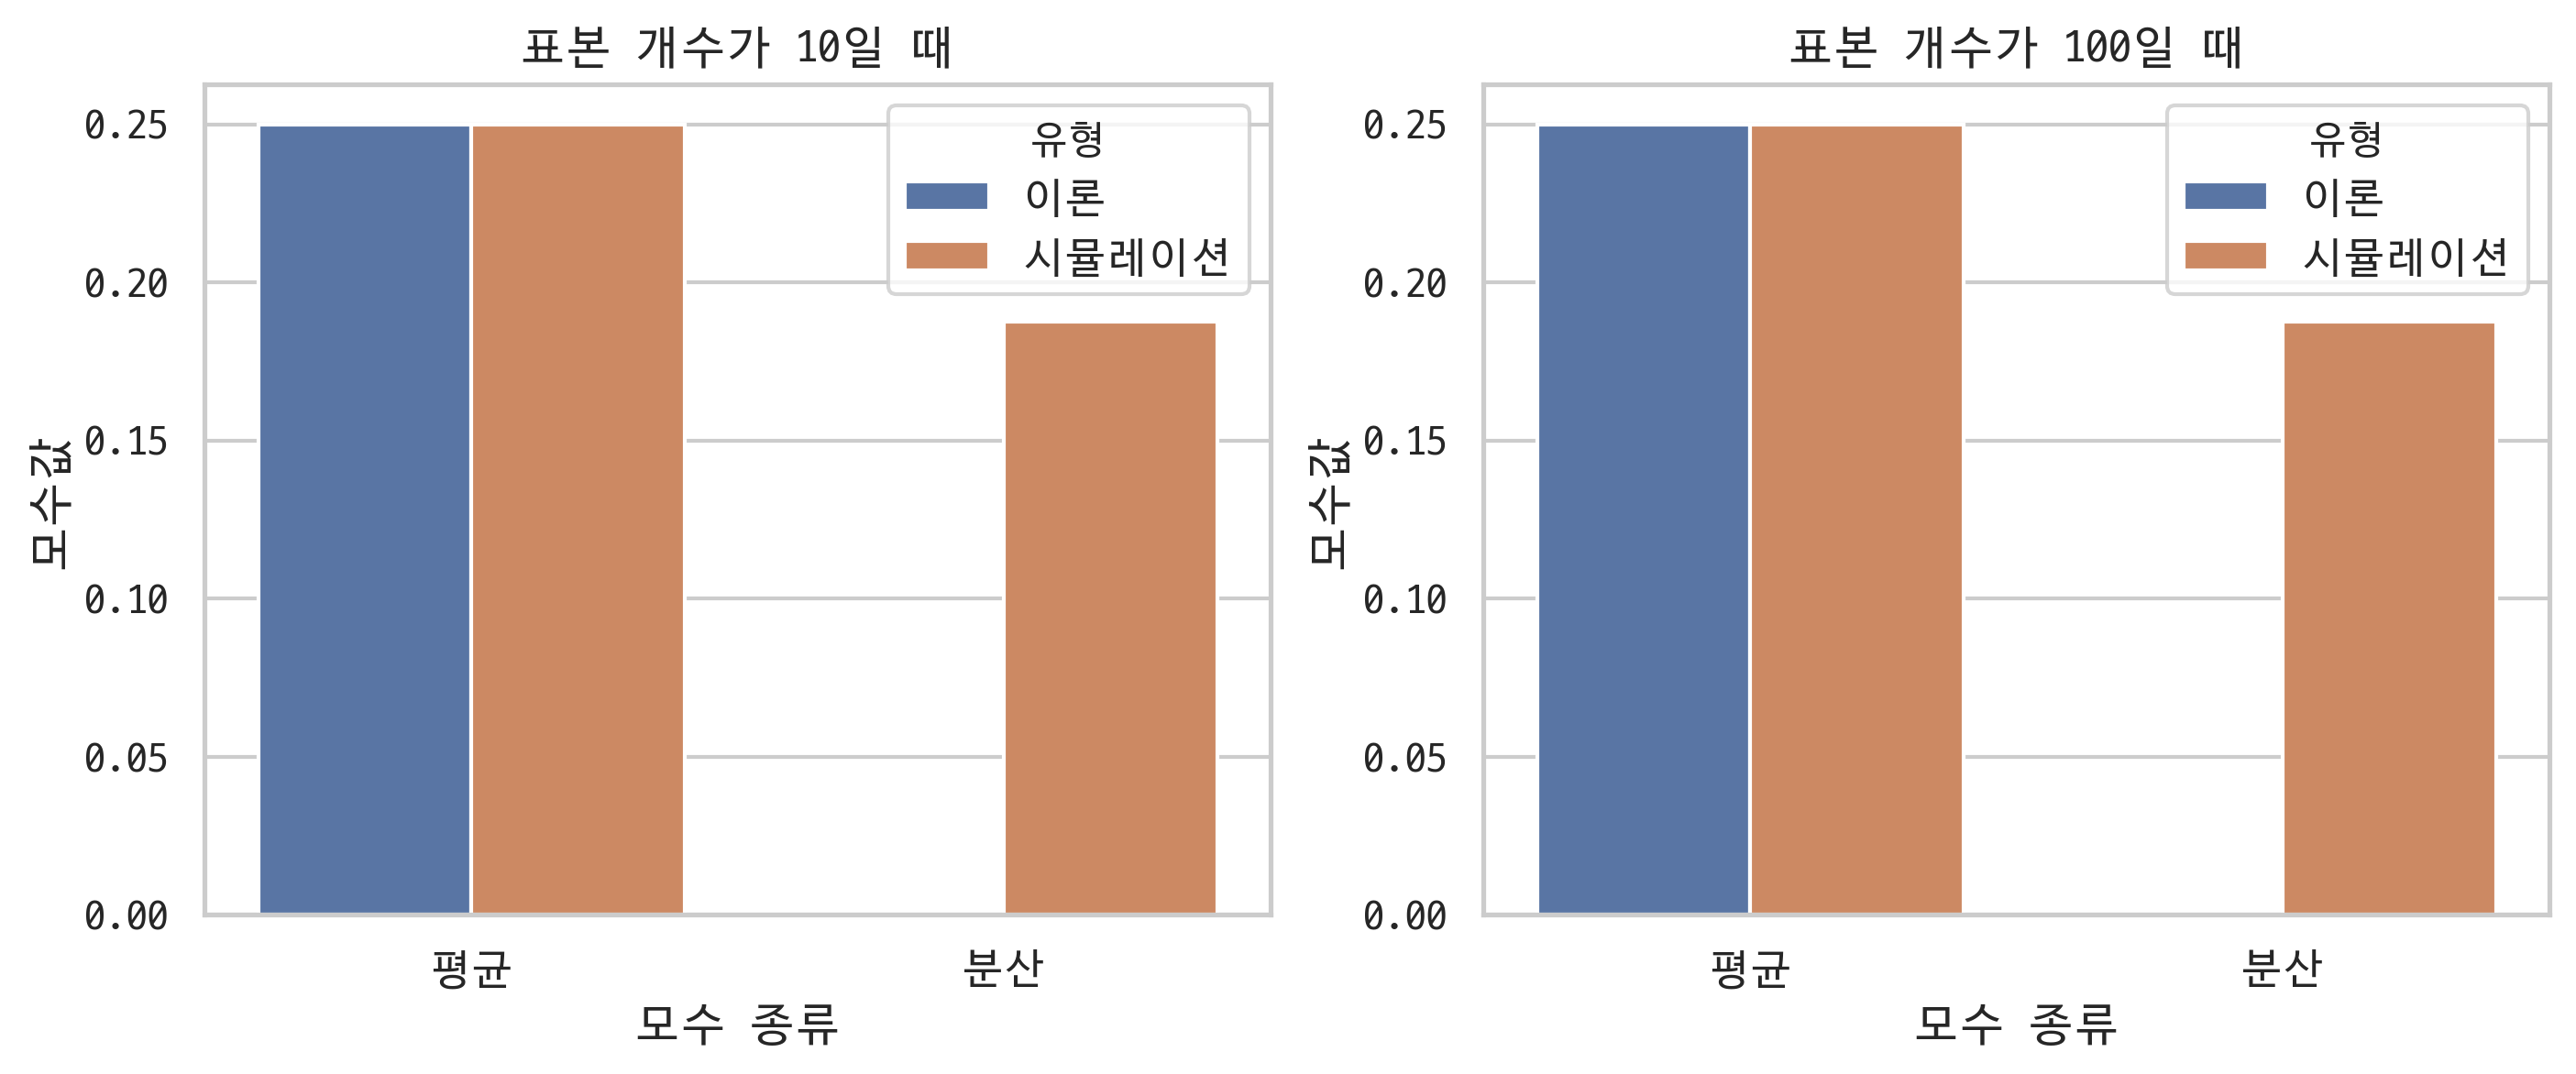

In [58]:
plt.figure(figsize=(11, 4))

plt.subplot(121)
sns.barplot(x='모수 종류', y='모수값', hue='유형', data=df1)
plt.title('표본 개수가 10일 때')
plt.subplot(122)
sns.barplot(x='모수 종류', y='모수값', hue='유형', data=df2)
plt.title('표본 개수가 100일 때')
plt.show()

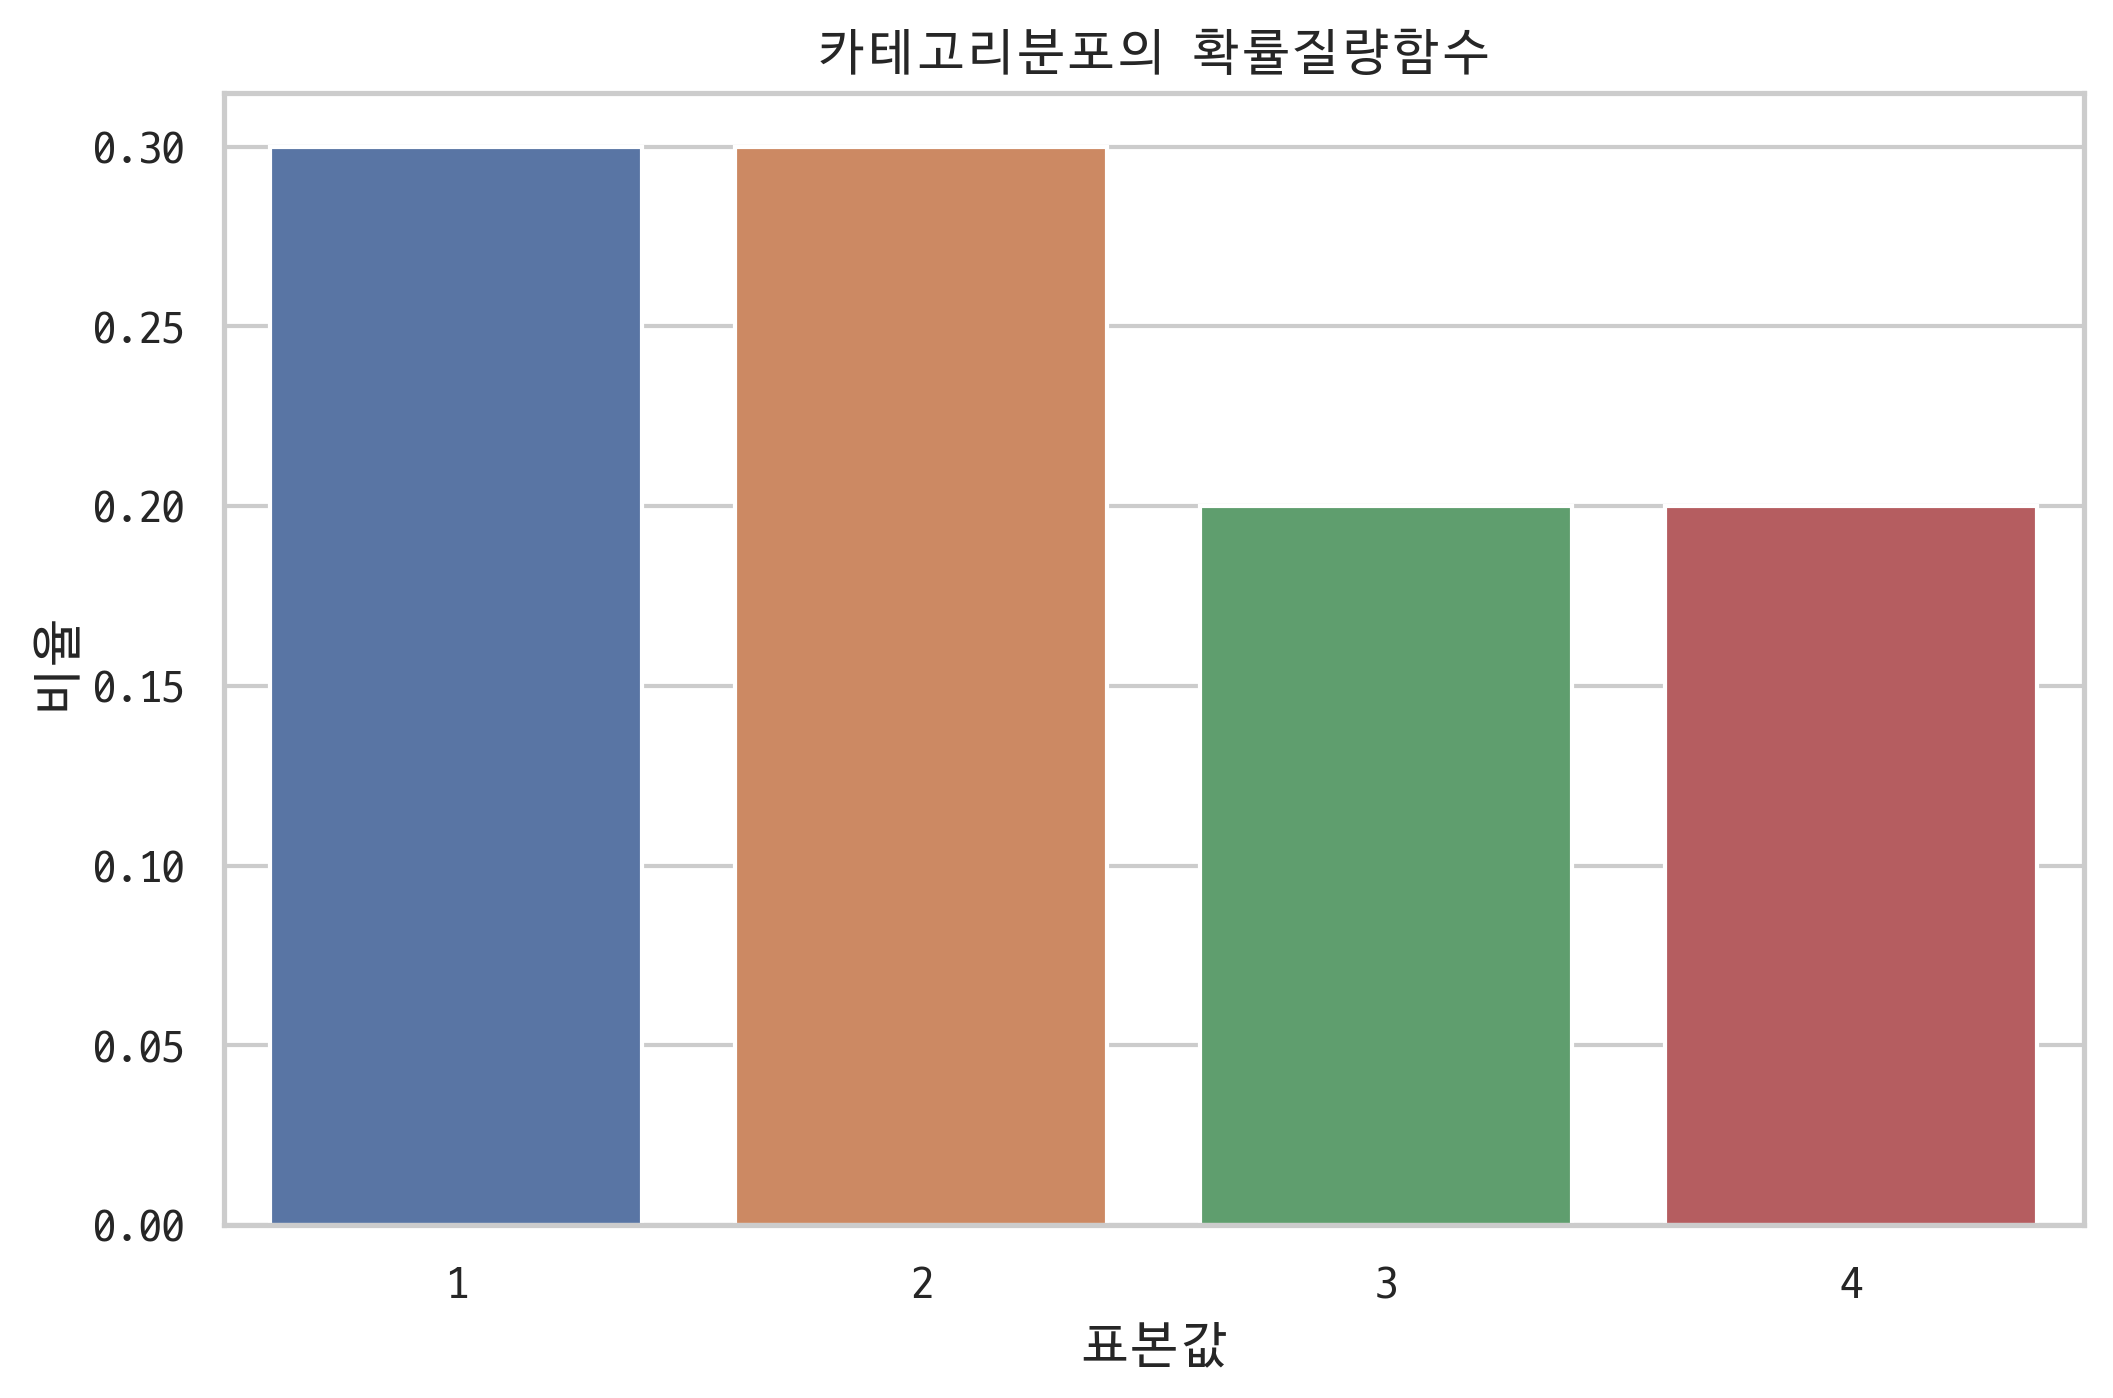

In [68]:
# (2)의 경우
mu = [0.3, 0.3, 0.2, 0.2]
rv = sp.stats.multinomial(1, mu)
xx = np.arange(1, len(mu) + 1)
xx_ohe = pd.get_dummies(xx)

sns.barplot(xx, rv.pmf(xx_ohe.values))
plt.title('카테고리분포의 확률질량함수')
plt.xlabel('표본값')
plt.ylabel('비율')
plt.show()

In [69]:
x = rv.rvs(10)
print(np.mean(x), np.var(x))

0.25 0.1875


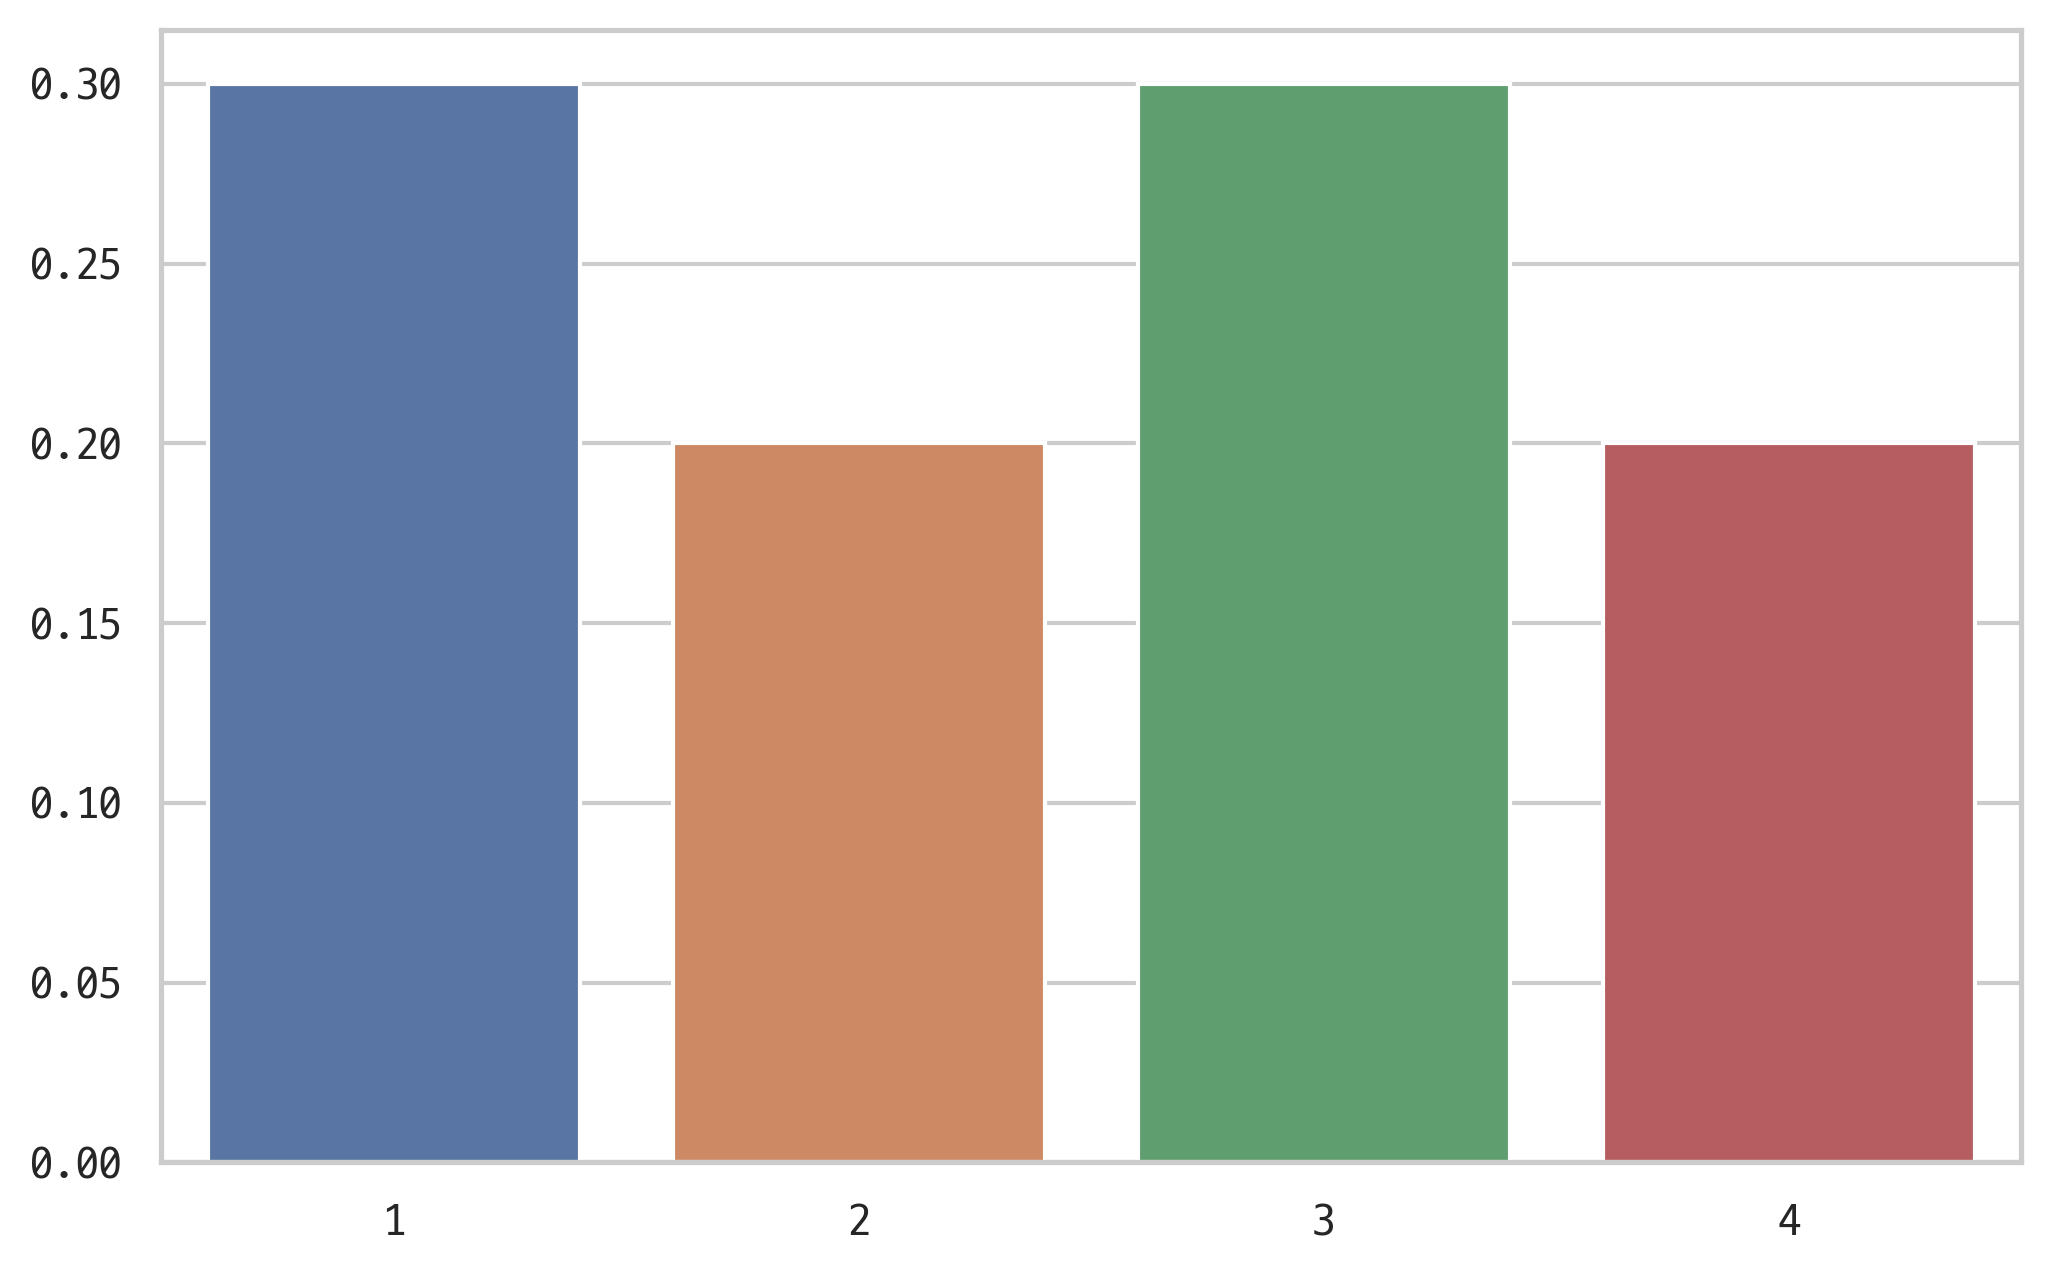

In [85]:
y = x.sum(axis=0) / len(x)
# plt.bar(np.arange(1, len(mu)+1), y)
sns.barplot(np.arange(1, len(mu)+1), y)
plt.show()

In [89]:
df = pd.DataFrame({'이론': rv.pmf(xx_ohe.values), '시뮬레이션': y}, index=np.arange(1, len(mu)+1))
df = df.stack().reset_index()
df.columns = ['표본값', '유형', '비율']
df.pivot('표본값', '유형', '비율')

유형,시뮬레이션,이론
표본값,,
1,0.3,0.3
2,0.2,0.3
3,0.3,0.2
4,0.2,0.2


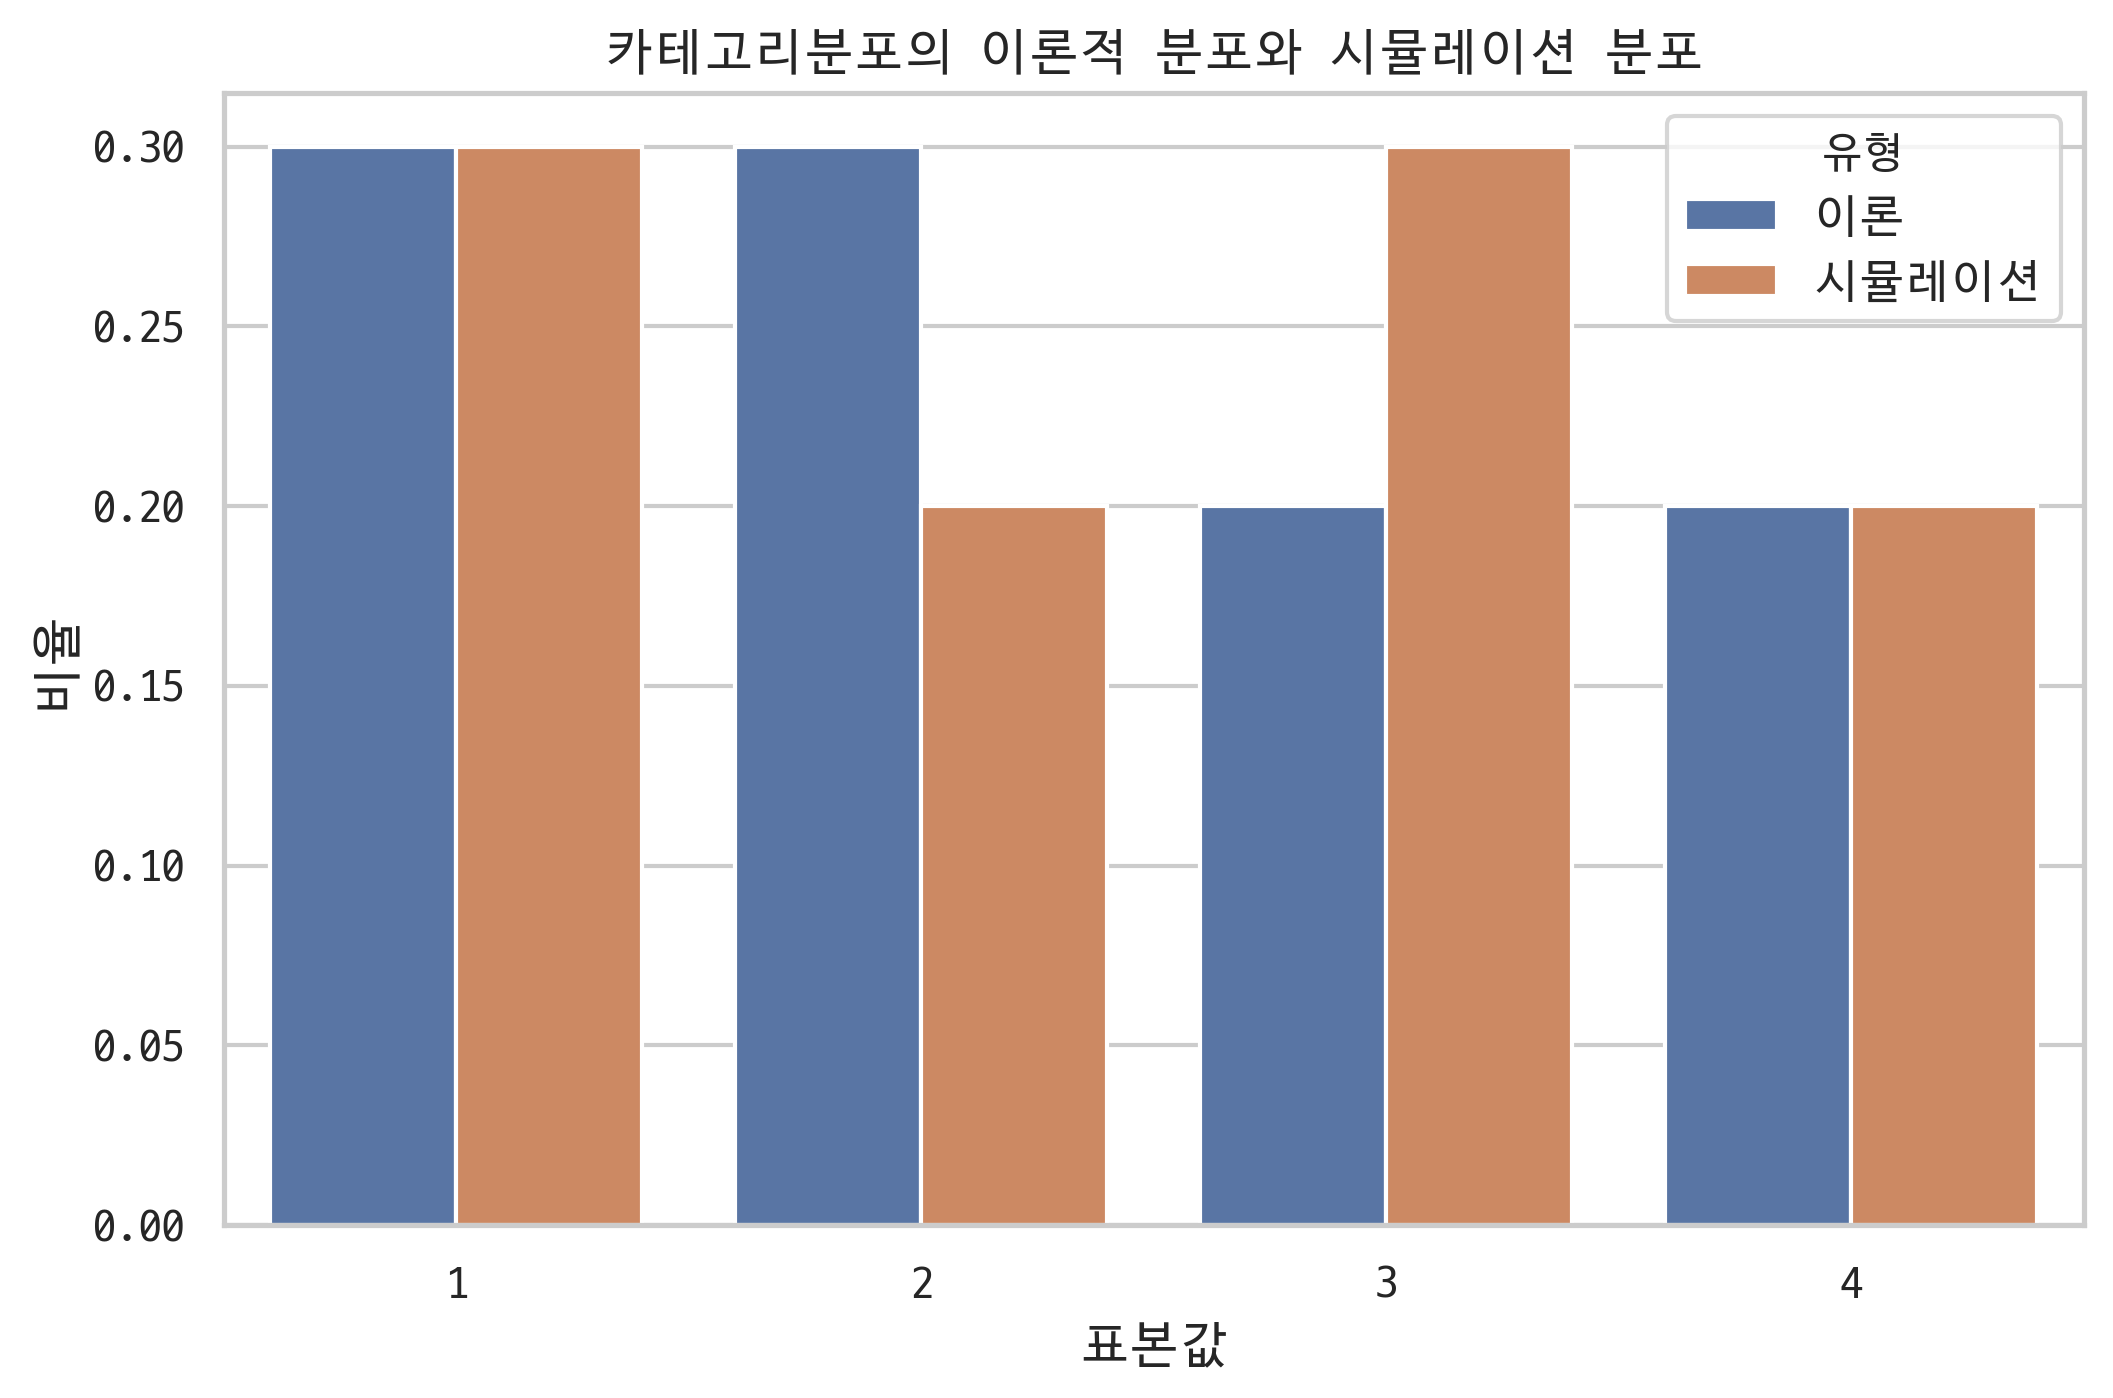

In [90]:
sns.barplot(x='표본값', y='비율', hue='유형', data=df)
plt.title('카테고리분포의 이론적 분포와 시뮬레이션 분포')
plt.show()

### 다항분포

In [6]:
from sklearn.datasets import load_iris

In [7]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [8]:
dir(iris)

['DESCR', 'data', 'feature_names', 'filename', 'target', 'target_names']

In [10]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [9]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [11]:
iris.filename

'/Users/sj/opt/anaconda3/lib/python3.7/site-packages/sklearn/datasets/data/iris.csv'

In [12]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [15]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [16]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

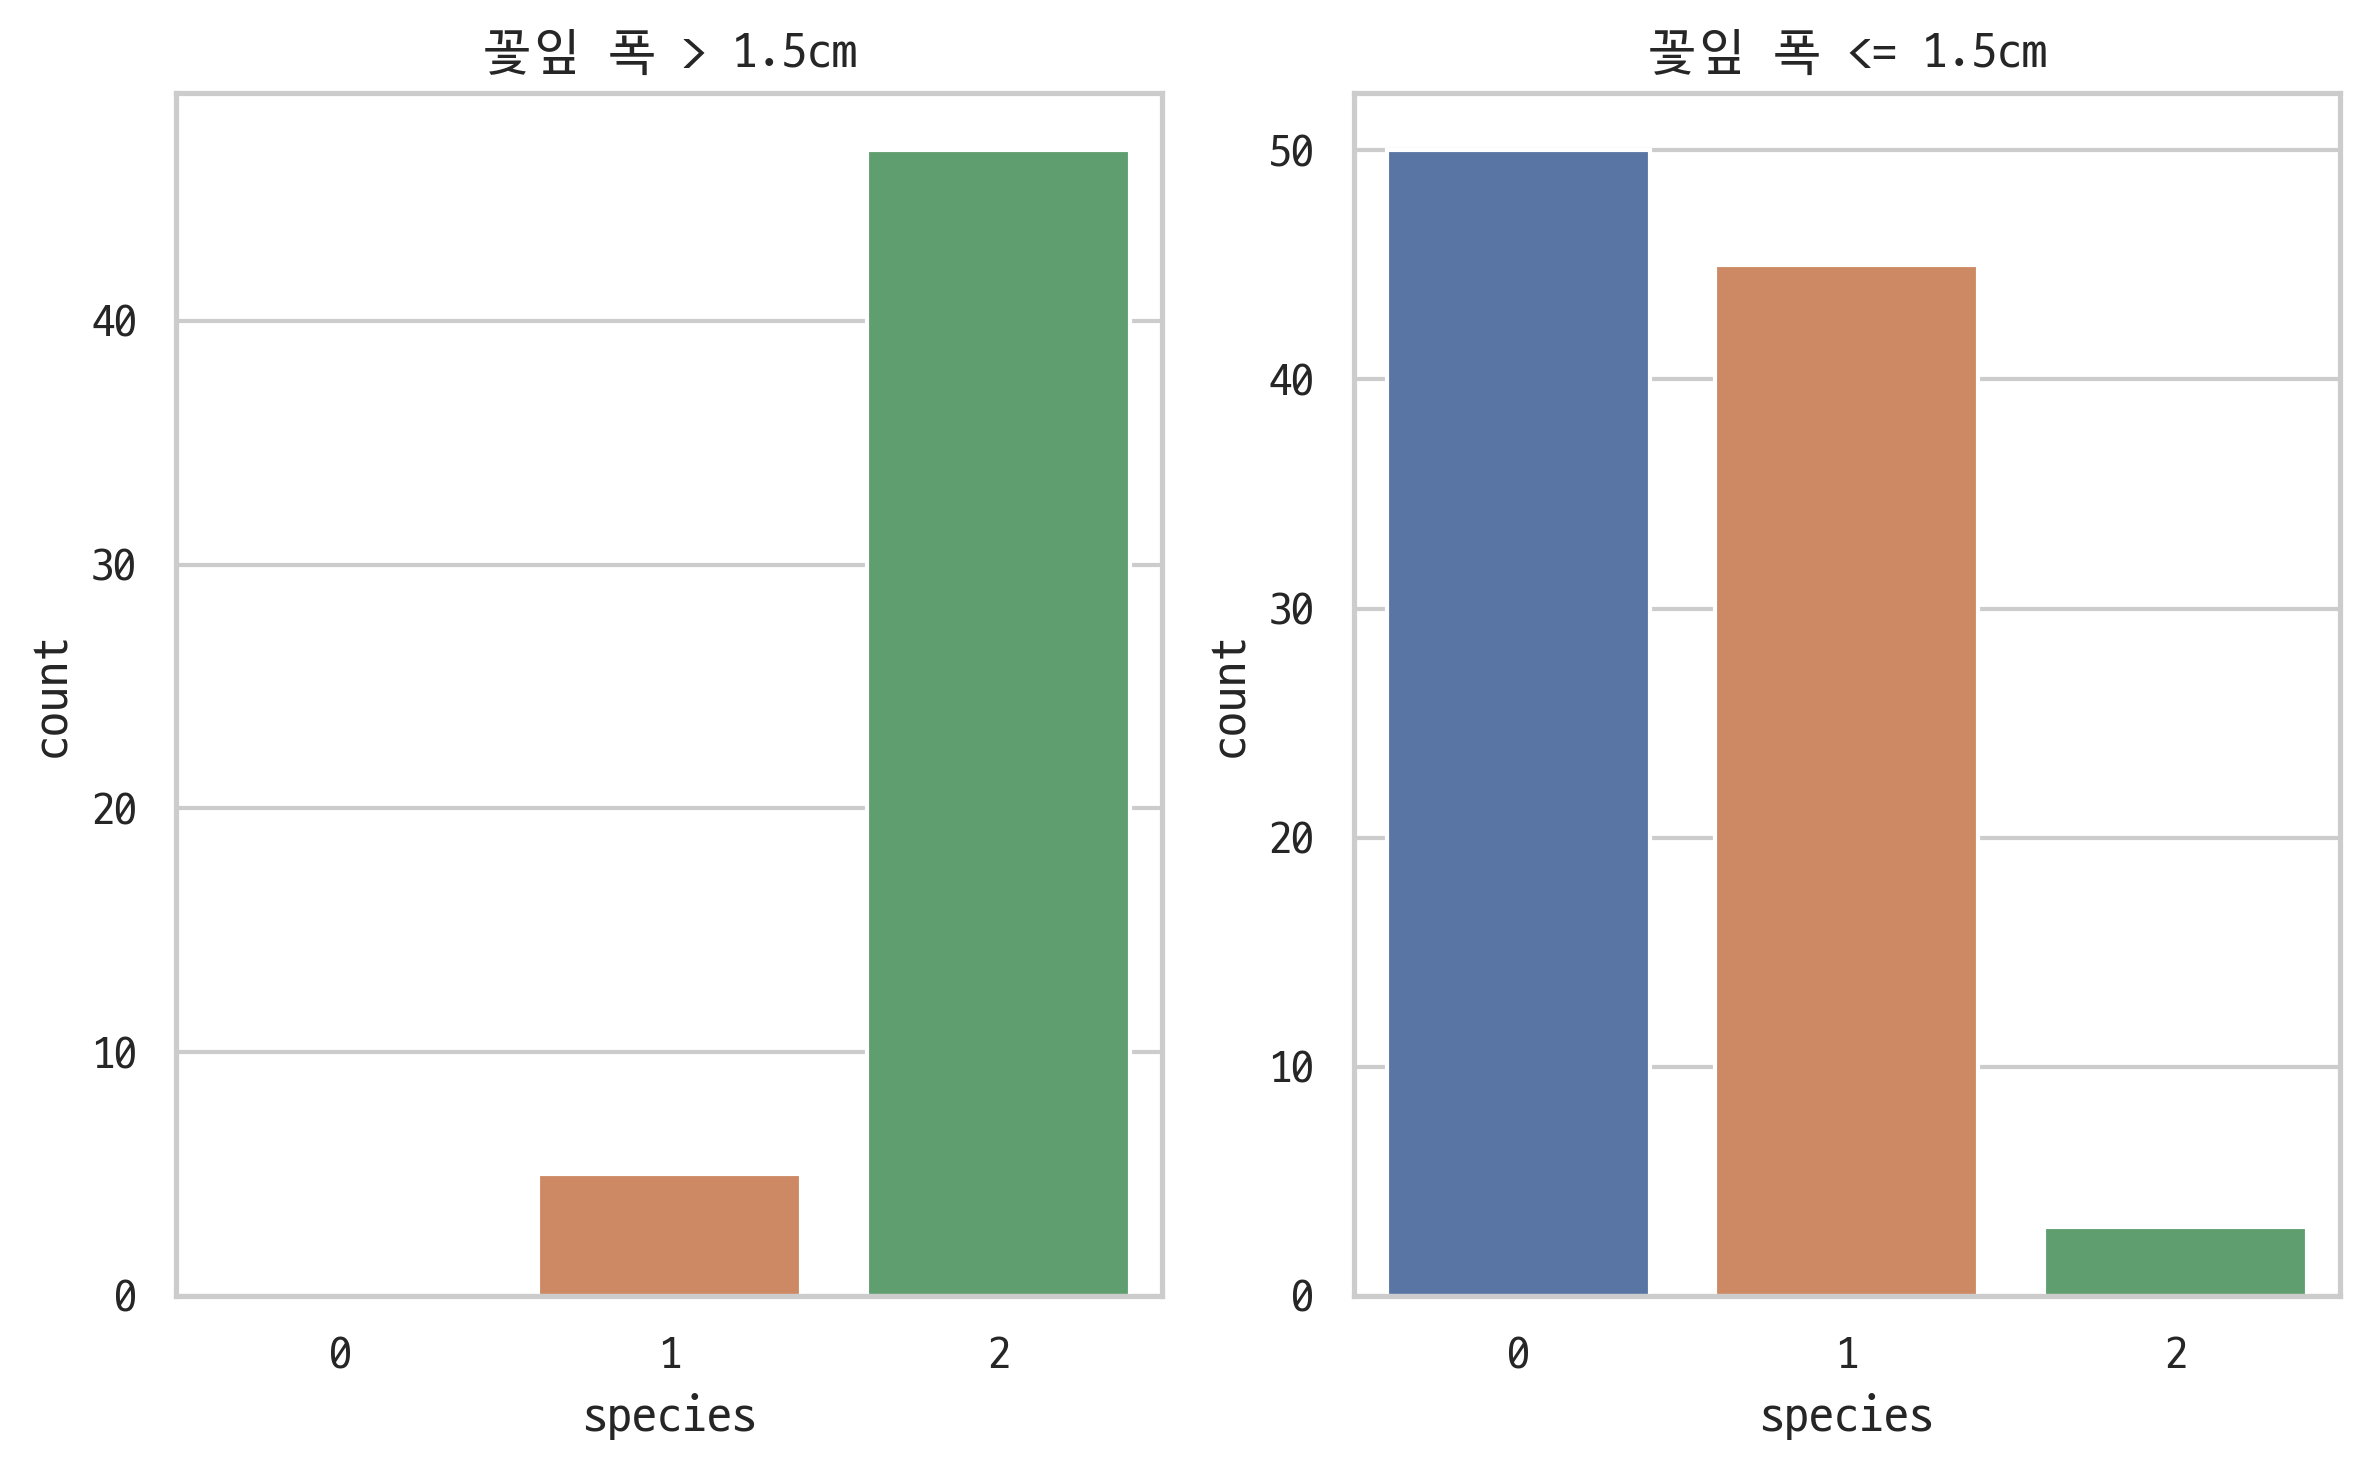

In [18]:
df["species"] = pd.Series(iris.target, dtype = 'category')
df1 = df[df["petal width (cm)"] > 1.5]
df2 = df[df['petal width (cm)'] <= 1.5]

fig, ax = plt.subplots(1, 2)
sns.countplot(x='species', data=df1, ax=ax[0]).set_title('꽃잎 폭 > 1.5cm')
sns.countplot(x='species', data=df2, ax=ax[1]).set_title('꽃잎 폭 <= 1.5cm')
plt.tight_layout()
plt.show()

### 다항분포

In [23]:
N = 30
mu = [0.1, 0.1, 0.1, 0.1, 0.3, 0.3]
rv = sp.stats.multinomial(N, mu)

np.random.seed(0)
X = rv.rvs(100)
X[:10]

array([[ 3,  4,  3,  3,  8,  9],
       [ 3,  3,  5,  6,  6,  7],
       [ 4,  3,  3,  5,  5, 10],
       [ 1,  0,  5,  5, 12,  7],
       [ 7,  4,  2,  3,  5,  9],
       [ 3,  1,  6,  3,  8,  9],
       [ 2,  4,  3,  3,  5, 13],
       [ 3,  3,  3,  6,  8,  7],
       [ 2,  3,  4,  1, 11,  9],
       [ 4,  2,  1,  2, 10, 11]])

In [31]:
df = pd.DataFrame(X).stack().reset_index()
df.tail()

,level_0,level_1,0
595,99,1,3
596,99,2,3
597,99,3,2
598,99,4,10
599,99,5,10


In [29]:
df2 = pd.DataFrame(X).reset_index()
df2.tail()

,index,0,1,2,3,4,5
95,95,4,4,6,6,5,5
96,96,1,2,2,3,8,14
97,97,3,2,5,6,7,7
98,98,2,3,5,2,9,9
99,99,2,3,3,2,10,10


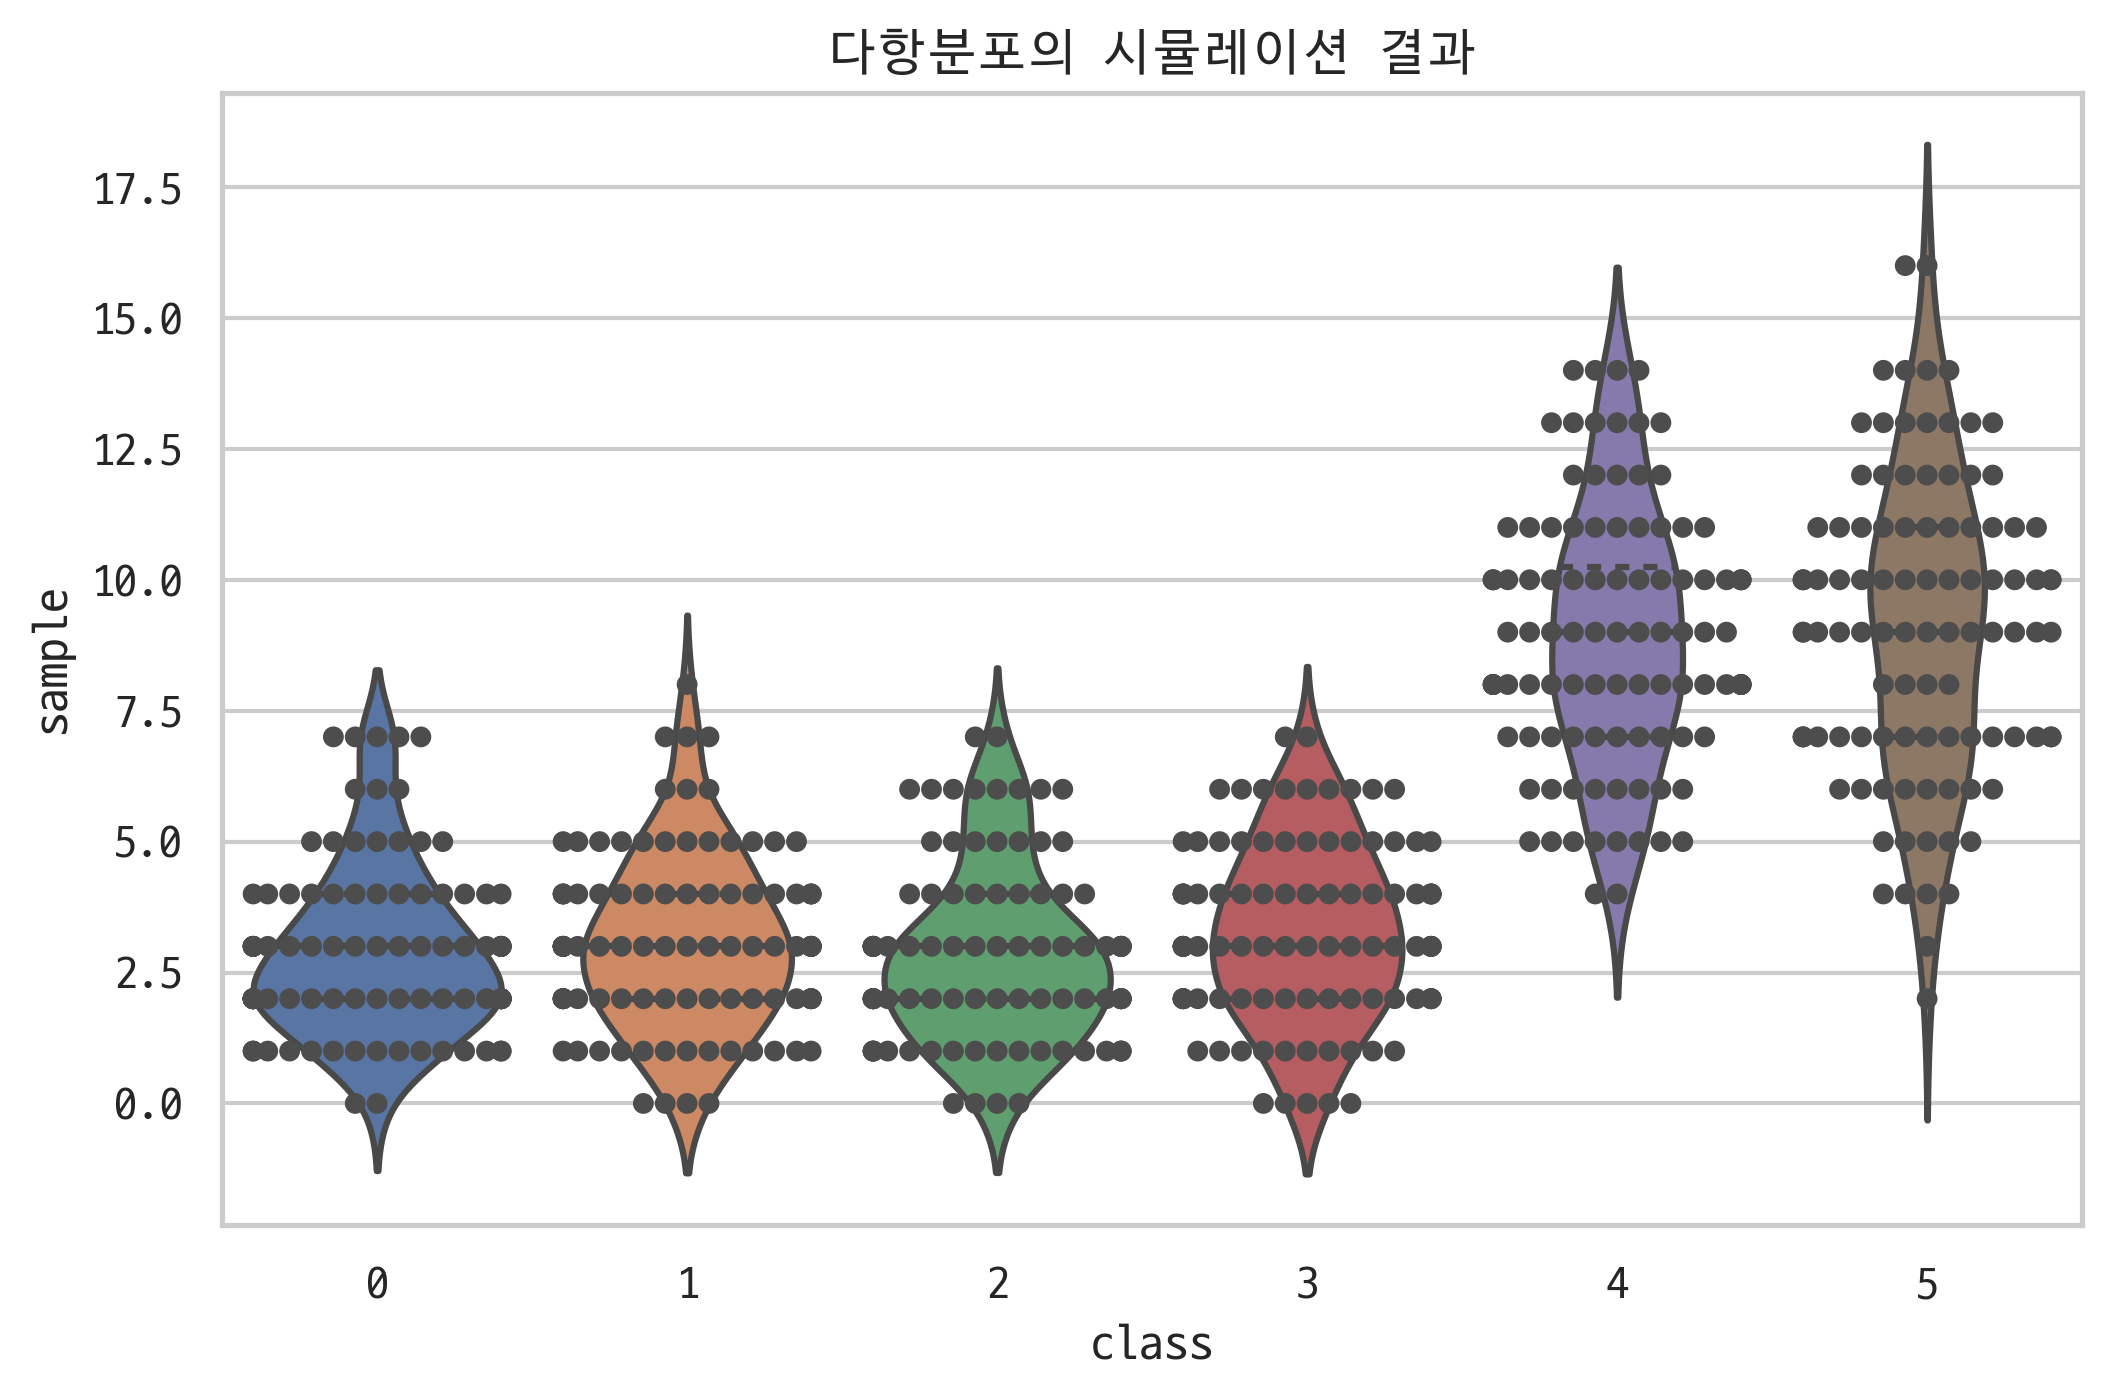

In [33]:
df.columns = ['trial', 'class', 'sample']
sns.violinplot(x='class', y='sample', data=df, inner='quartile')
sns.swarmplot(x='class', y='sample', data=df, color=".3")
plt.title('다항분포의 시뮬레이션 결과')
plt.show()

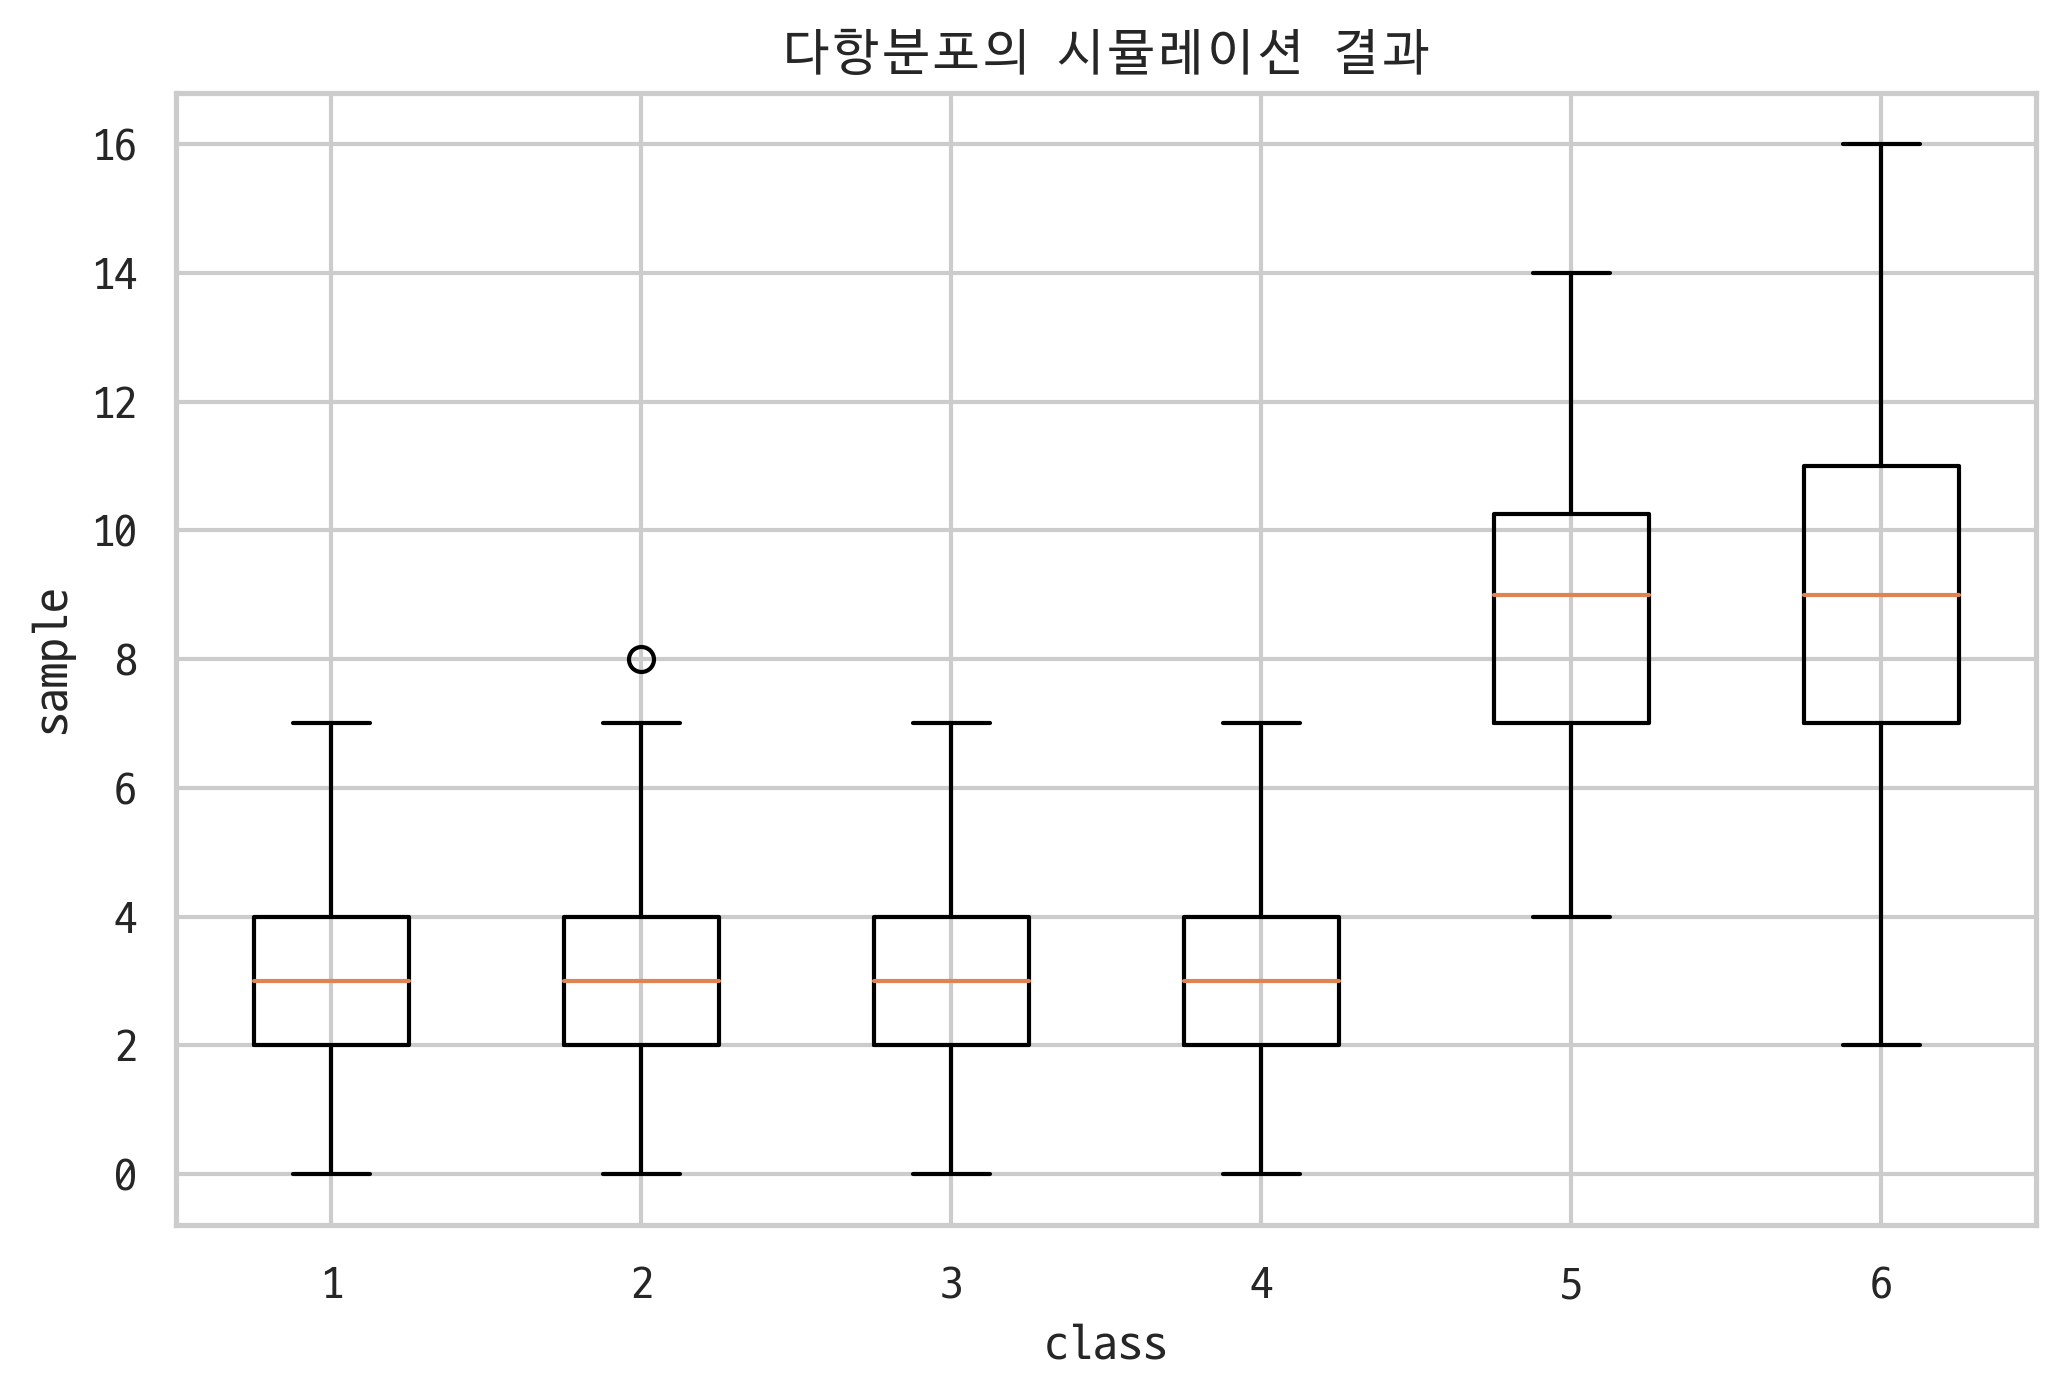

In [34]:
plt.boxplot(X)
plt.title('다항분포의 시뮬레이션 결과')
plt.xlabel('class')
plt.ylabel('sample')
plt.show()

# 4. 정규분포와 중심극한정리

### 사이파이를 사용한 정규분포의 시뮬레이션

In [92]:
mu = 0
std = 1
rv = sp.stats.norm(loc=mu, scale=std)

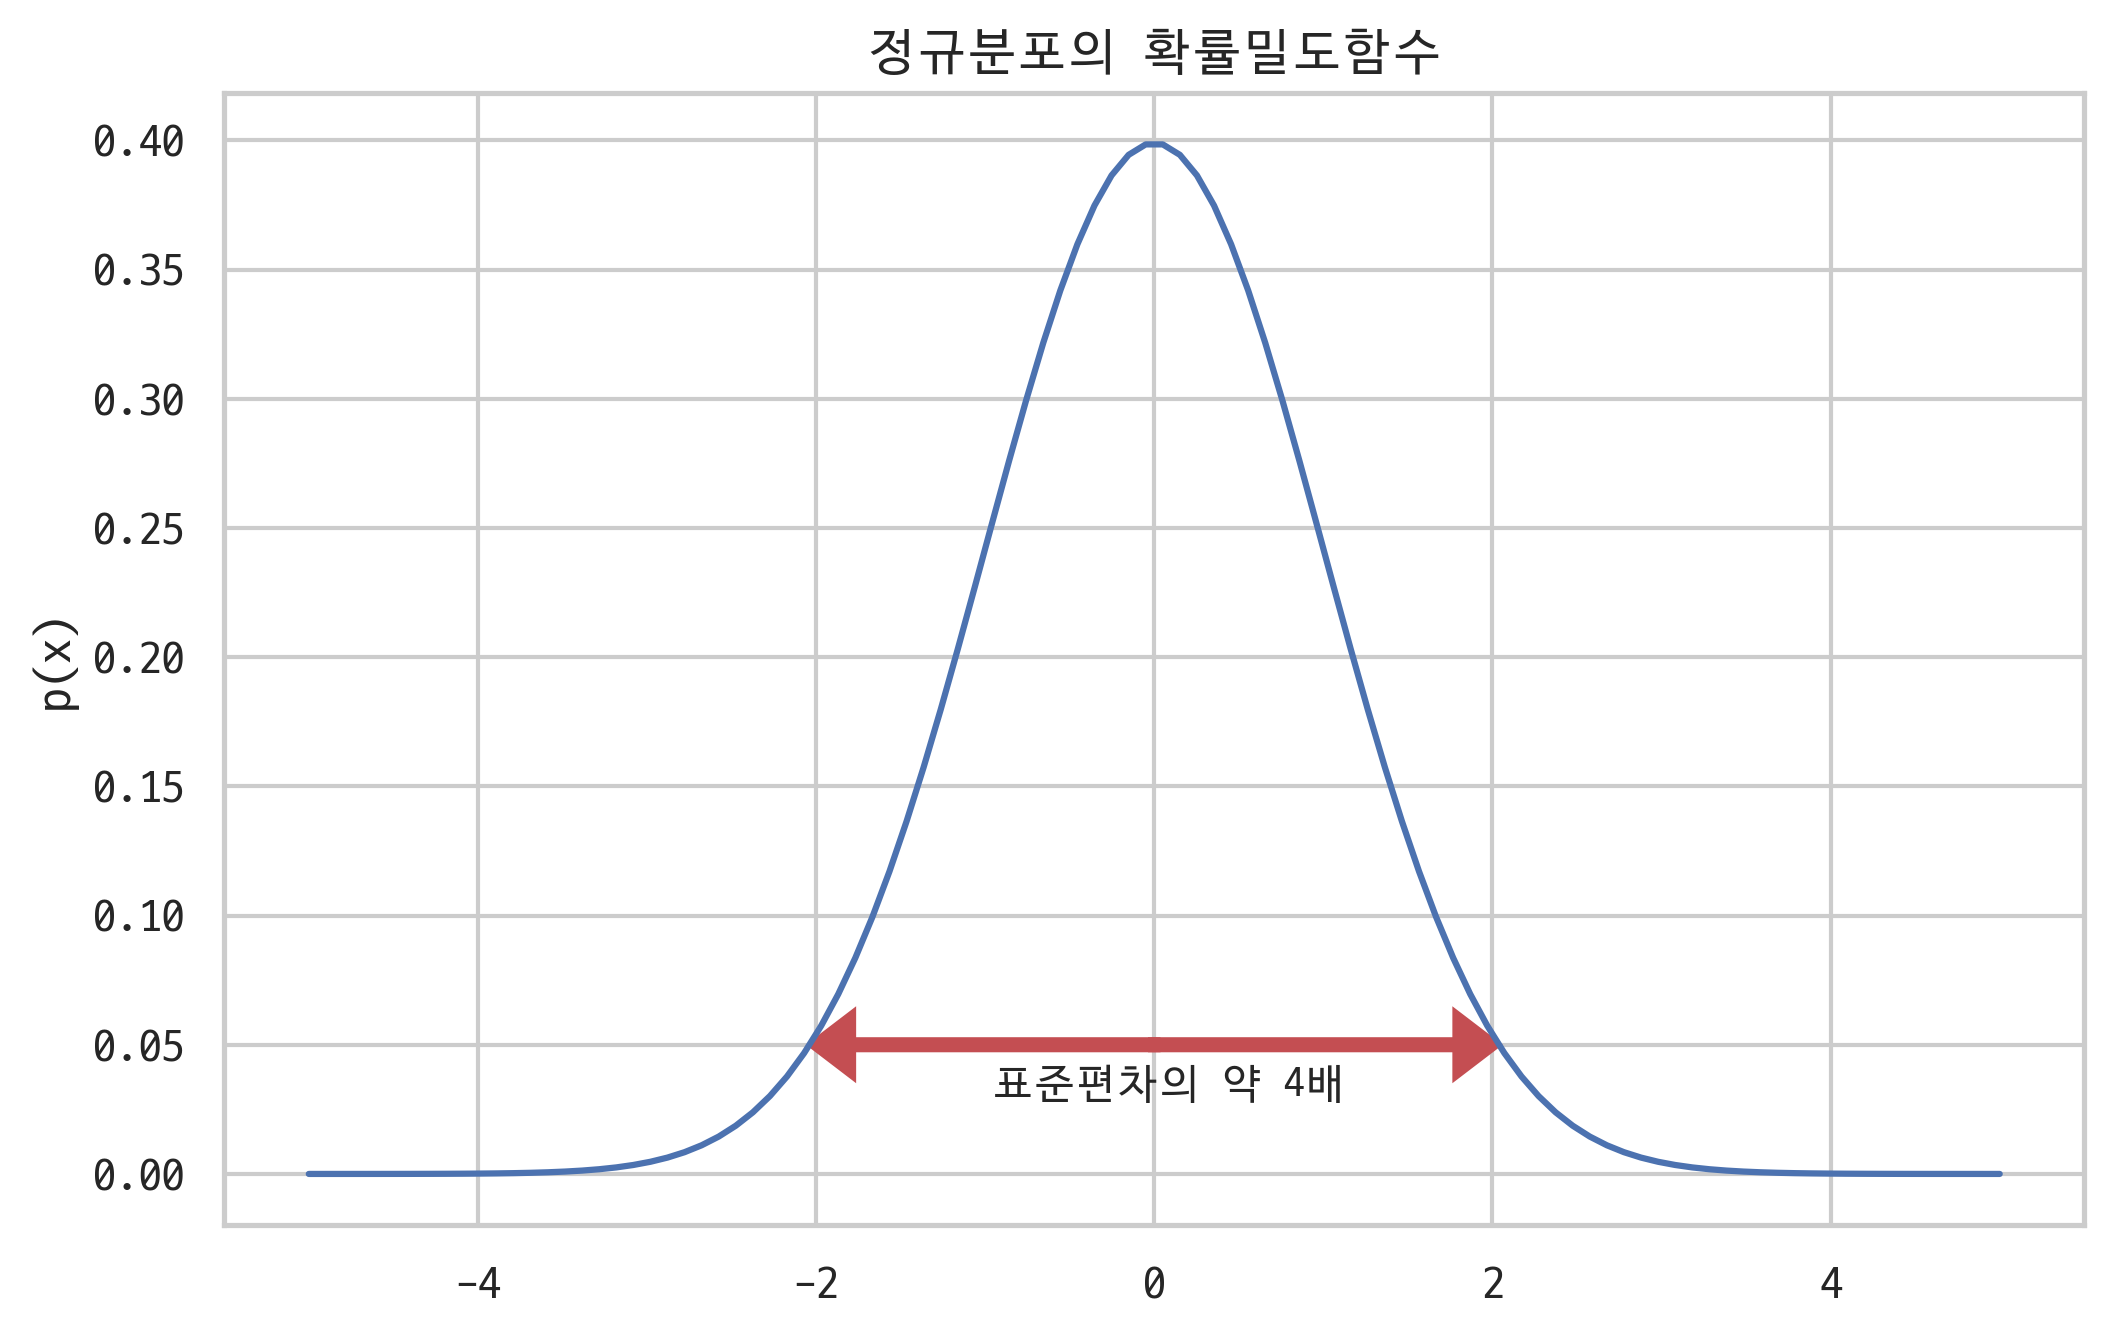

In [93]:
xx = np.linspace(-5, 5, 100)
plt.plot(xx, rv.pdf(xx)) #pdf 메서드를 사용하면, 확률밀도함수를 계산할 수 있다.
plt.arrow(0, 0.05, 2, 0, lw=3, color='r',
         head_width=0.02, head_length=0.2, length_includes_head=True)
plt.arrow(0, 0.05, -2, 0, lw=3, color='r',
         head_width=0.02, head_length=0.2, length_includes_head=True)
plt.text(-0.96, 0.03, '표준편차의 약 4배')
plt.ylabel("p(x)")
plt.title('정규분포의 확률밀도함수')
plt.show()

In [94]:
np.random.seed(0)
x = rv.rvs(20)
x

array([ 1.76405235,  0.40015721,  0.97873798,  2.2408932 ,  1.86755799,
       -0.97727788,  0.95008842, -0.15135721, -0.10321885,  0.4105985 ,
        0.14404357,  1.45427351,  0.76103773,  0.12167502,  0.44386323,
        0.33367433,  1.49407907, -0.20515826,  0.3130677 , -0.85409574])

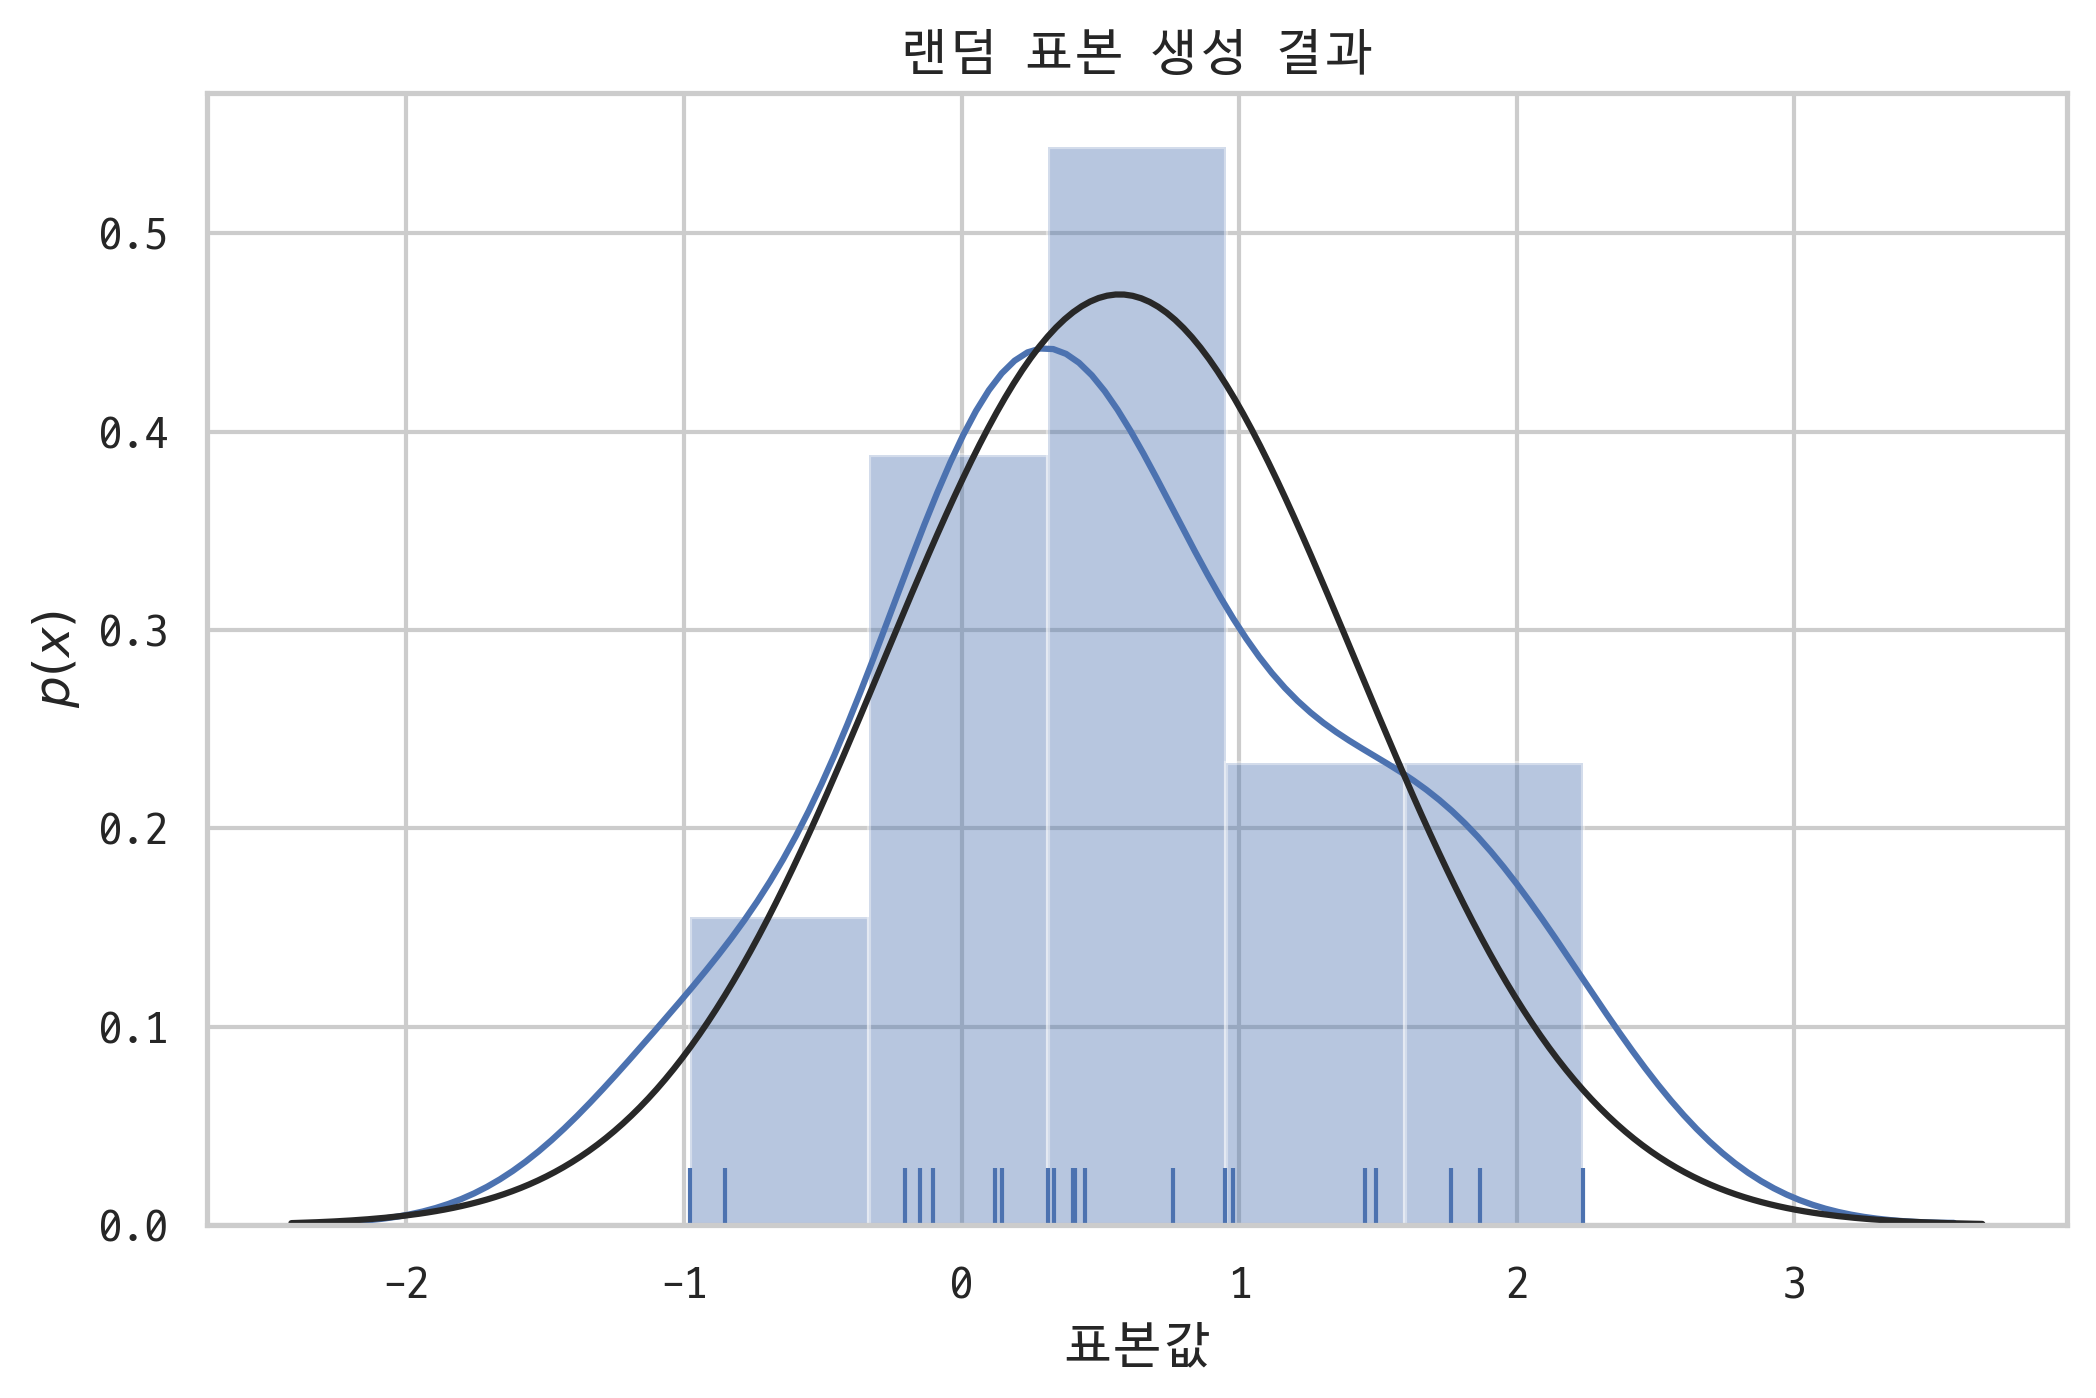

In [102]:
sns.distplot(x, rug=True, kde=True, fit=sp.stats.norm)
plt.title('랜덤 표본 생성 결과')
plt.xlabel('표본값')
plt.ylabel('$p(x)$')
plt.show()

(array([2., 5., 7., 3., 3.]),
 array([-0.97727788, -0.33364366,  0.30999055,  0.95362477,  1.59725898,
         2.2408932 ]),
 <a list of 5 Patch objects>)

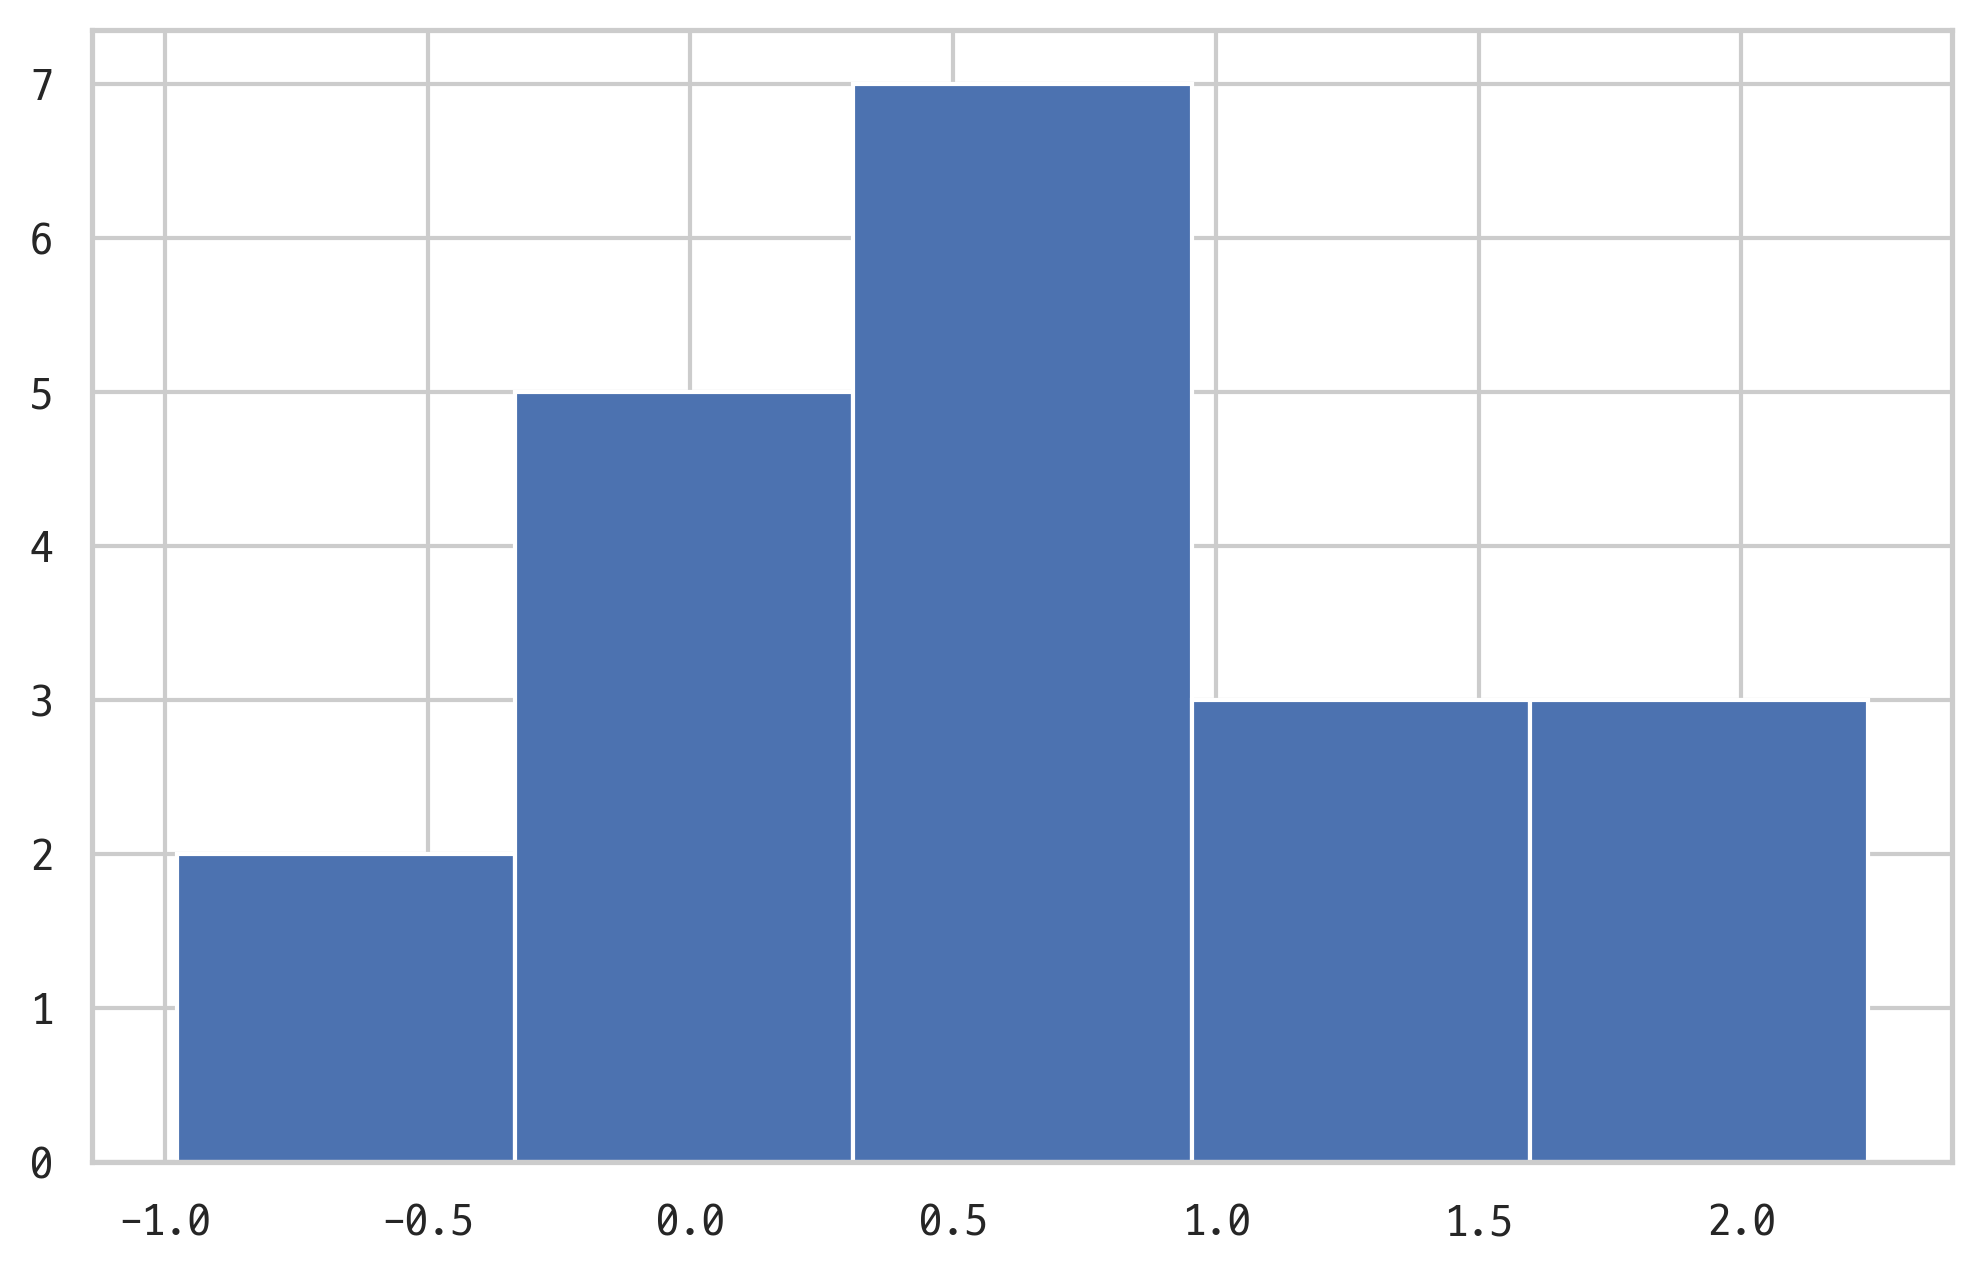

In [101]:
plt.hist(x, bins=5)

In [97]:
print(sns.distplot.__doc__)

Flexibly plot a univariate distribution of observations.

    This function combines the matplotlib ``hist`` function (with automatic
    calculation of a good default bin size) with the seaborn :func:`kdeplot`
    and :func:`rugplot` functions. It can also fit ``scipy.stats``
    distributions and plot the estimated PDF over the data.

    Parameters
    ----------

    a : Series, 1d-array, or list.
        Observed data. If this is a Series object with a ``name`` attribute,
        the name will be used to label the data axis.
    bins : argument for matplotlib hist(), or None, optional
        Specification of hist bins, or None to use Freedman-Diaconis rule.
    hist : bool, optional
        Whether to plot a (normed) histogram.
    kde : bool, optional
        Whether to plot a gaussian kernel density estimate.
    rug : bool, optional
        Whether to draw a rugplot on the support axis.
    fit : random variable object, optional
        An object with `fit` method, returning a

#### 예제: 붓꽃 데이터

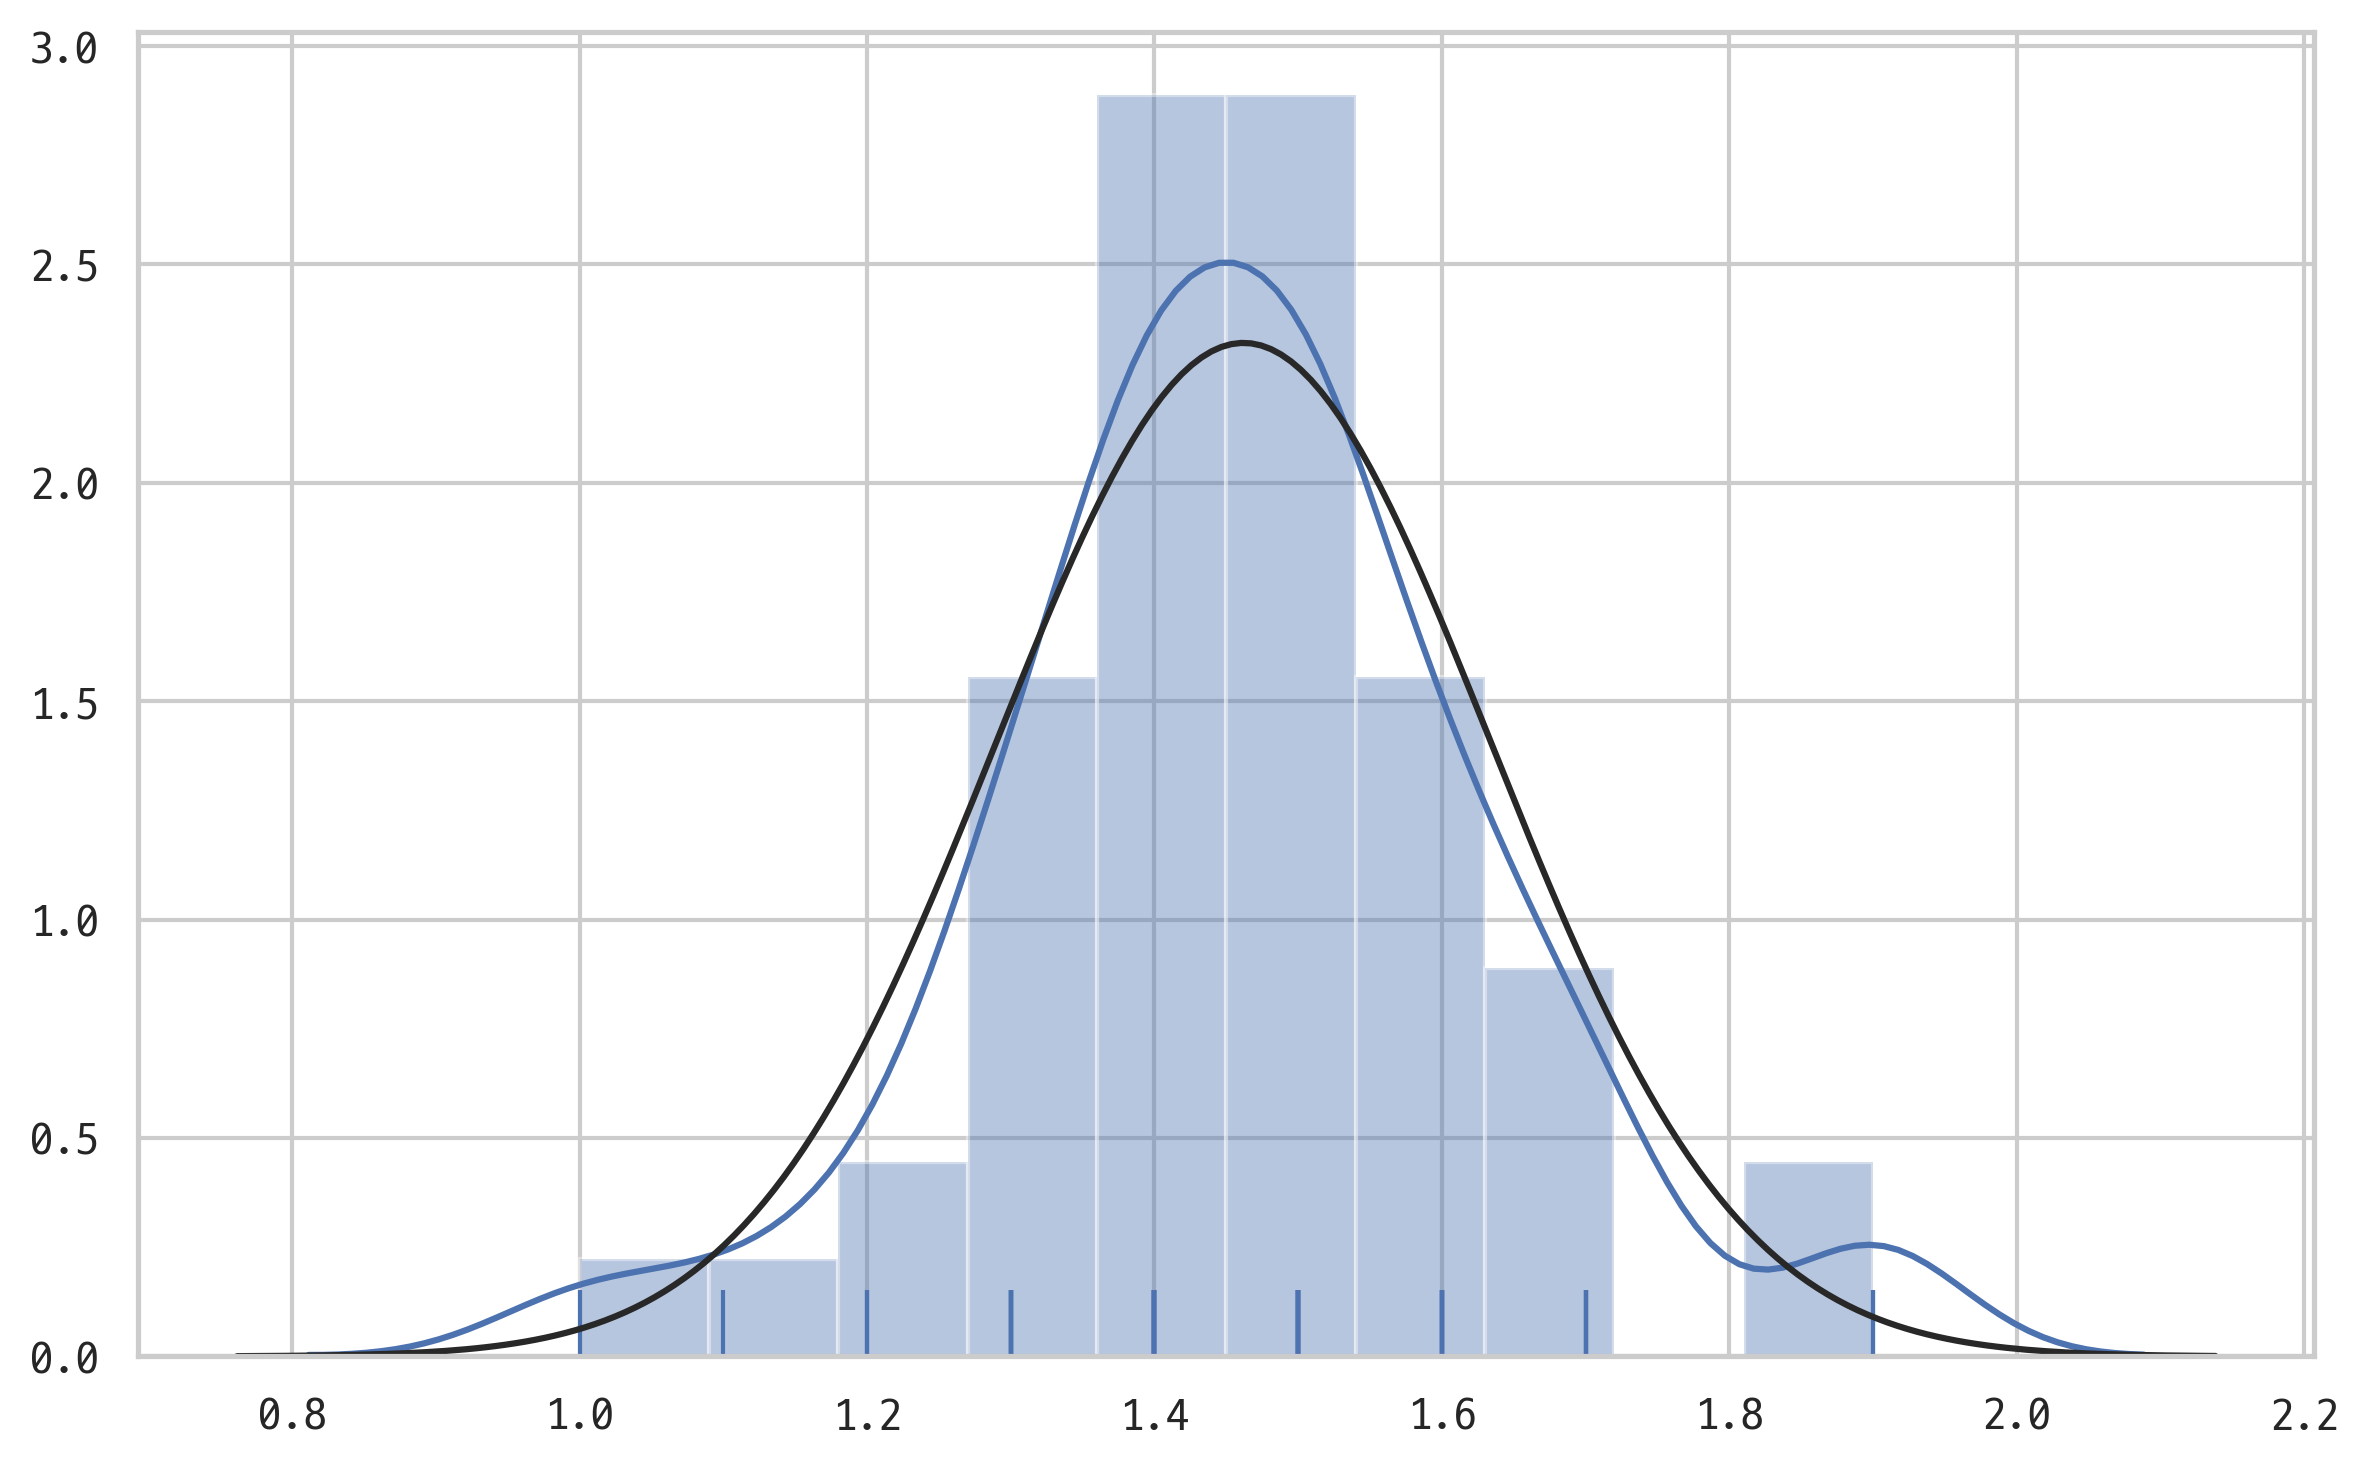

In [103]:
from sklearn.datasets import load_iris

setosa_sepal_length = load_iris().data[:50, 2]
sns.distplot(setosa_sepal_length, rug=True, fit=sp.stats.norm)
plt.tight_layout()
plt.show()

#### 연습문제 8.4.1
주변에서 얻을 수 있는 실수값 데이터 중 정규분포 모양을 띄는 데이터를 구하여 히스토그램을 그려라.

### 로그정규분포

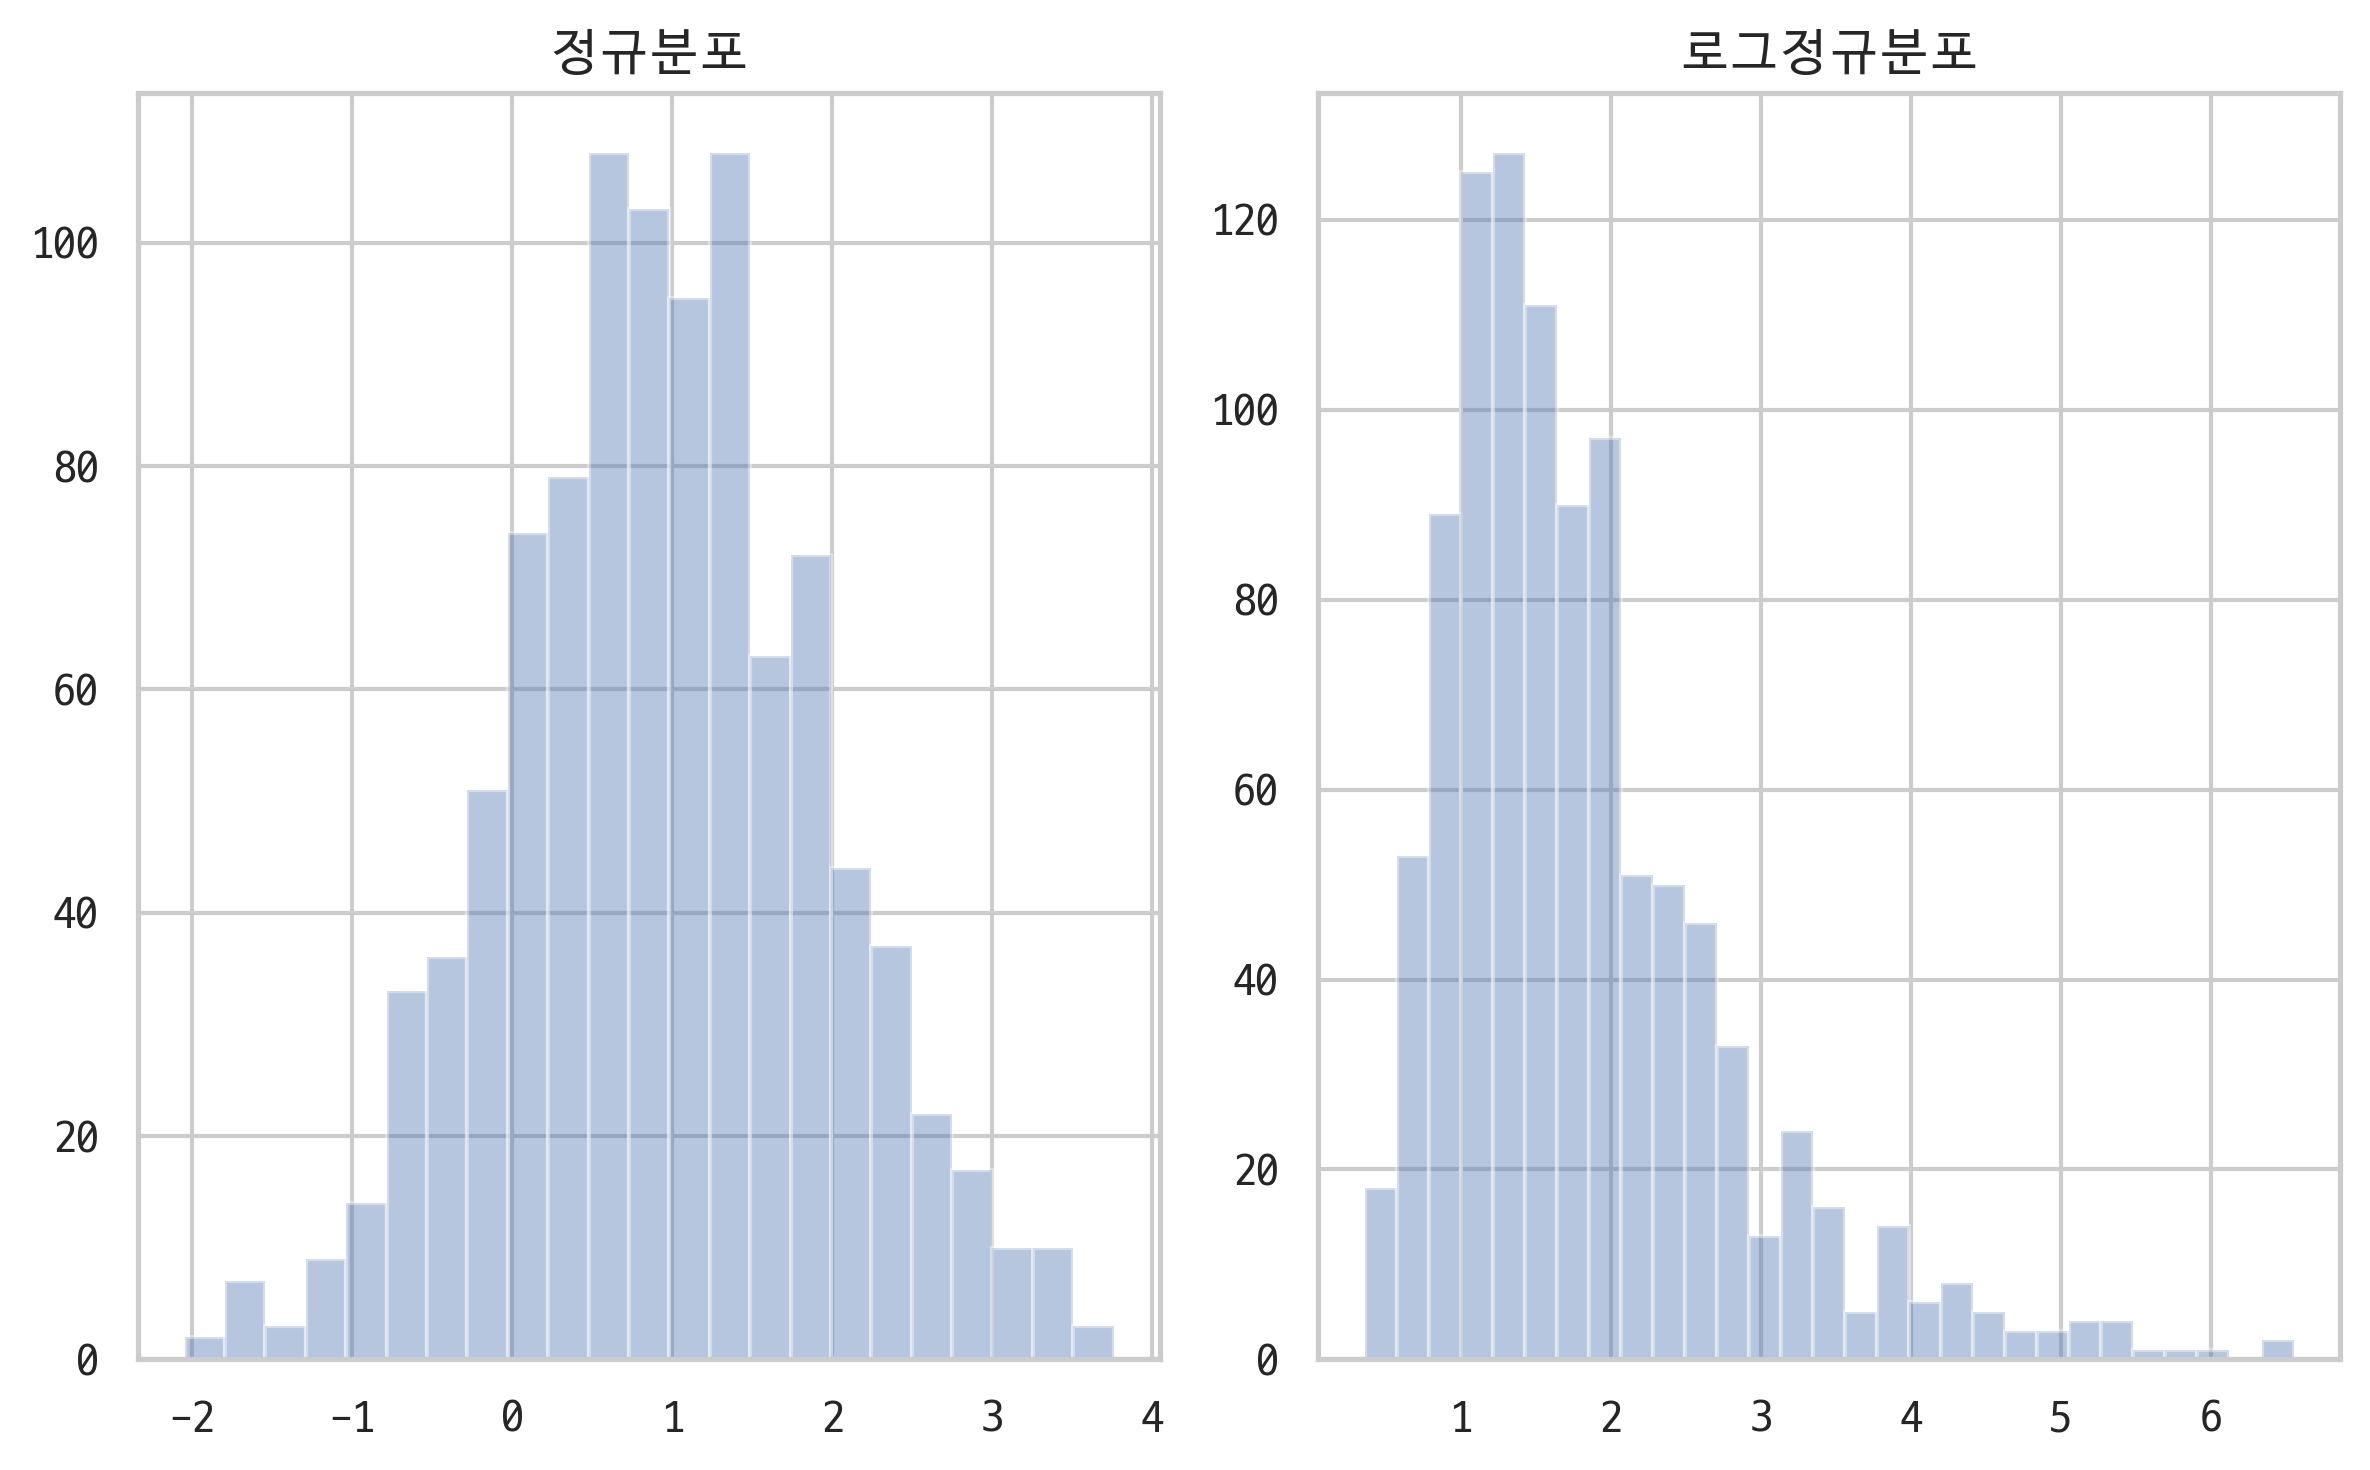

In [106]:
np.random.seed(0)
mu = 1
rv = sp.stats.norm(loc=mu)
x1 = rv.rvs(1000)
s = 0.5
x2 = np.exp(s * x1)

fig, ax = plt.subplots(1, 2)
sns.distplot(x1, kde=False, ax=ax[0])
ax[0].set_title('정규분포')
sns.distplot(x2, kde=False, ax=ax[1])
ax[1].set_title('로그정규분포')
plt.tight_layout()
plt.show()

In [107]:
help(plt.tight_layout)

Help on function tight_layout in module matplotlib.pyplot:

tight_layout(pad=1.08, h_pad=None, w_pad=None, rect=None)
    Automatically adjust subplot parameters to give specified padding.
    
    Parameters
    ----------
    pad : float
        Padding between the figure edge and the edges of subplots,
        as a fraction of the font size.
    h_pad, w_pad : float, optional
        Padding (height/width) between edges of adjacent subplots,
        as a fraction of the font size.  Defaults to *pad*.
    rect : tuple (left, bottom, right, top), optional
        A rectangle (left, bottom, right, top) in the normalized
        figure coordinate that the whole subplots area (including
        labels) will fit into. Default is (0, 0, 1, 1).



### Q-Q plot

In [109]:
x_sorted = np.sort(sp.stats.norm(1).rvs(20))
x_sorted

array([-8.18077630e-01, -6.78688363e-01, -3.30348954e-04,  9.26998785e-02,
        2.09476978e-01,  5.77685176e-01,  9.50675930e-01,  1.09721923e+00,
        1.10471403e+00,  1.16155927e+00,  1.20147995e+00,  1.21496559e+00,
        1.22425222e+00,  1.22805333e+00,  1.23903360e+00,  1.54077359e+00,
        1.55596268e+00,  1.89247389e+00,  2.56340475e+00,  2.67398571e+00])

In [110]:
from scipy.stats.morestats import _calc_uniform_order_statistic_medians

position = _calc_uniform_order_statistic_medians(len(x))
position

array([0.03406367, 0.08261724, 0.13172109, 0.18082494, 0.2299288 ,
       0.27903265, 0.32813651, 0.37724036, 0.42634422, 0.47544807,
       0.52455193, 0.57365578, 0.62275964, 0.67186349, 0.72096735,
       0.7700712 , 0.81917506, 0.86827891, 0.91738276, 0.96593633])

In [111]:
qf = rv.ppf(position)
qf

array([-0.8241636 , -0.38768012, -0.11829229,  0.08777425,  0.26091865,
        0.4142824 ,  0.55493533,  0.68726332,  0.81431072,  0.93841854,
        1.06158146,  1.18568928,  1.31273668,  1.44506467,  1.5857176 ,
        1.73908135,  1.91222575,  2.11829229,  2.38768012,  2.8241636 ])

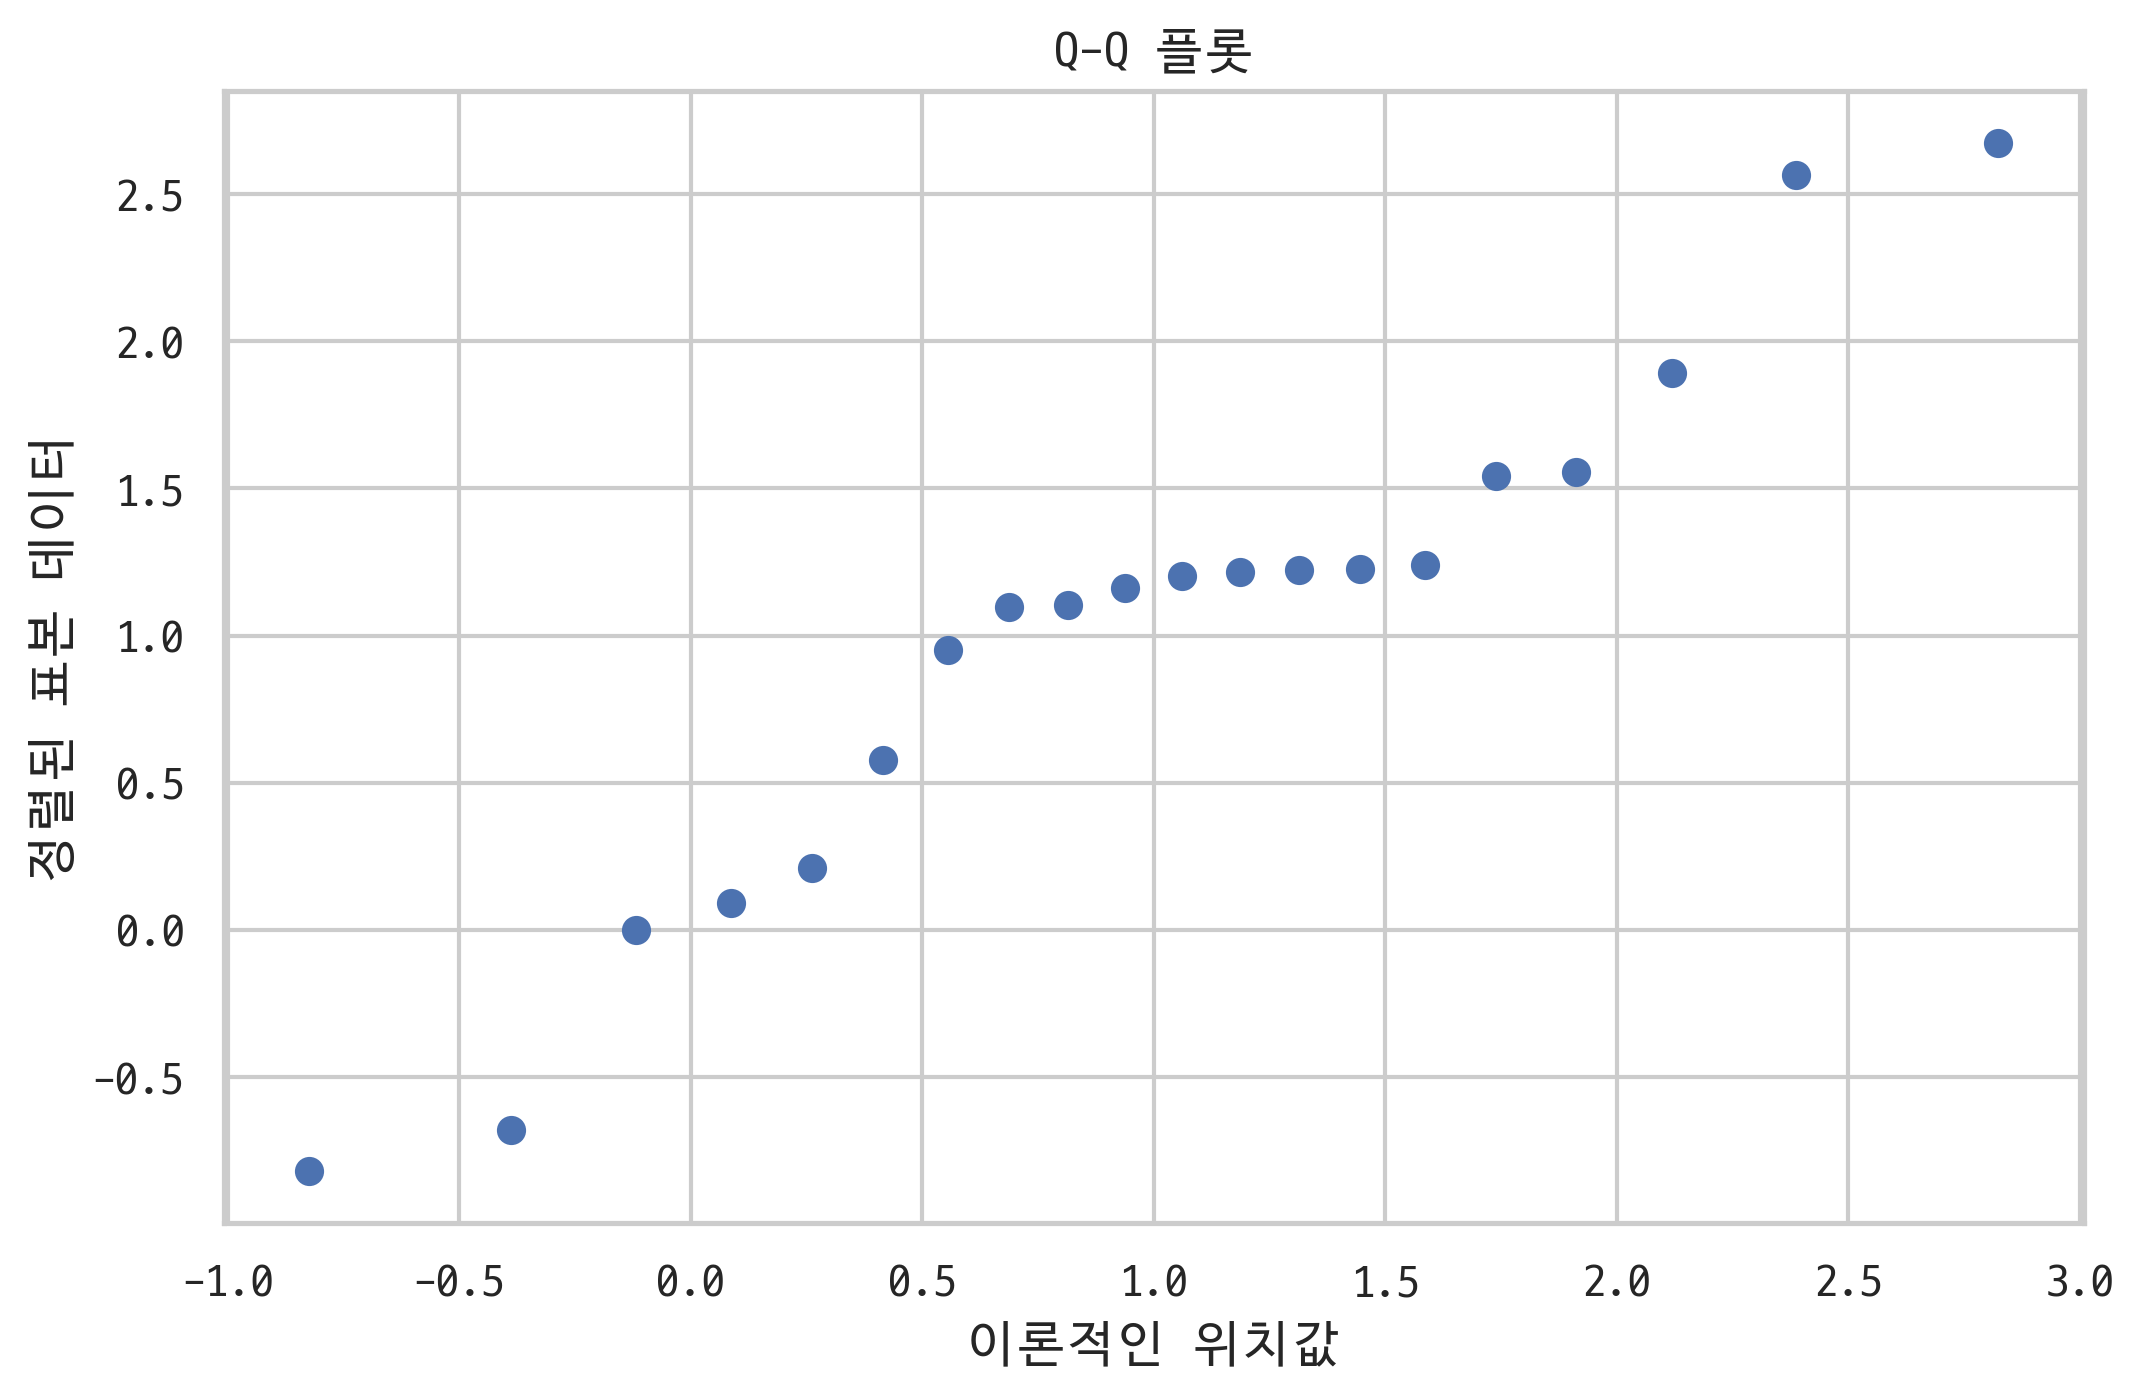

In [112]:
plt.scatter(qf, x_sorted)
plt.title('Q-Q 플롯')
plt.xlabel('이론적인 위치값')
plt.ylabel('정렬된 표본 데이터')
plt.show()

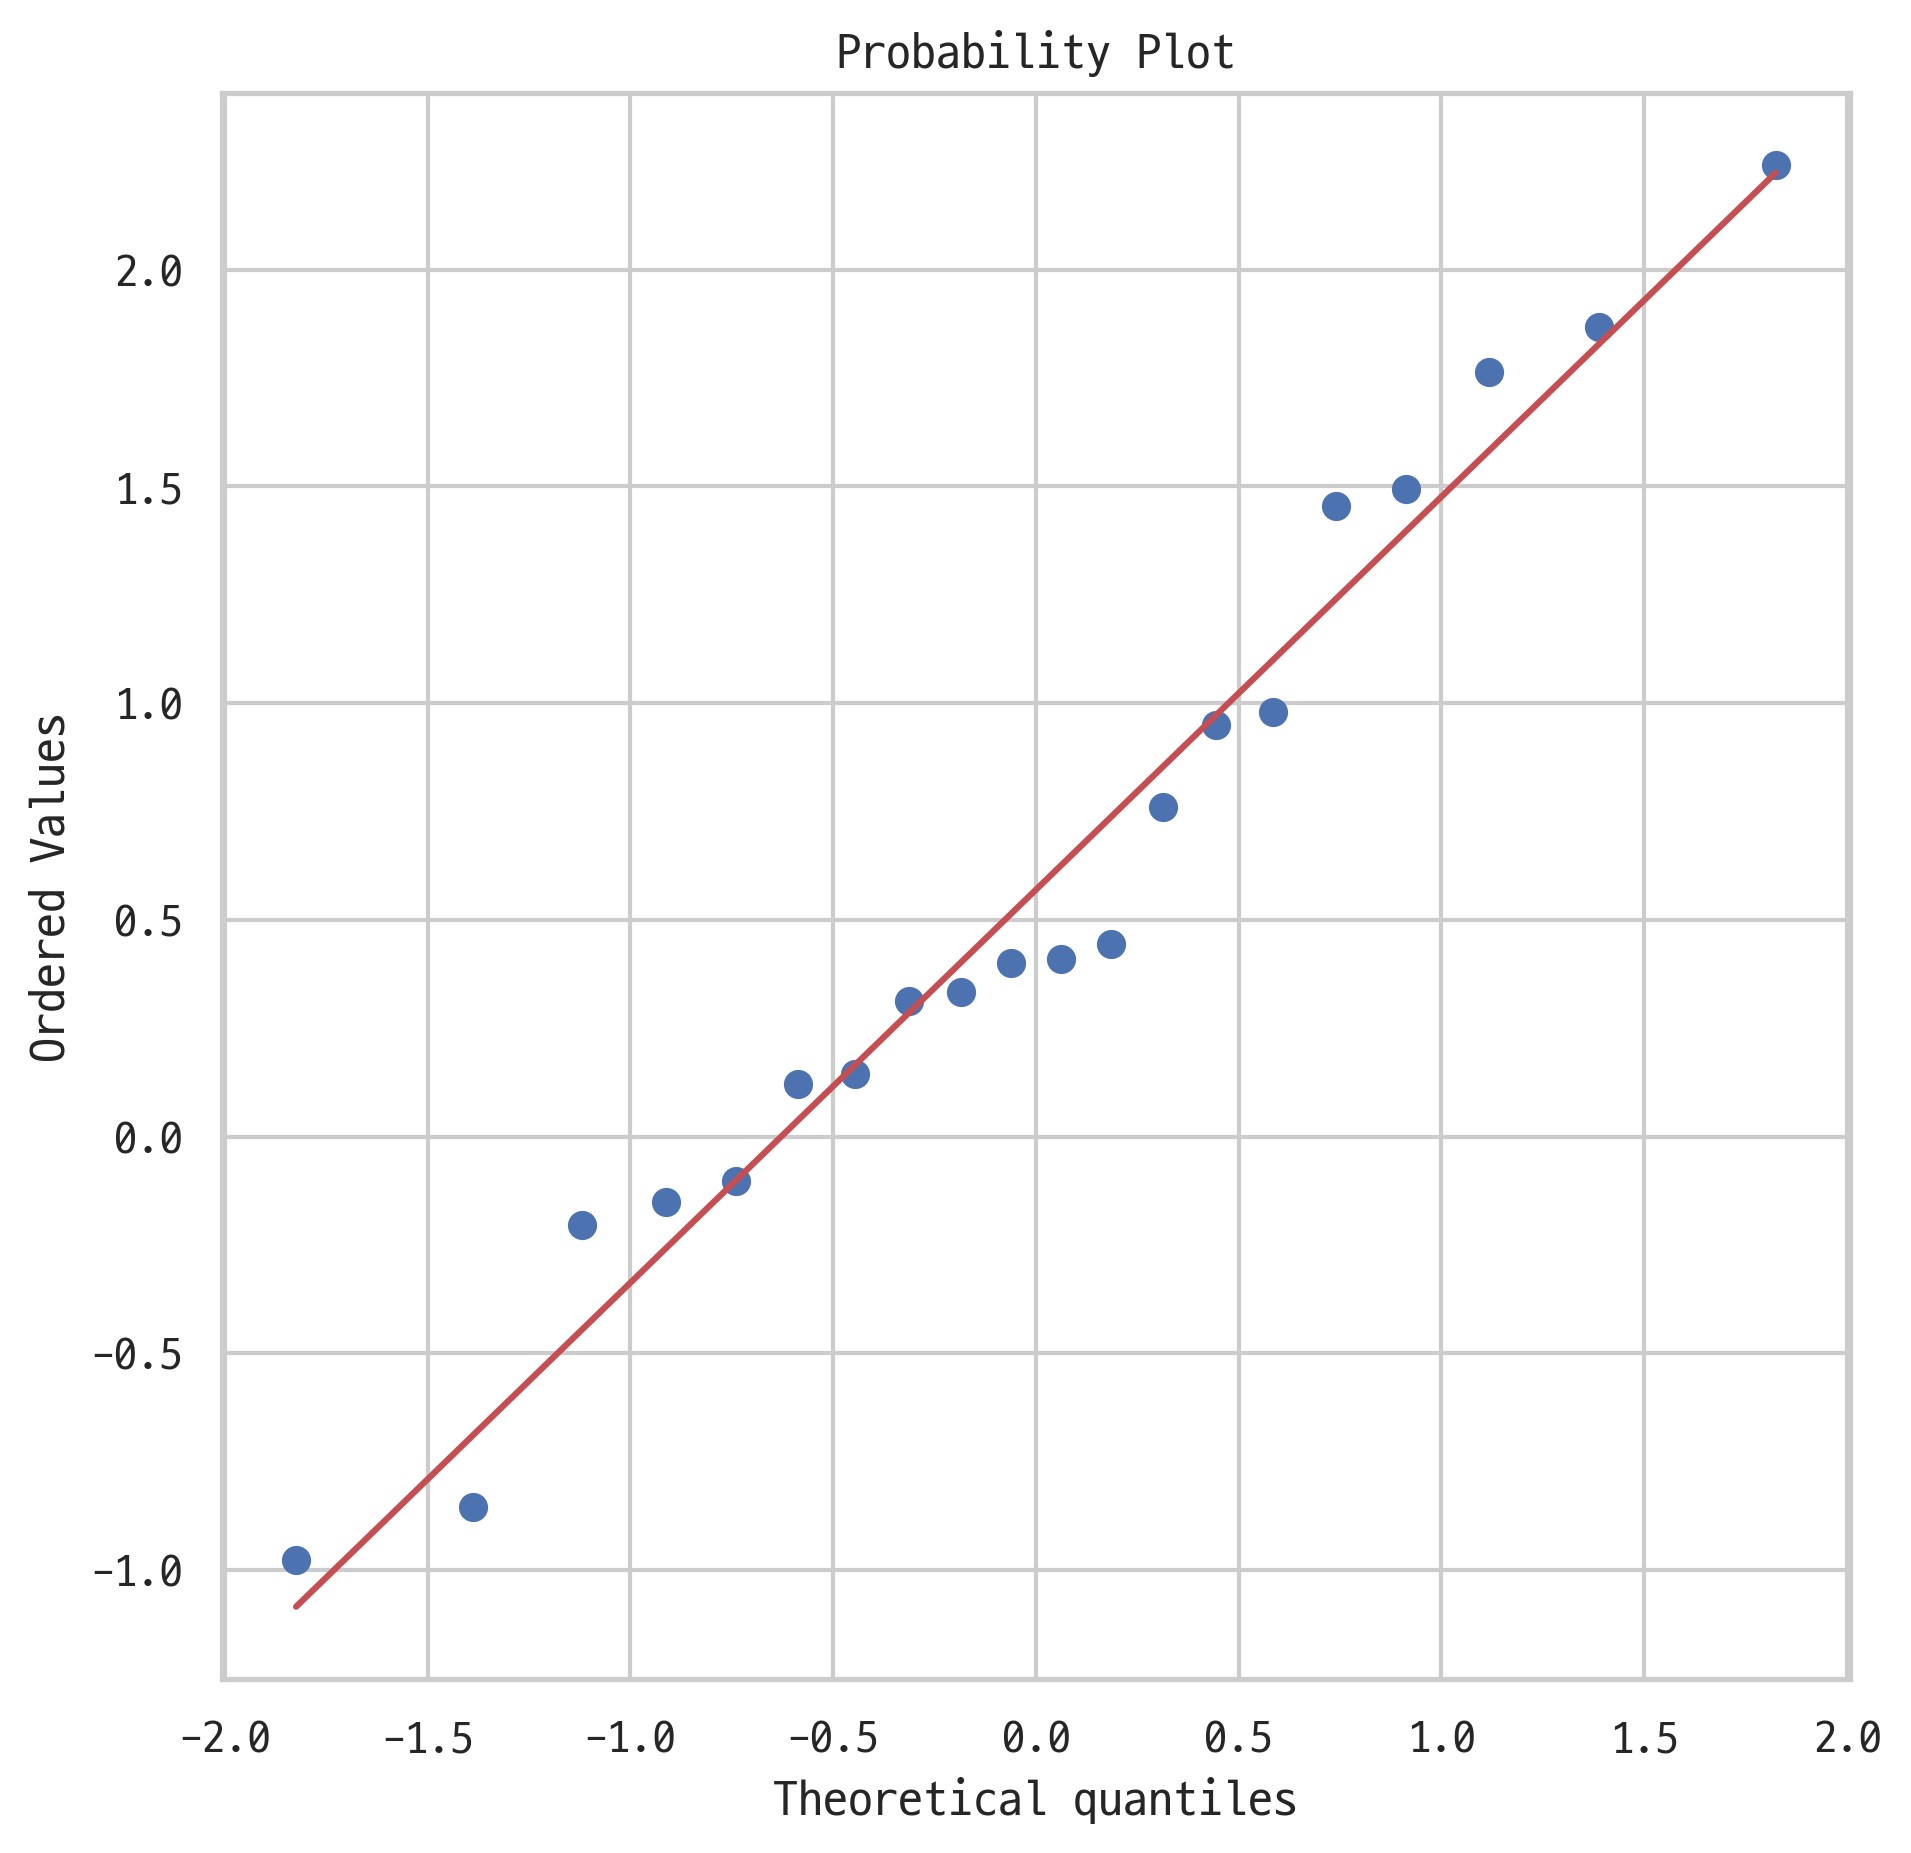

In [113]:
#Scipy의 probplot() 사용하기
np.random.seed()
plt.figure(figsize=(7, 7))
sp.stats.probplot(x, plot=plt) # 차트를 그리고 싶다면, 왼쪽과 같이 plot 인수에 matplotlib.pylab 모듈 객체 혹은 Axes 클래스 객체를 넘겨주어야 한다.
plt.show()

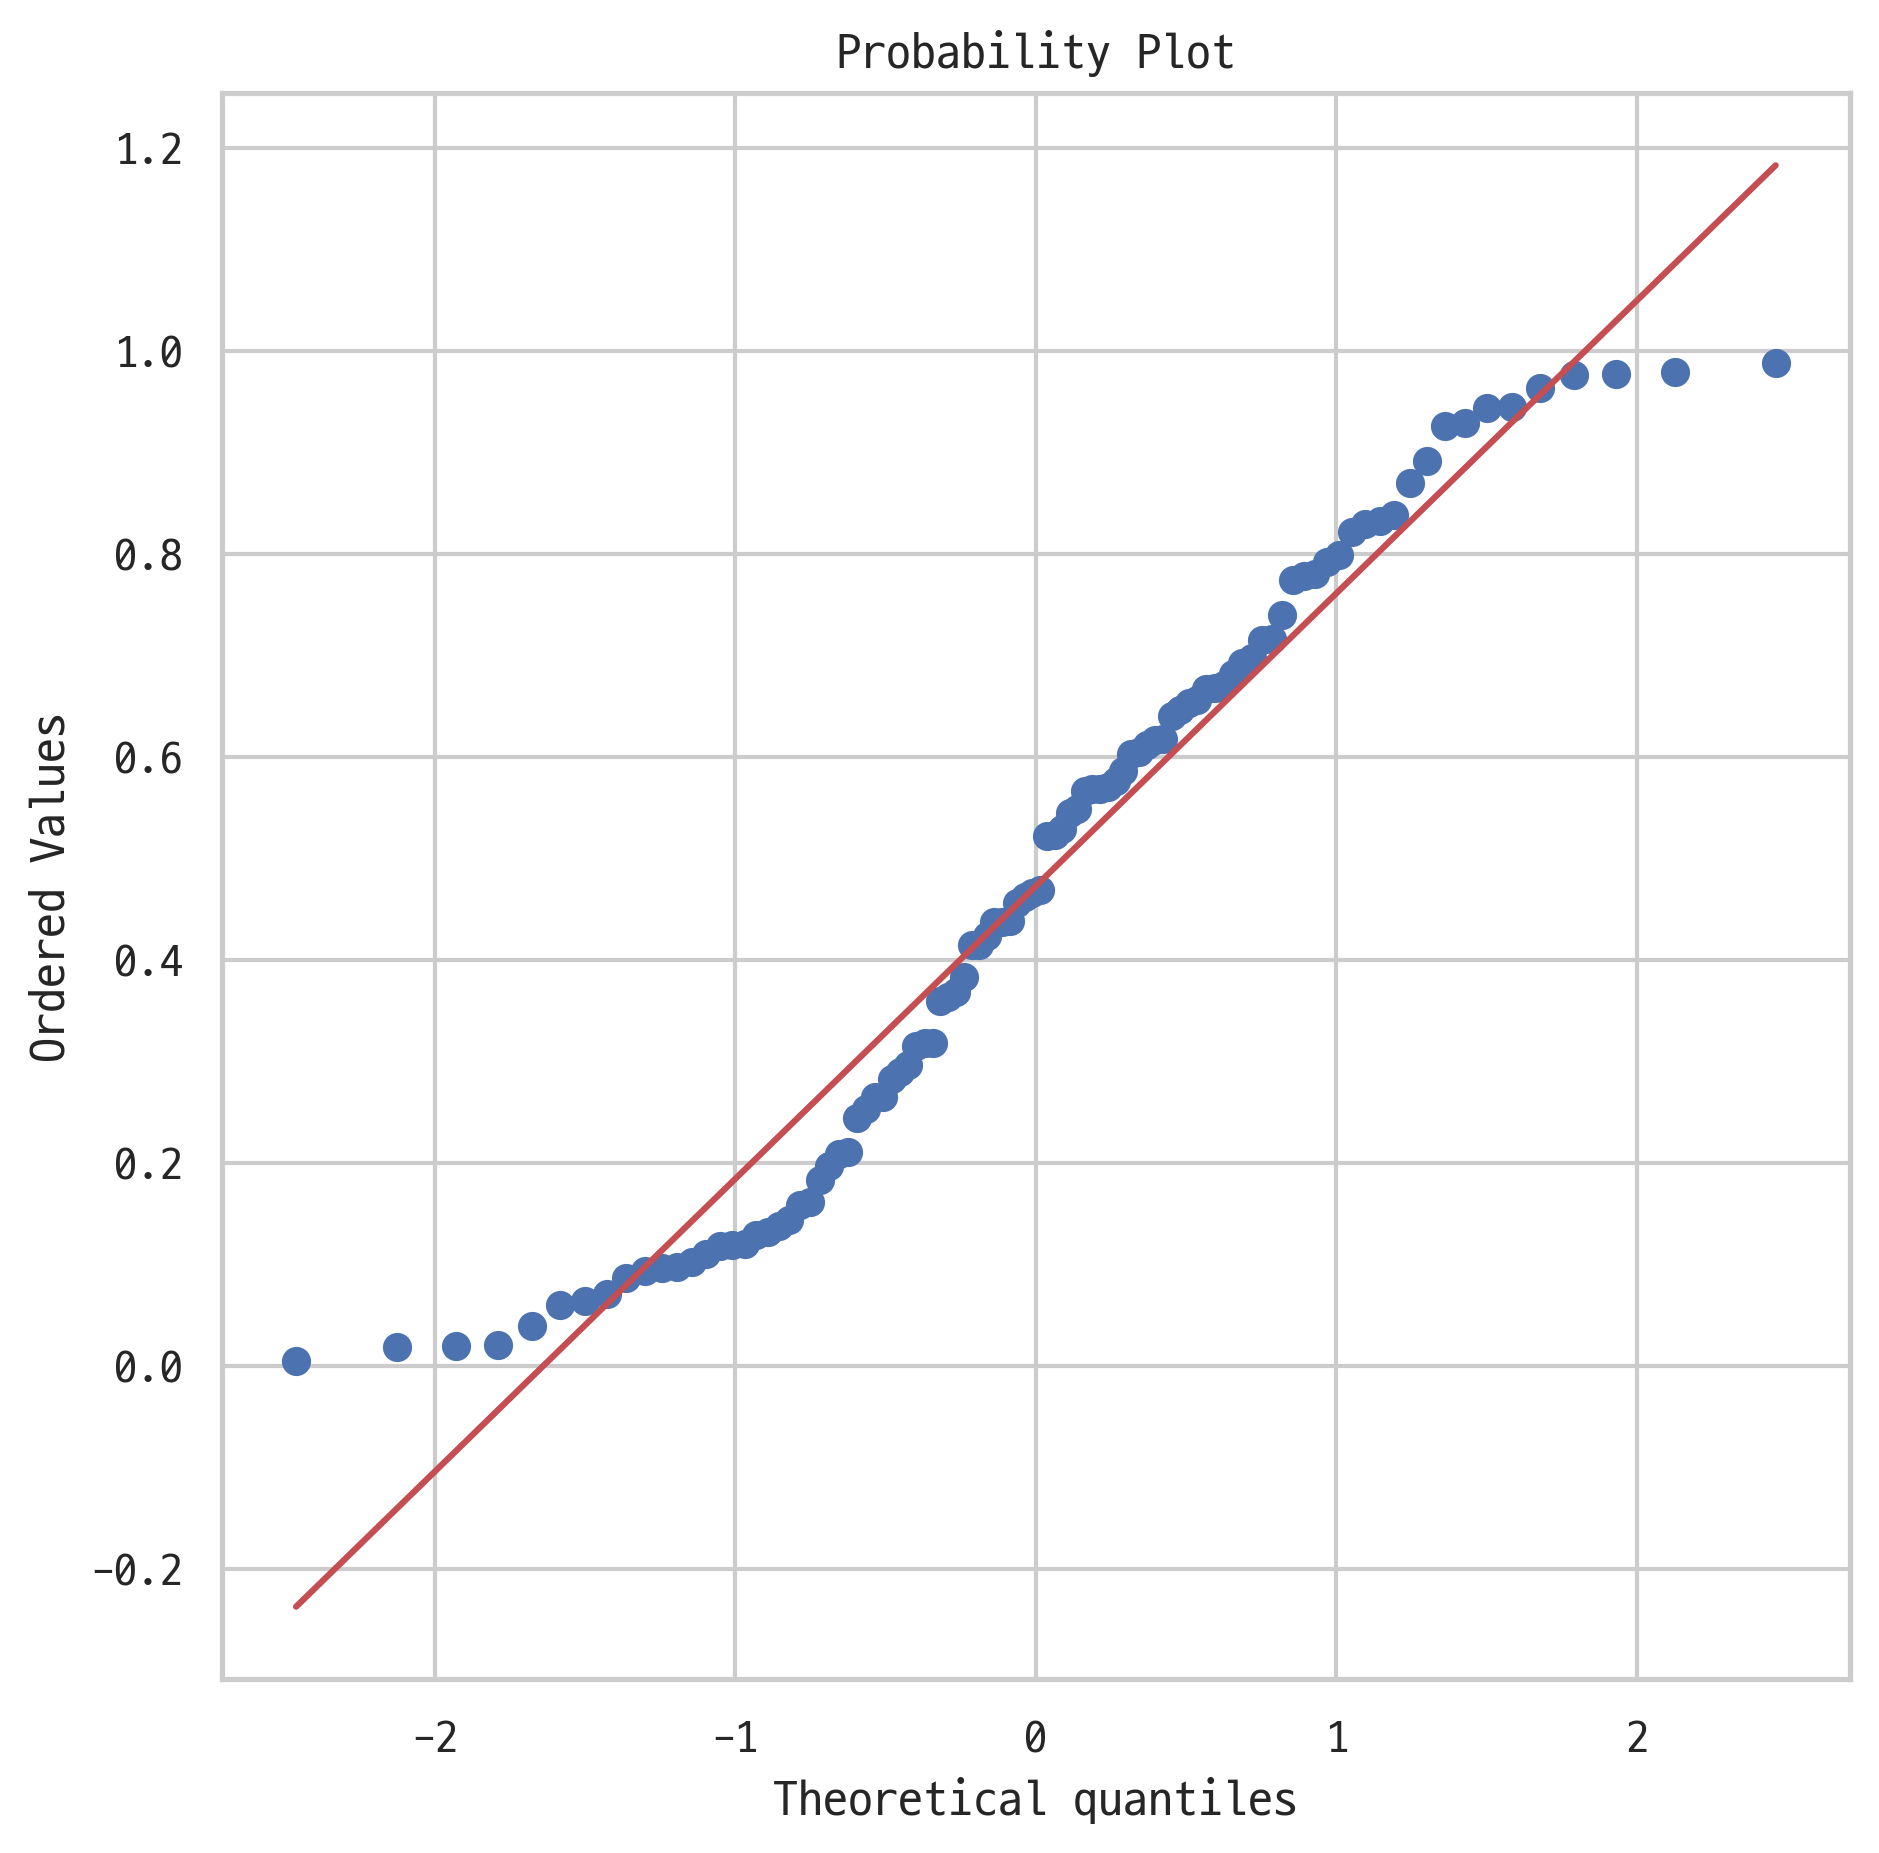

In [114]:
# 정규분포를 따르지 않는 데이터 표본을 Q-Q 플롯으로 그리면, 다음과 같이 직선이 아닌 휘어진 형태로 나타난다.
np.random.seed(0)
x = np.random.rand(100)
plt.figure(figsize=(7, 7))
sp.stats.probplot(x, plot=plt)
plt.show()

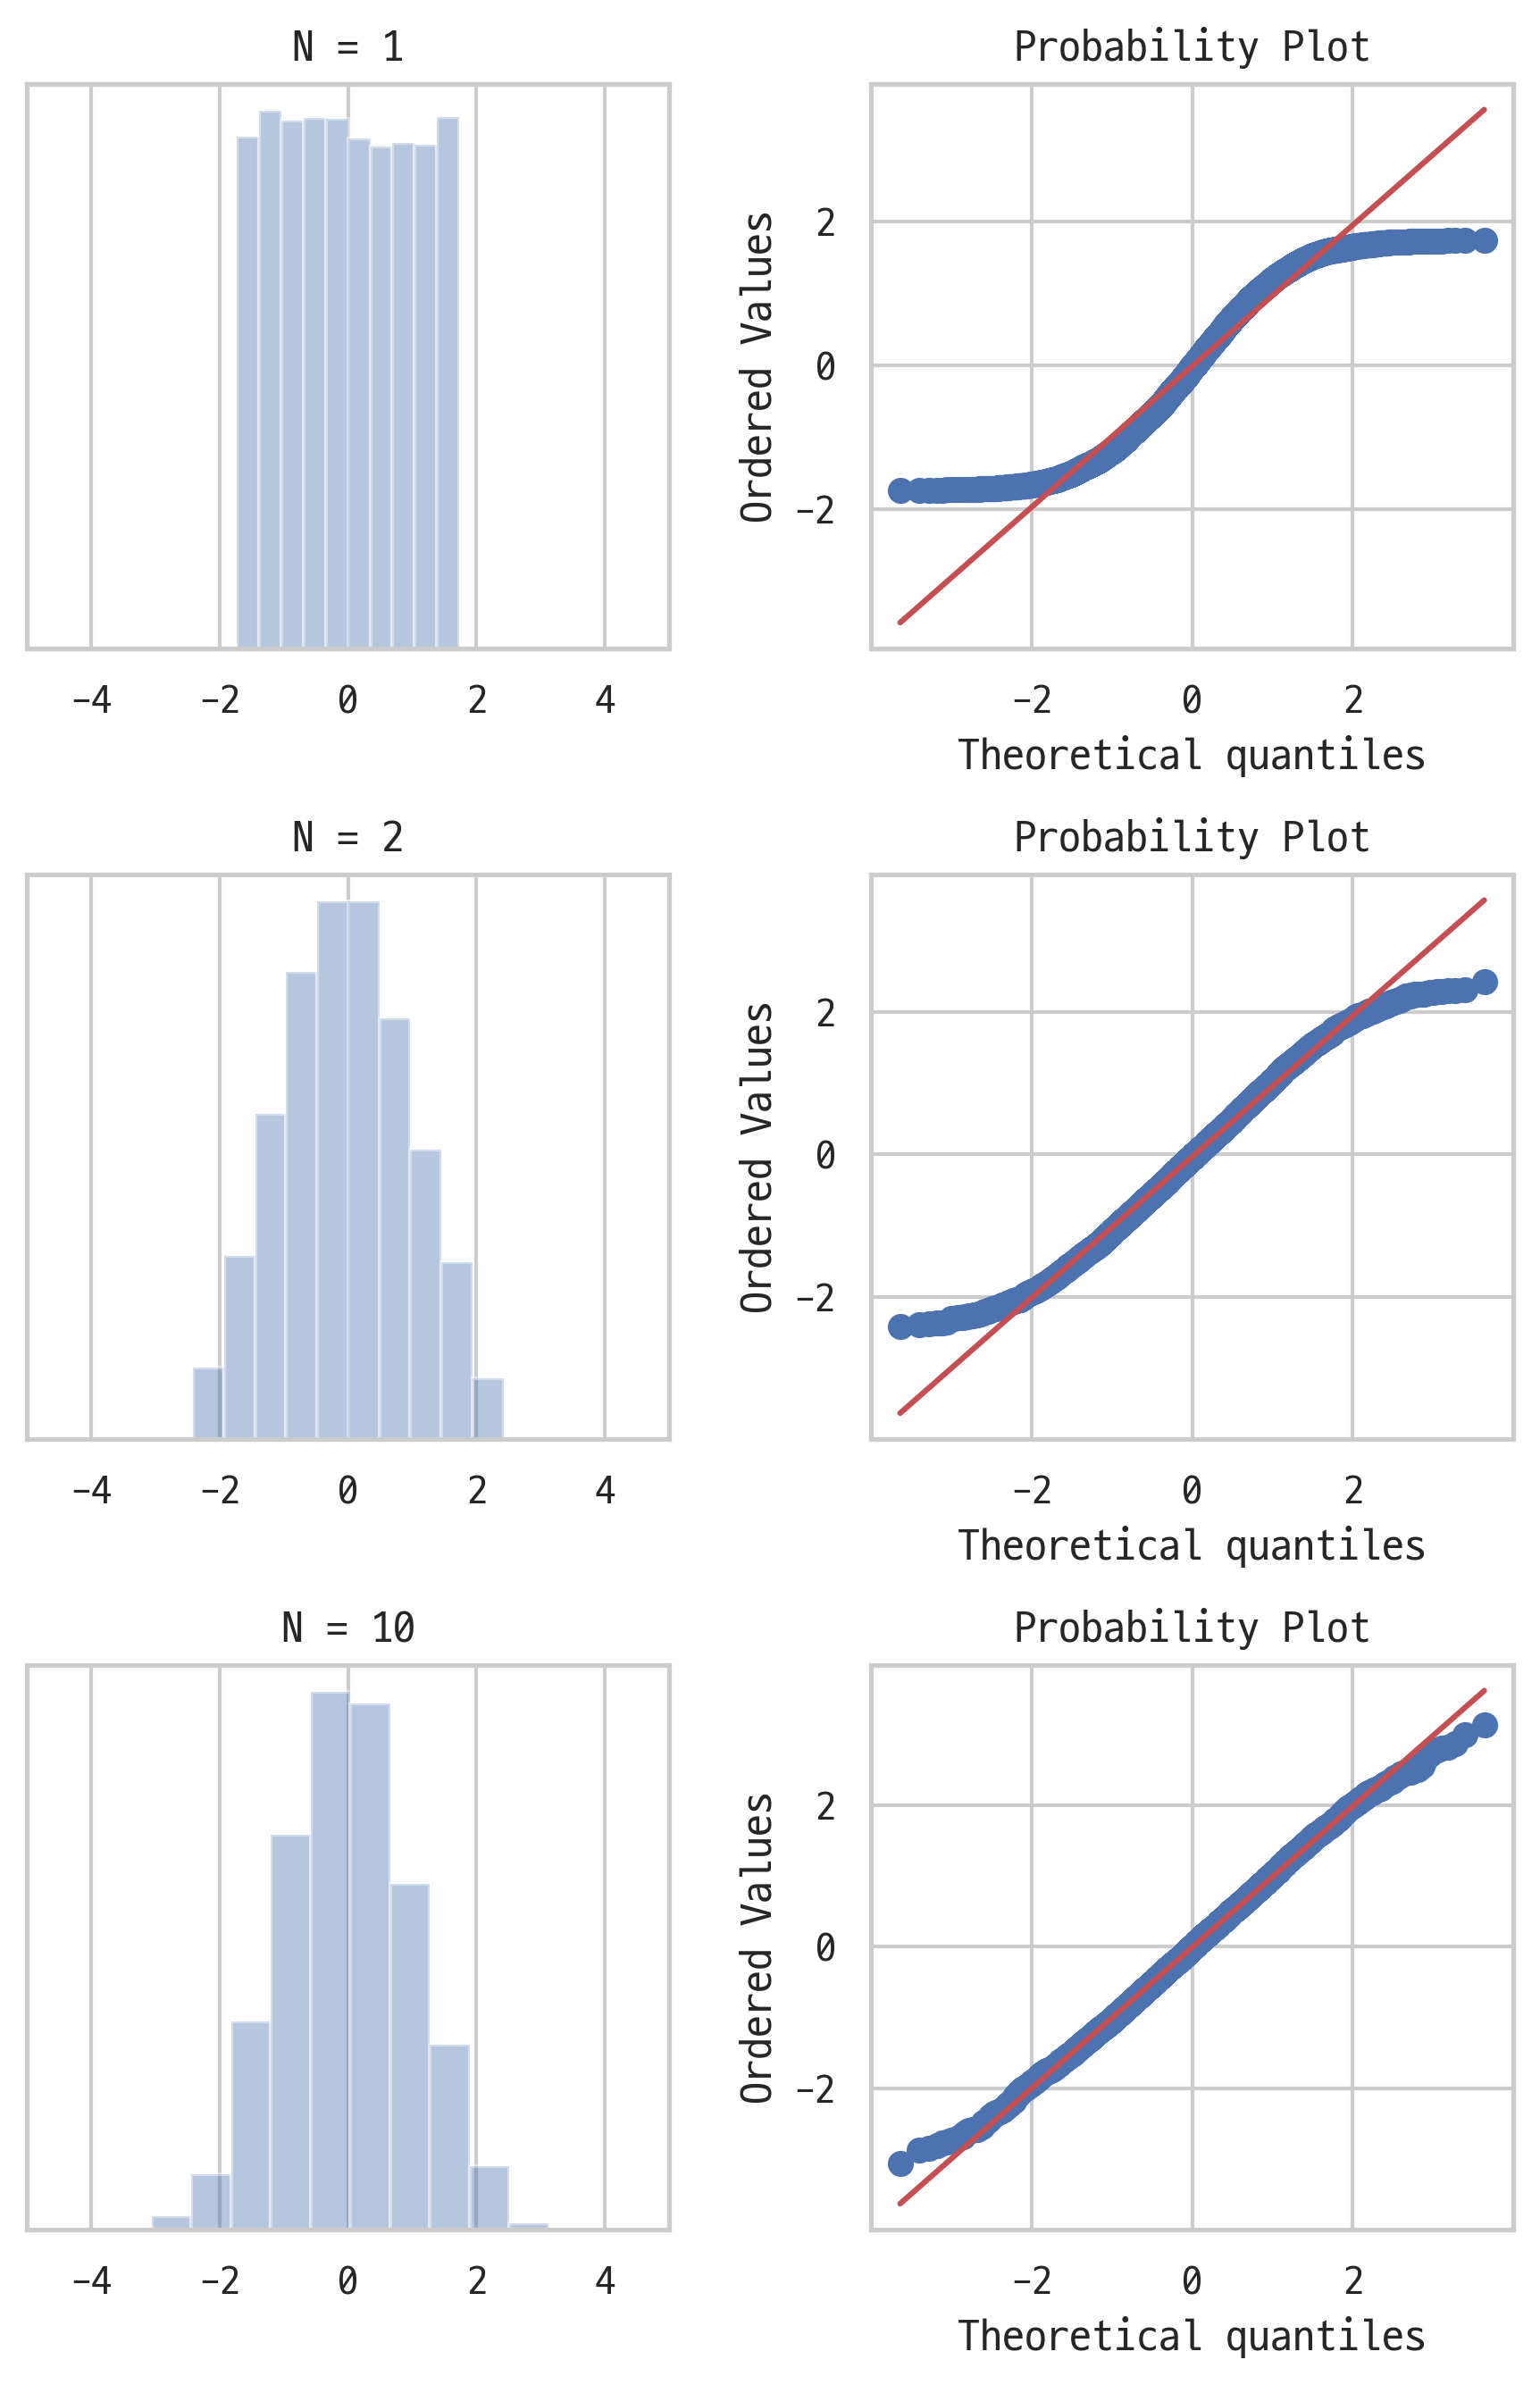

In [12]:
# Analysis
np.random.seed(0)
xx = np.linspace(-2, 2, 100)

plt.figure(figsize=(6, 9))

for i, N in enumerate([1, 2, 10]):
    X = np.random.rand(5000, N)
    Xbar = (X.mean(axis=1) - 0.5) * np.sqrt(12 * N)
    ax = plt.subplot(3, 2, 2 * i + 1)
    sns.distplot(Xbar, bins=10, kde=False, norm_hist=True)
    plt.xlim(-5, 5)
    plt.yticks([])
    ax.set_title("N = {0}".format(N))
    plt.subplot(3, 2, 2 * i + 2)
    sp.stats.probplot(Xbar, plot=plt)

plt.tight_layout()
plt.show()

# 7. 베타분포, 감마분포, 디리클레 분포

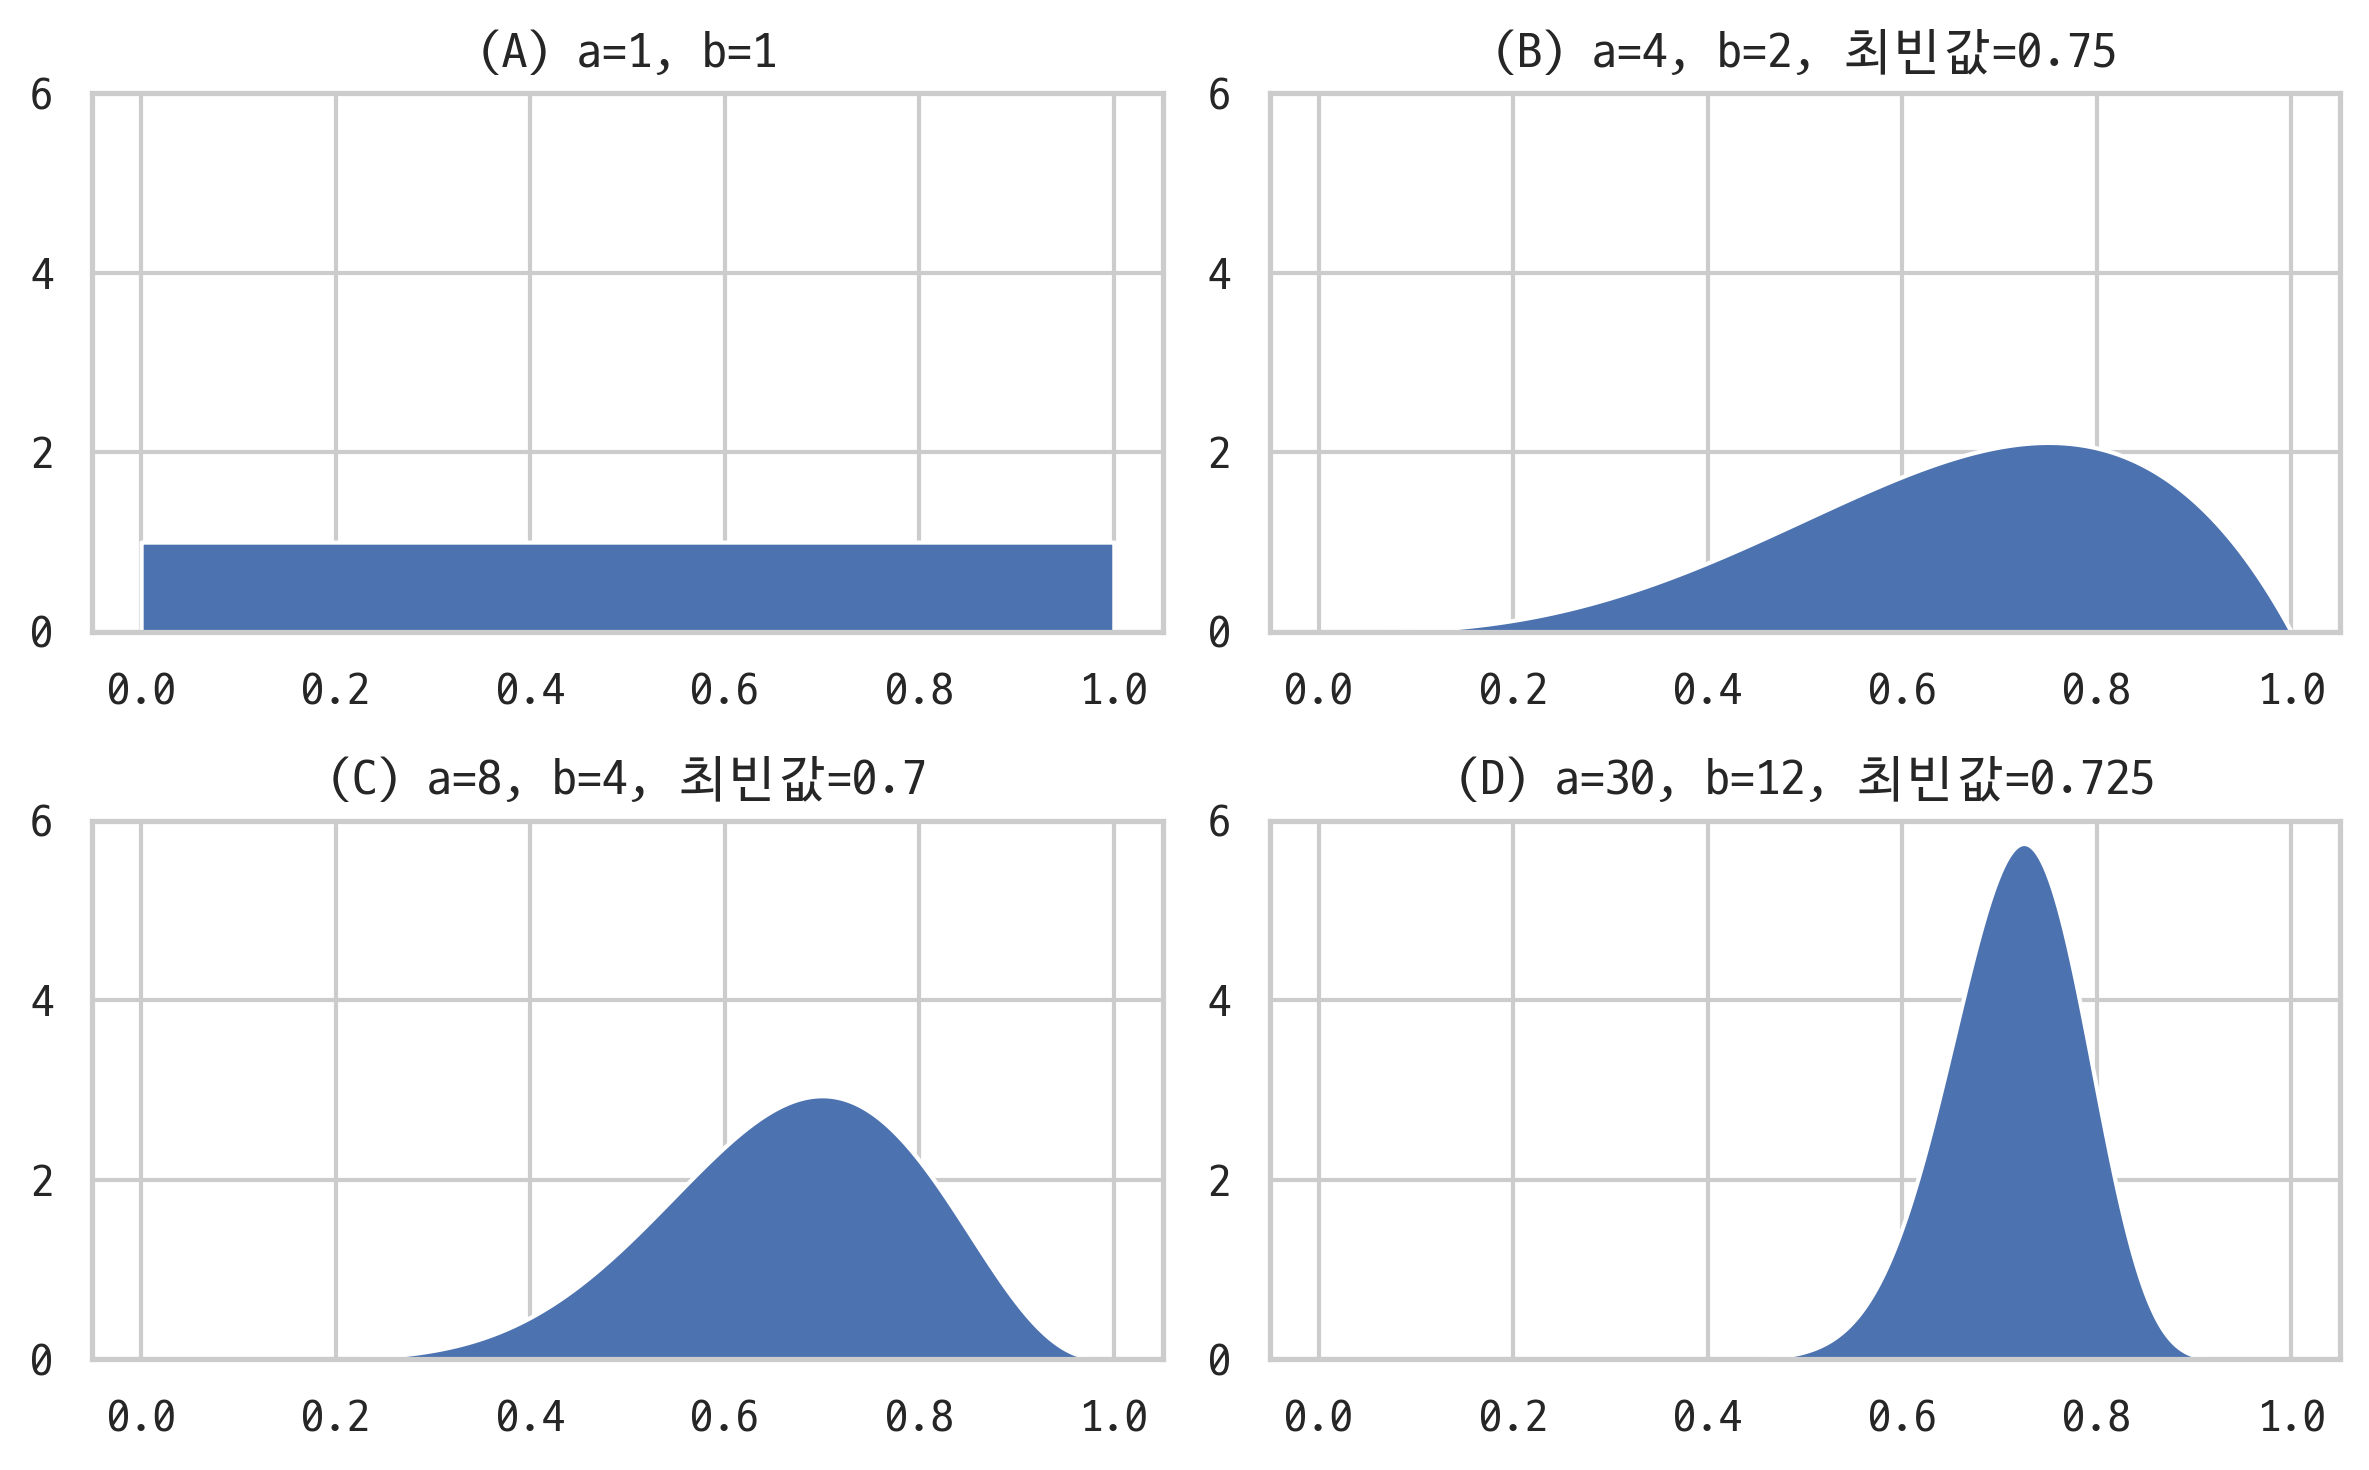

In [2]:
xx = np.linspace(0, 1, 1000)
plt.subplot(221)
# plt.fill_between(xx, sp.stats.beta(1.0001, 1.0001).pdf(xx))
plt.fill_between(xx, sp.stats.beta(1, 1).pdf(xx))
plt.ylim(0, 6)
plt.title("(A) a=1, b=1")
plt.subplot(222)
plt.fill_between(xx, sp.stats.beta(4, 2).pdf(xx))
plt.ylim(0, 6)
plt.title("(B) a=4, b=2, 최빈값={0}".format((4-1)/(4+2-2)))
plt.subplot(223)
plt.fill_between(xx, sp.stats.beta(8, 4).pdf(xx))
plt.ylim(0, 6)
plt.title("(C) a=8, b=4, 최빈값={0}".format((8-1)/(8+4-2)))
plt.subplot(224)
plt.fill_between(xx, sp.stats.beta(30, 12).pdf(xx))
plt.ylim(0, 6)
plt.title("(D) a=30, b=12, 최빈값={0}".format((30-1)/(30+12-2)))
plt.tight_layout()
plt.show()

### 감마분포
사이파이의 stats 서브패키지에서 제공하는 gamma 클래스는 모수  𝑏=1 로 고정되어  𝑎  값만 설정할 수 있다.  𝑏 를 바꾸려면  𝑥 값 스케일과 계수를 수동으로 설정하여야 한다.

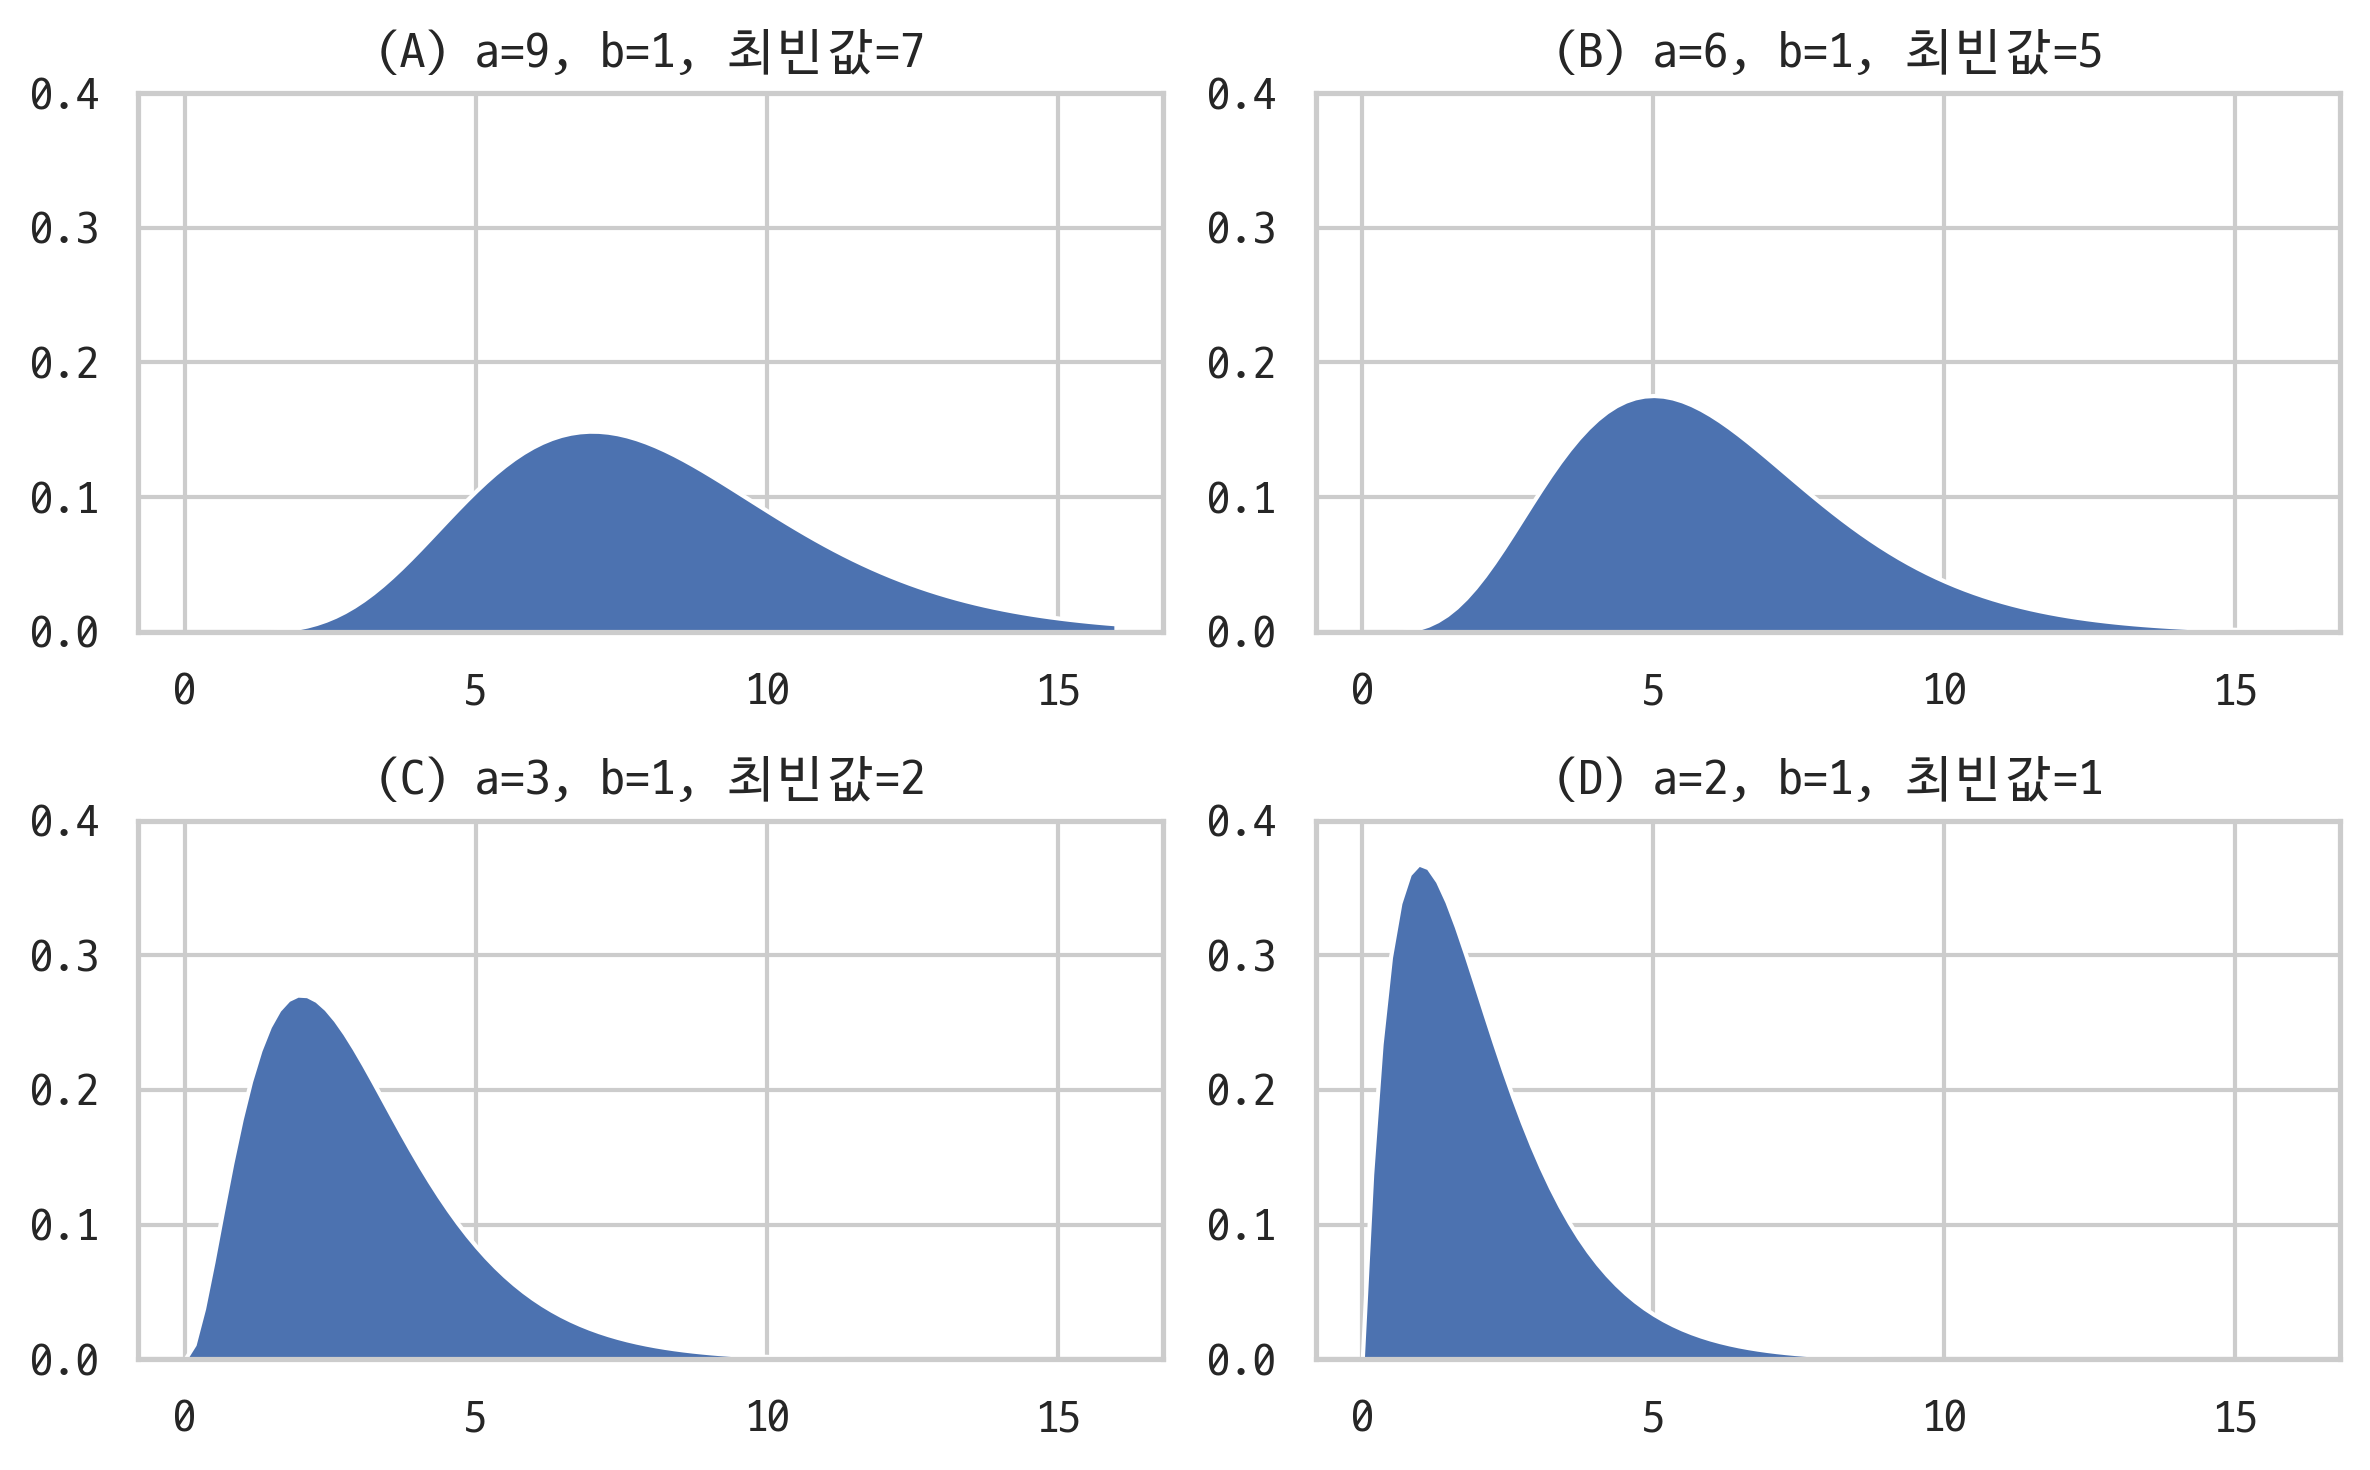

In [3]:
xx = np.linspace(0, 16, 100)
plt.subplot(221)
plt.fill_between(xx, sp.stats.gamma(8).pdf(xx))
plt.ylim(0, 0.4)
plt.title("(A) a=9, b=1, 최빈값=7")
plt.subplot(222)
plt.fill_between(xx, sp.stats.gamma(6).pdf(xx))
plt.ylim(0, 0.4)
plt.title("(B) a=6, b=1, 최빈값=5")
plt.subplot(223)
plt.fill_between(xx, sp.stats.gamma(3).pdf(xx))
plt.ylim(0, 0.4)
plt.title("(C) a=3, b=1, 최빈값=2")
plt.subplot(224)
plt.fill_between(xx, sp.stats.gamma(2).pdf(xx))
plt.ylim(0, 0.4)
plt.title("(D) a=2, b=1, 최빈값=1")
plt.tight_layout()
plt.show()

In [6]:
df = pd.DataFrame({'produce':[7, 8, 10, 11, 12, 14], 'days':[10, 10, 20, 30, 20, 10]})
df

,produce,days
0,7,10
1,8,10
2,10,20
3,11,30
4,12,20
5,14,10


In [17]:
df['ratio'] = df.days / df.days.sum()

In [18]:
df

,produce,days,ratio
0,7,10,0.1
1,8,10,0.1
2,10,20,0.2
3,11,30,0.3
4,12,20,0.2
5,14,10,0.1


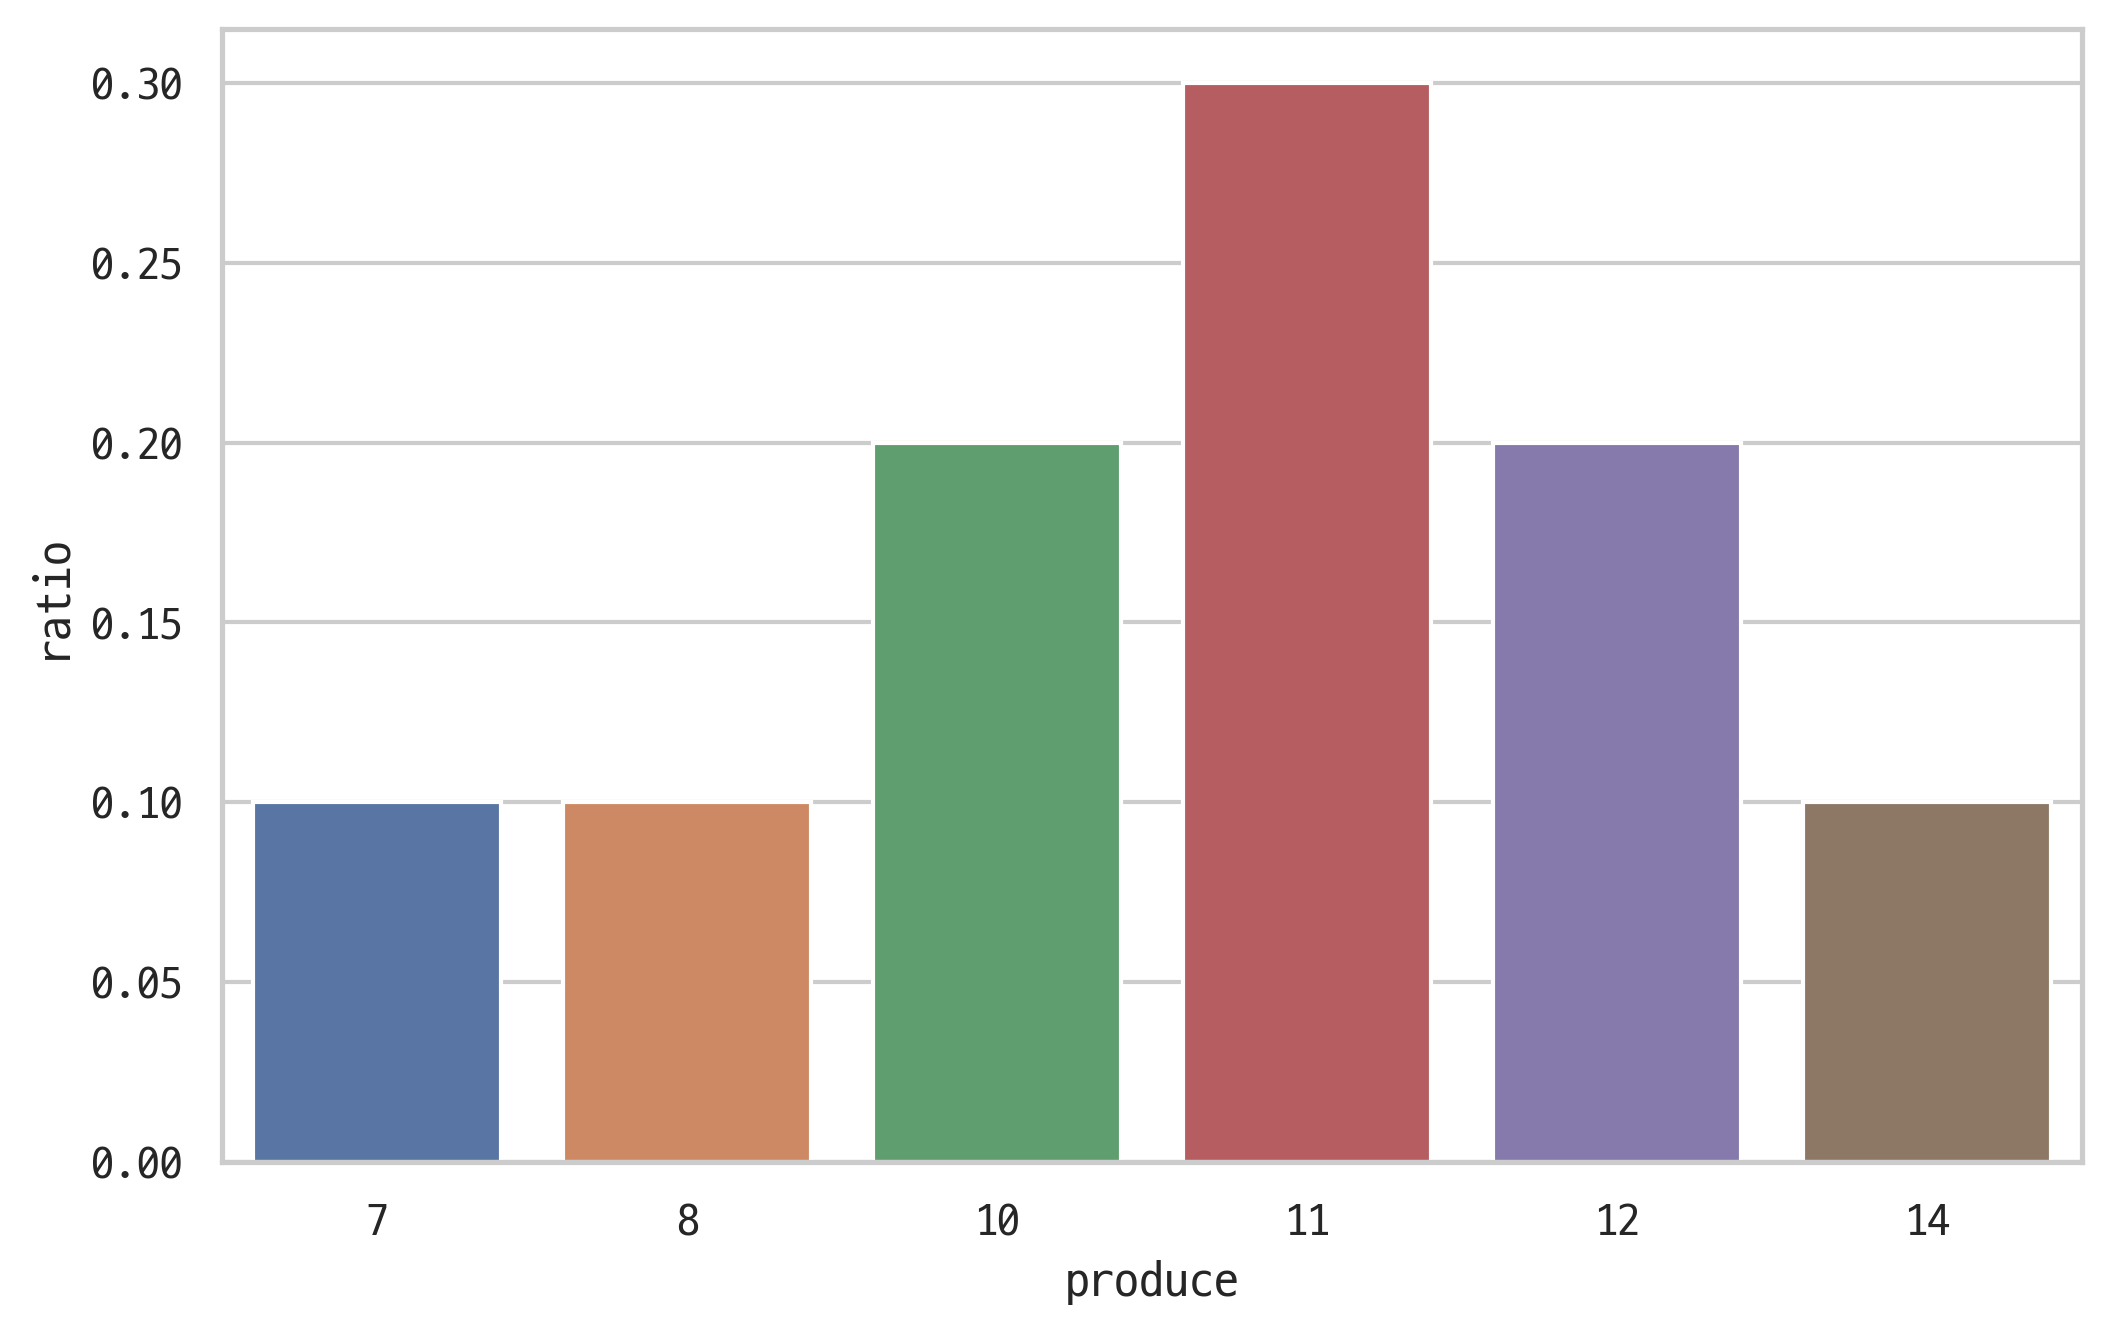

In [19]:
sns.barplot('produce', 'ratio', data=df)

In [26]:
np.sum(df.ratio*df.produce)

10.6

In [21]:
np.var( )z

0.005555555555555556

4 3


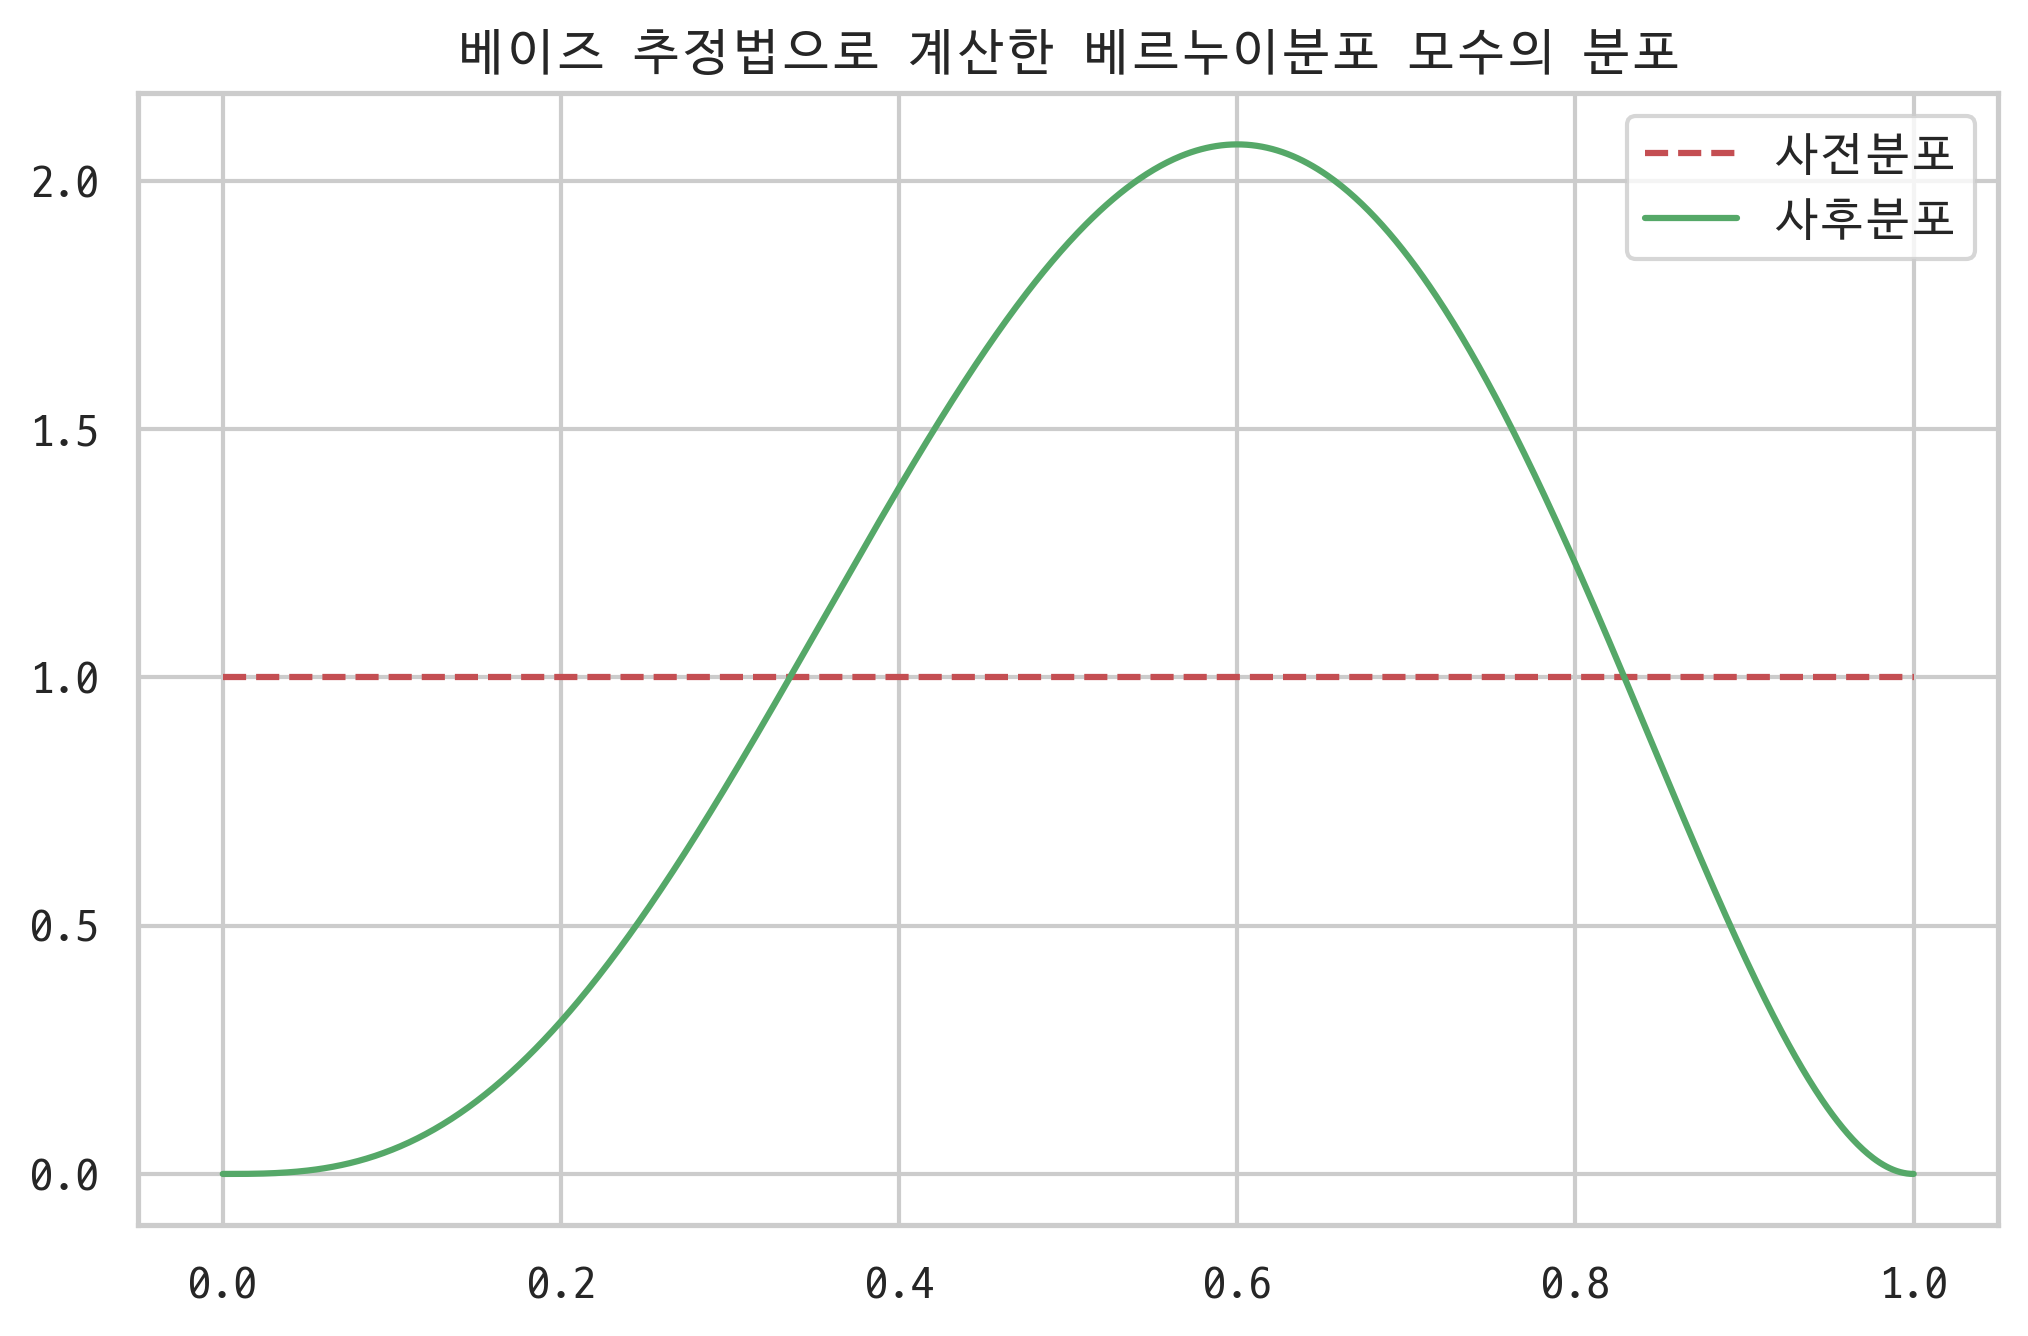

AttributeError: 'rv_frozen' object has no attribute 'mod'

In [31]:
op = 5
like = 3
dislike = op - like

xx = np.linspace(0, 1, 1000)
a0, b0 = 1, 1
plt.plot(xx, sp.stats.beta(a0, b0).pdf(xx), c="r", ls="--", label="사전분포")
a1, b1 = like + 1, dislike + 1
print(a1, b1)
plt.plot(xx, sp.stats.beta(a1, b1).pdf(xx), c="g", ls="-", label="사후분포")
plt.legend()
plt.title("베이즈 추정법으로 계산한 베르누이분포 모수의 분포")
plt.show()

print(sp.stats.beta(a1, b1).mod())